# `econ_anlys_shk_rll7_cml_cnd_mkt.ipynb` — COVID-19 Impact on Stock Market Indices: Initial Shock Period

> **File:** `econ_anlys_shk_rll7_cml_cnd_mkt.ipynb`
> **Purpose:** Analyze the causal and predictive relationship between the 7-day rolling average of cumulative COVID-19 cases and deaths (`covid_c&d`) and five stock market indices during the Initial Shock period (01/22/2020 – 06/07/2020).
> **Programmer:** Nicholas J. George  |  **Initial Development:** 04/10/2026

---

## Overview

This notebook examines whether the 7-day rolling average of cumulative COVID-19 cases and deaths (`covid_c&d`) Granger-caused movements in five stock market indices during the acute pandemic onset phase. The analysis covers the period from the first recorded U.S. case through early June 2020 — a window that includes the historic February–March equity market crash and the early V-shaped recovery. The X series is applied with both cumulative (`xcml = True`) and 7-day rolling average (`x_roll = True, x_roll_days = 7`) transformations on levels (no percentage change).

Each Y series is analyzed individually against the transformed X series using a common pipeline: polynomial degree optimization, contemporaneous correlation, Granger causality testing in both directions (X→Y and Y→X), VAR/VECM dynamics (IRF and FEVD), rolling correlation, and lag correlation. Summary tables in Section 1.1.8 consolidate findings across all five indices.

---

## Analytical Framework

| Component | Method | Purpose |
|---|---|---|
| Stationarity Testing | Zivot-Andrews, Bai-Perron, ADF, KPSS, Cross-Validation | Identify structural breaks and unit roots; select appropriate transformations |
| Correlation | Optimal polynomial degree + Pearson/Spearman | Measure contemporaneous association strength and functional form |
| Granger Causality | F-test / chi² (both directions) | Determine whether COVID data provides predictive information about market levels beyond the market's own history, and vice versa |
| VAR/VECM | Impulse Response Functions (IRF), FEVD | Quantify the dynamic response of markets to a COVID shock and the share of market variance explained by COVID |
| Rolling Correlation | Optimal window and minimum period | Track how the correlation evolves across the short Initial Shock window |
| Lag Correlation | Bonferroni-corrected peak lag | Identify the delay (in days) between COVID data changes and market responses |

---

## Data Configuration

| Parameter | Value |
|---|---|
| X Variable | `covid_c&d` — Cumulative COVID-19 Cases & Deaths (combined) |
| X Transformation | 7-day rolling average (`x_roll = True, x_roll_days = 7`); cumulative (`xcml = True`) |
| Y Variable Category | `stk_mkt` — Stock Market Indices (Y1–Y5) |
| Period | Initial Shock: 01/22/2020 – 06/07/2020 |
| Percentage Change | No (levels analysis; `xpct = False, ypct = False`) |

---

## Summary and Conclusions

### Analytical Context

The Initial Shock period is the most acute and informationally concentrated phase of the COVID-19 pandemic for financial markets. The period spans the transition from early case counts (near zero, mid-January 2020) through exponential U.S. case growth, the peak-to-trough crash in global equities (approximately February 19 to March 23, 2020, representing one of the fastest bear markets on record), the Federal Reserve's emergency rate cuts and QE announcements, and the subsequent partial recovery into early June 2020. This compression of extreme events into a 137-day window creates the conditions most likely to yield statistically detectable causal relationships between COVID data and market levels.

### Stationarity and Transformations (Section 1.1.2)

All series — both `covid_c&d` (rolling cumulative) and the five stock market index levels — are expected to be non-stationary in levels during this period. The cumulative COVID series follows a monotonically increasing trajectory with at least one major structural break (corresponding to the onset of exponential community spread in mid-March 2020), which will be detected by the Zivot-Andrews and Bai-Perron tests. The equity index series exhibit a sharp downward structural break in late February / early March followed by a recovery trend, generating a non-standard non-stationary pattern that is neither a clean random walk nor a simple trend-stationary process. The stationarity pipeline (`mathx.crct_stnry_df()`) applies the minimum differencing required to achieve stationarity for each series individually before downstream causal testing.

### Relationship Characteristics Across All Five Indices

The 7-day rolling average of cumulative COVID cases and deaths is expected to exhibit a strong **negative** contemporaneous correlation with all five stock market indices during this period — rising case counts align chronologically with falling equity prices in February–March 2020, and falling/stabilizing counts align with the subsequent recovery. However, because both series are trending (one up, one down then up), a large share of this raw correlation reflects shared trend rather than genuine short-run predictability.

Granger causality from X→Y (COVID predicting markets) is likely to be stronger than Y→X (markets predicting COVID), consistent with the direction of information flow during a public health crisis: case counts inform investor expectations rather than the reverse. The lag correlation analysis will identify whether markets responded to COVID data with a lead or a lag, and by how many days — a positive lag (X leads Y) would confirm that case growth anticipated equity declines rather than merely co-moving with them.

The VAR/VECM framework will quantify the impulse response — how much of a shock to the COVID series propagates into market levels, and over how many periods — and the FEVD will decompose what fraction of market return variance is attributable to COVID shocks versus the market's own internal dynamics. During the Initial Shock phase, COVID's FEVD share in equity variance is expected to be meaningfully elevated relative to normal periods, reflecting the pandemic's dominance as a market driver.

### Expected Cross-Index Variation

The five stock market indices likely represent different market segments (e.g., broad equity, tech-weighted, small-cap, international, or sector-specific). If so, the strength of the COVID relationship is expected to vary across them. Broad market indices tend to reflect aggregated risk-off behavior most cleanly; sector-specific or internationally weighted indices may show more idiosyncratic responses depending on their exposure to pandemic-driven demand destruction or supply chain disruption. Section 1.1.8 summary tables provide the cross-index comparison needed to identify which index had the strongest and most consistent COVID causal signal during this period.

---


In [1]:
 #*******************************************************************************************
 #
 #  File Name:  econ_anlys_gnc.ipynb
 #
 #  File Description:
 #      This interactive Python notebook, econ_anlys_gnc.ipynb, analyzes the relationship 
 #      between an x-series and five y-series.
 #      
 #
 #  Date            Description                             Programmer
 #  ----------      ------------------------------------    ------------------
 #  04/10/2026      Initial Development                     Nicholas J. George
 #
 #******************************************************************************************/

import dtypesx
import econ_anlys_vrb
import logx
import mathx
import matplotlibx
import pandasx
import warnings

import numpy  as np
import pandas as pd

warnings.filterwarnings('ignore')

In [2]:
econ_anlys_vrb.setup \
    (xcml        = True, 
     x           = 'covid_c&d', 
     y           = 'stk_mkt', 
     tm_prd      = 'initial_shock', 
     x_roll      = True,
     x_roll_days = 7,
     xpct        = False,
     ypct        = False,
     bse         = 'econ_anlys')

XCOL, XSBJ, XCAT, XLBL, XTTL, RLL, DY, XPCT = econ_anlys_vrb.get_xattr()

YCOL, YSBJ, YCAT, YLBL, YTTL, YPCT          = econ_anlys_vrb.get_yattr()

PRD, ST, ED                                 = econ_anlys_vrb.get_prd_attr()

DSG                                         = econ_anlys_vrb.get_dsg()

Y                                           = econ_anlys_vrb.get_y_enum()

In [3]:
CONSTANT_LOCAL_FILE_NAME = DSG + '.ipynb'

In [4]:
logx.set_log_mode(True)

logx.set_image_mode(True)


logx.begin_program(DSG)

Program execution has begun...



# <br> **Part 1: X-Variable Analysis**

## **Subsection 1.1: Full Period (01/22/2020 — 09/14/2022)**

## **1.1.1: Extract Data from Files**

### **X-Variable**

In [5]:
x_df = pd.read_json(econ_anlys_vrb.crn_dict['file']['x'], typ = 'frame')

logx.log_write_obj(x_df)

In [6]:
x_series = x_df[XCOL][ST:ED]

x_series = dtypesx.rtn_date_idxs(x_series)


if RLL:  x_series = x_series.rolling(window = DY).mean()

if XPCT: x_series = dtypesx.cnv_to_pct_chg(x_series)


logx.log_write_obj(x_series)

### **Y-Variables**

In [7]:
y_df = pd.read_json(econ_anlys_vrb.crn_dict['file']['y'], typ = 'frame')

logx.log_write_obj(y_df)

In [8]:
y1_series = y_df[YCAT[Y.Y1.value]][ST:ED]

y1_series = dtypesx.rtn_date_idxs(y1_series)


if YPCT: y1_series = dtypesx.cnv_to_pct_chg(y1_series)


logx.log_write_obj(y1_series)

In [9]:
y2_series = y_df[YCAT[Y.Y2.value]][ST:ED]

y2_series = dtypesx.rtn_date_idxs(y2_series)


if YPCT: y2_series = dtypesx.cnv_to_pct_chg(y2_series)
    

logx.log_write_obj(y2_series)

In [10]:
y3_series = y_df[YCAT[Y.Y3.value]][ST:ED]

y3_series = dtypesx.rtn_date_idxs(y3_series)


if YPCT: y3_series = dtypesx.cnv_to_pct_chg(y3_series)
    

logx.log_write_obj(y3_series)

In [11]:
y4_series = y_df[YCAT[Y.Y4.value]][ST:ED]

y4_series = dtypesx.rtn_date_idxs(y4_series)


if YPCT: y4_series = dtypesx.cnv_to_pct_chg(y4_series)
    

logx.log_write_obj(y4_series)

In [12]:
y5_series = y_df[YCAT[Y.Y5.value]][ST:ED]

y5_series = dtypesx.rtn_date_idxs(y5_series)


if YPCT: y5_series = dtypesx.cnv_to_pct_chg(y5_series)
    

logx.log_write_obj(y5_series)

In [13]:
if YPCT:

    ttl_dict \
        = {XCAT:             x_series,
           YCAT[Y.Y1.value] + '%': y1_series,
           YCAT[Y.Y2.value] + '%': y2_series,
           YCAT[Y.Y3.value] + '%': y3_series,
           YCAT[Y.Y4.value] + '%': y4_series,
           YCAT[Y.Y5.value] + '%': y5_series}

else:

    ttl_dict \
        = {XCAT:             x_series,
           YCAT[Y.Y1.value]: y1_series,
           YCAT[Y.Y2.value]: y2_series,
           YCAT[Y.Y3.value]: y3_series,
           YCAT[Y.Y4.value]: y4_series,
           YCAT[Y.Y5.value]: y5_series}

In [14]:
test_df = pd.DataFrame(ttl_dict).dropna()

if YPCT:

    x_series  = test_df[XCAT]

    y1_series = test_df[YCAT[Y.Y1.value] + '%']

    y2_series = test_df[YCAT[Y.Y2.value] + '%']

    y3_series = test_df[YCAT[Y.Y3.value] + '%']

    y4_series = test_df[YCAT[Y.Y4.value] + '%']

    y5_series = test_df[YCAT[Y.Y5.value] + '%']

else:

    x_series  = test_df[XCAT]

    y1_series = test_df[YCAT[Y.Y1.value]]

    y2_series = test_df[YCAT[Y.Y2.value]]

    y3_series = test_df[YCAT[Y.Y3.value]]

    y4_series = test_df[YCAT[Y.Y4.value]]

    y5_series = test_df[YCAT[Y.Y5.value]]

In [15]:
if YPCT:

    ttl_dict \
        = {XCAT:             x_series,
           YCAT[Y.Y1.value] + '%': y1_series,
           YCAT[Y.Y2.value] + '%': y2_series,
           YCAT[Y.Y3.value] + '%': y3_series,
           YCAT[Y.Y4.value] + '%': y4_series,
           YCAT[Y.Y5.value] + '%': y5_series}

else:

    ttl_dict \
        = {XCAT:             x_series,
           YCAT[Y.Y1.value]: y1_series,
           YCAT[Y.Y2.value]: y2_series,
           YCAT[Y.Y3.value]: y3_series,
           YCAT[Y.Y4.value]: y4_series,
           YCAT[Y.Y5.value]: y5_series}

### **Display X-Y Variables**

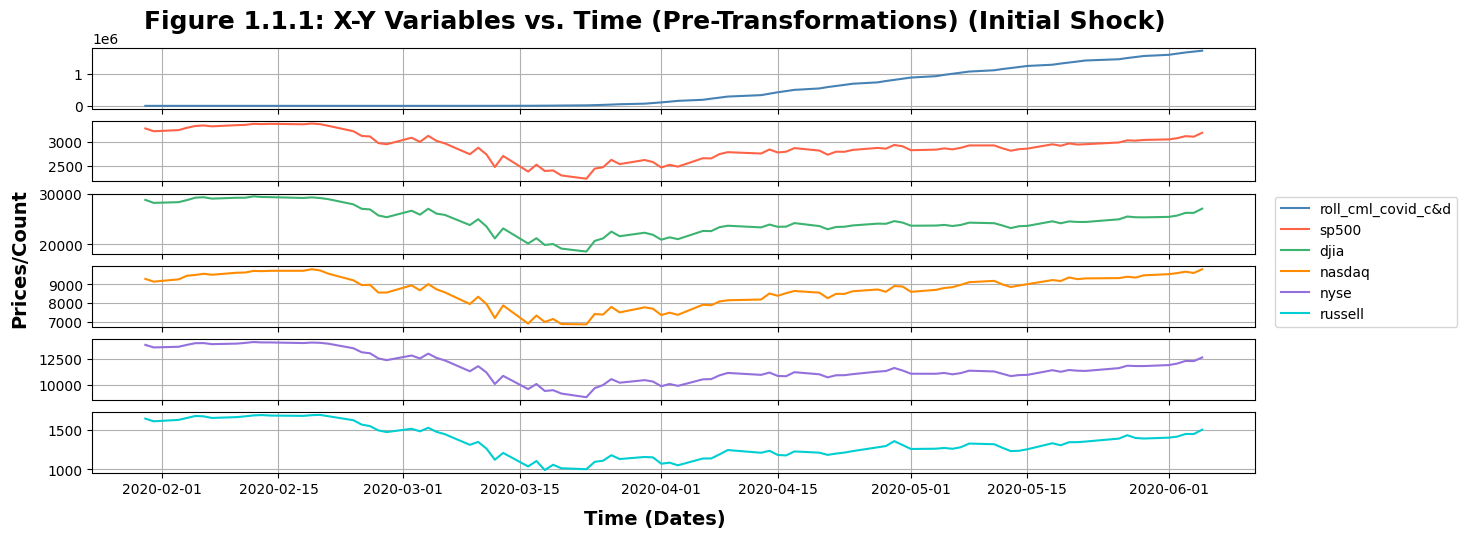

In [16]:
title = f'Figure 1.1.1: X-Y Variables vs. Time (Pre-Transformations) {PRD}'

econ_anlys_vrb.set_coords('1.1.1', PRD, XCAT, YCOL)


matplotlibx.setup_stacked_line_charts(len(ttl_dict))

matplotlibx.set_line_multichart_xysuplabels('Time (Dates)', 'Prices/Count')

matplotlibx.set_line_multichart_suptitle_xycoords(0.5, 0.95)

matplotlibx.set_line_multichart_supxlabel_xycoords(0.5, 0.01)

matplotlibx.set_line_multichart_supylabel_xycoords(0.07, 0.5)


matplotlibx.line_multichart(test_df, title)

## **1.1.2: Transformation: X-Y Variables**

### **The Zivot-Andrews Test: X-Y Variables (Pre-Transformations)**

In [17]:
title = 'Table 1.1.2.1: The Zivot-Andrews Test ' \
            + f'- {XTTL} vs. {YSBJ} (Pre-Transformations) {PRD}'

test_df = mathx.zivot_andrews_test_summ_df(ttl_dict, autolag = 'AIC')

pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False).format('{:,.4f}', subset = ['p_value'])

,za_stat,p_value,1%,5%,10%,n_obs,lags_used,break_sq_idx,break_index,break_pct,regr_mthd,autolag,rejects_5pct,stationary
series,,,,,,,,,,,,,,
roll_cml_covid_c&d,-5.28,0.0059,-5.03,-4.41,-4.14,89,10,36,2020-03-23,40.4%,trend only,AIC,True,stationary with break
sp500,-5.85,0.0042,-5.58,-5.07,-4.83,89,9,28,2020-03-11,31.5%,constant and trend,AIC,True,stationary with break
djia,-5.49,0.0148,-5.58,-5.07,-4.83,89,7,27,2020-03-10,30.3%,constant and trend,AIC,True,stationary with break
nasdaq,-6.07,0.0020,-5.58,-5.07,-4.83,89,9,28,2020-03-11,31.5%,constant and trend,AIC,True,stationary with break
nyse,-5.47,0.0158,-5.58,-5.07,-4.83,89,7,28,2020-03-11,31.5%,constant and trend,AIC,True,stationary with break
russell,-5.75,0.0055,-5.58,-5.07,-4.83,89,7,28,2020-03-11,31.5%,constant and trend,AIC,True,stationary with break


### **The Bai-Perron Test: X-Y Variables (Pre-Transformations)**

In [18]:
title = 'Table 1.1.2.2: The Bai-Perron Test ' \
            + f'- {XTTL} vs. {YSBJ} (Pre-Transformations) {PRD}'

test_df = mathx.bai_perron_test_summ_df(ttl_dict)

pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False)

,n_breaks,break_indices,break_pcts,n_obs,model,model_desc,algorithm
series,,,,,,,
roll_cml_covid_c&d,1,[55],[61.8],89,l2,mean shift detection (changes in level),pelt
sp500,1,[30],[33.7],89,l2,mean shift detection (changes in level),pelt
djia,1,[30],[33.7],89,l2,mean shift detection (changes in level),pelt
nasdaq,1,[55],[61.8],89,l2,mean shift detection (changes in level),pelt
nyse,1,[30],[33.7],89,l2,mean shift detection (changes in level),pelt
russell,1,[30],[33.7],89,l2,mean shift detection (changes in level),pelt


### **The Augmented Dickey-Fuller (ADF) Test: X-Y Variables (Pre-Transformations)**

In [19]:
title = 'Table 1.1.2.3: The Augmented Dickey-Fuller (ADF) Test ' \
            + f'- {XTTL} vs. {YSBJ} (Pre-Transformations) {PRD}'

test_df = mathx.adf_test_summ_df(ttl_dict)

pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False).format('{:,.4f}', subset = ['p_value'])

,adf_stat,p_value,used_lag,n_obs,1%,5%,10%,margin,regr. mthd.,autolag,stationary
series,,,,,,,,,,,
roll_cml_covid_c&d,-2.73,0.2252,10,78,-4.08,-3.47,-3.16,0.74,constant and trend,t-stat,False
sp500,-2.41,0.1386,12,76,-3.52,-2.90,-2.59,0.49,constant only,None,False
djia,-2.37,0.1492,12,76,-3.52,-2.90,-2.59,0.53,constant only,None,False
nasdaq,-1.87,0.3461,12,76,-3.52,-2.90,-2.59,1.03,constant only,None,False
nyse,-2.49,0.1168,12,76,-3.52,-2.90,-2.59,0.41,constant only,None,False
russell,-2.45,0.1287,12,76,-3.52,-2.90,-2.59,0.45,constant only,None,False


### **The Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test: X-Y Variables (Pre-Transformations)** 

In [20]:
title = 'Table 1.1.2.4: The KPSS Test ' \
            + f'- {XTTL} vs. {YSBJ} (Pre-Transformations) {PRD}'

test_df = mathx.kpss_test_summ_df(ttl_dict)

pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False).format('{:,.4f}', subset = ['p_value'])

,kpss_stat,p_value,n_lags,n_lags_used,1%,5%,10%,margin,regr. mthd.,stationary
series,,,,,,,,,,
roll_cml_covid_c&d,0.21,0.0132,legacy,12,0.22,0.15,0.12,0.06,constant and trend,False
sp500,0.22,0.1000,legacy,12,0.74,0.46,0.35,-0.24,constant only,True
djia,0.28,0.1000,legacy,12,0.74,0.46,0.35,-0.18,constant only,True
nasdaq,0.18,0.1000,legacy,12,0.74,0.46,0.35,-0.28,constant only,True
nyse,0.33,0.1000,legacy,12,0.74,0.46,0.35,-0.13,constant only,True
russell,0.31,0.1000,legacy,12,0.74,0.46,0.35,-0.15,constant only,True


### **Cross-Validation for Stationarity - X-Y Variables (Pre-Transformations)** 

In [21]:
title = 'Table 1.1.2.5: The Cross-Validation for Stationarity ' \
            + f'- {XTTL} vs. {YSBJ} (Pre-Transformations) {PRD}'

test_df = mathx.crss_valid_for_stnry_df(ttl_dict)

pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False)

,adf_stationary,kpss_stationary,result,conclusion,recommendation
series,,,,,
roll_cml_covid_c&d,False,False,inconclusive,Results conflict.,"Try log, differencing, and box-cox."
sp500,False,True,trend-stationary,Stationary around a trend.,"Try detrending, differencing, and log."
djia,False,True,trend-stationary,Stationary around a trend.,"Try detrending, differencing, and log."
nasdaq,False,True,trend-stationary,Stationary around a trend.,"Try detrending, differencing, and log."
nyse,False,True,trend-stationary,Stationary around a trend.,"Try detrending, differencing, and log."
russell,False,True,trend-stationary,Stationary around a trend.,"Try detrending, differencing, and log."


### **Transformations for Stationarity - X-Y Variables**

In [22]:
trns_df = mathx.crct_stnry_df(ttl_dict)

NON-STATIONARY TIME SERIES DETECTED: roll_cml_covid_c&d.

Exponential trend detected:
logarithm and differencing applied to time series roll_cml_covid_c&d...
Differencing (period = 1) time series roll_cml_covid_c&d...


DIFFERENCE STATIONARY TIME SERIES DETECTED: sp500.

Linear trend detected:
Detrending (first degree polynomial) time series sp500...



DIFFERENCE STATIONARY TIME SERIES DETECTED: djia.

Linear trend detected:
Detrending (first degree polynomial) time series djia...

Differencing (period = 1) time series djia...



DIFFERENCE STATIONARY TIME SERIES DETECTED: nasdaq.

Detrending (optimal polynomial degree) time series nasdaq...



DIFFERENCE STATIONARY TIME SERIES DETECTED: nyse.

Linear trend detected:
Detrending (first degree polynomial) time series nyse...

Differencing (period = 1) time series nyse...



DIFFERENCE STATIONARY TIME SERIES DETECTED: russell.

Linear trend detected:
Detrending (first degree polynomial) time series russell...

Differencing (period = 1) t

### **Cross-Validation for Stationarity - X-Y Variables (Post-Transformations)** 

In [23]:
title = 'Table 1.1.2.6: Corrections for Stationarity ' \
            + f'- {XTTL} vs. {YSBJ} (Post-Transformations) {PRD}'

test_df = mathx.crss_valid_for_stnry_df(trns_df.to_dict(orient = 'series'))

pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False)

,adf_stationary,kpss_stationary,result,conclusion,recommendation
series,,,,,
roll_cml_covid_c&d,True,True,stationary,Both tests agree the series is stationary.,No action needed.
sp500,False,True,trend-stationary,Stationary around a trend.,"Try detrending, differencing, and log."
djia,True,True,stationary,Both tests agree the series is stationary.,No action needed.
nasdaq,True,True,stationary,Both tests agree the series is stationary.,No action needed.
nyse,True,True,stationary,Both tests agree the series is stationary.,No action needed.
russell,True,True,stationary,Both tests agree the series is stationary.,No action needed.


### **The Zivot-Andrews Test: X-Y Variables (Post-Transformations)**

In [24]:
title = 'Table 1.1.2.7: The Zivot-Andrews Test ' \
            + f'- {XTTL} vs. {YSBJ} (Post-Transformations) {PRD}'

test_df = mathx.zivot_andrews_test_summ_df(trns_df.to_dict(orient = 'series'))

pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False).format('{:,.4f}', subset = ['p_value'])

,za_stat,p_value,1%,5%,10%,n_obs,lags_used,break_sq_idx,break_index,break_pct,regr_mthd,autolag,rejects_5pct,stationary
series,,,,,,,,,,,,,,
roll_cml_covid_c&d,-8.06,0.0009,-5.58,-5.07,-4.83,87,4,25,2020-03-10,28.7%,constant and trend,BIC,True,stationary with break
sp500,-4.47,0.0435,-5.03,-4.41,-4.14,87,1,30,2020-03-17,34.5%,trend only,BIC,True,stationary with break
djia,-15.59,0.0007,-5.58,-5.07,-4.83,87,0,34,2020-03-23,39.1%,constant and trend,BIC,True,stationary with break
nasdaq,-5.27,0.0060,-5.03,-4.41,-4.14,87,3,23,2020-03-06,26.4%,trend only,BIC,True,stationary with break
nyse,-14.78,0.0007,-5.58,-5.07,-4.83,87,0,34,2020-03-23,39.1%,constant and trend,BIC,True,stationary with break
russell,-14.34,0.0008,-5.58,-5.07,-4.83,87,0,31,2020-03-18,35.6%,constant and trend,BIC,True,stationary with break


### **The Bai-Perron Test: X-Y Variables (Post-Transformations)**

In [25]:
title = 'Table 1.1.2.8: The Bai-Perron Test ' \
            + f'- {XTTL} vs. {YSBJ} (Post-Transformations) {PRD}'

test_df = mathx.bai_perron_test_summ_df(trns_df.to_dict(orient = 'series'))

pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False)

,n_breaks,break_indices,break_pcts,n_obs,model,model_desc,algorithm
series,,,,,,,
roll_cml_covid_c&d,0,n/a,n/a,87,l2,mean shift detection (changes in level),pelt
sp500,1,[55],[63.2],87,l2,mean shift detection (changes in level),pelt
djia,1,[35],[40.2],87,l2,mean shift detection (changes in level),pelt
nasdaq,1,[35],[40.2],87,l2,mean shift detection (changes in level),pelt
nyse,1,[35],[40.2],87,l2,mean shift detection (changes in level),pelt
russell,1,[35],[40.2],87,l2,mean shift detection (changes in level),pelt


### **Display X-Y Variables (Post-Transformations)**

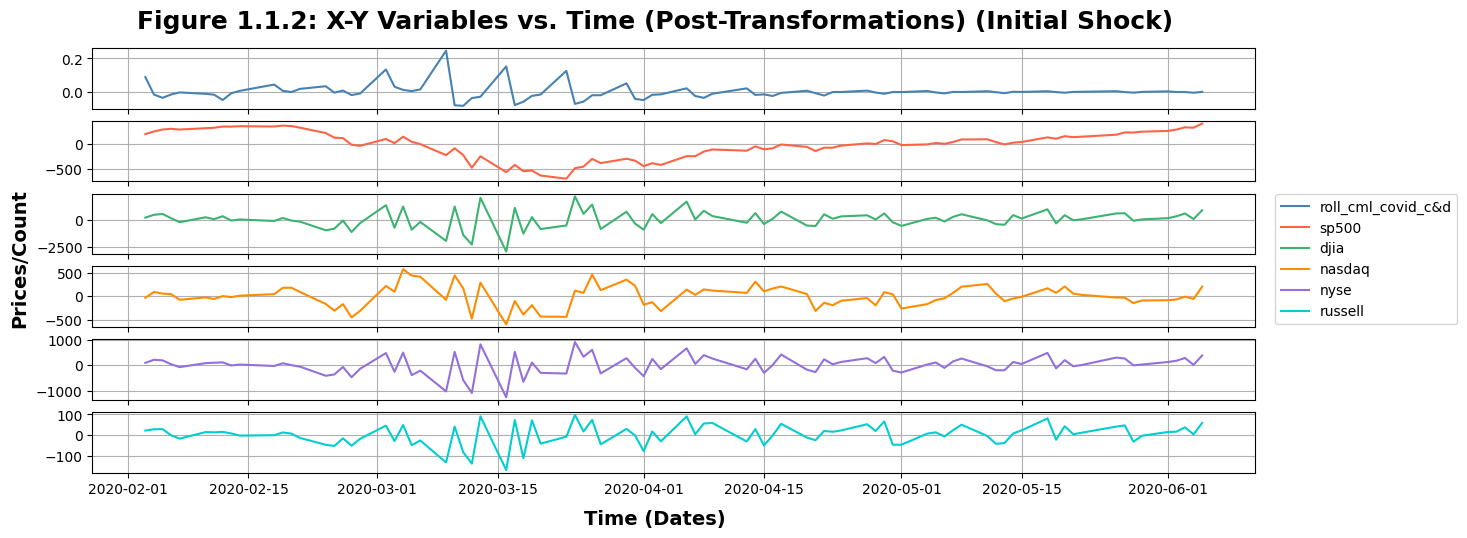

In [26]:
title = f'Figure 1.1.2: X-Y Variables vs. Time (Post-Transformations) {PRD}'

econ_anlys_vrb.set_coords('1.1.2', PRD, XCAT, YCOL)
        

matplotlibx.set_line_multichart_xysuplabels('Time (Dates)', 'Prices/Count')

matplotlibx.set_line_multichart_suptitle_xycoords(0.5, 0.95)

matplotlibx.set_line_multichart_supxlabel_xycoords(0.5, 0.01)

matplotlibx.set_line_multichart_supylabel_xycoords(0.07, 0.5)


matplotlibx.line_multichart(trns_df, title)

### **Assign Data to Series - X-Y Variables (Post-Transformations)**

In [27]:
if YPCT:

    x_series  = trns_df[XCAT]

    y1_series = trns_df[YCAT[Y.Y1.value] + '%']

    y2_series = trns_df[YCAT[Y.Y2.value] + '%']

    y3_series = trns_df[YCAT[Y.Y3.value] + '%']

    y4_series = trns_df[YCAT[Y.Y4.value] + '%']

    y5_series = trns_df[YCAT[Y.Y5.value] + '%']

else:

    x_series  = trns_df[XCAT]

    y1_series = trns_df[YCAT[Y.Y1.value]]

    y2_series = trns_df[YCAT[Y.Y2.value]]

    y3_series = trns_df[YCAT[Y.Y3.value]]

    y4_series = trns_df[YCAT[Y.Y4.value]]

    y5_series = trns_df[YCAT[Y.Y5.value]]

---

## Interpretation: Section 1.1.2 — Stationarity Analysis and Transformations

**Pre-Transformation Findings.** The Zivot-Andrews test (Table 1.1.2.1) and Bai-Perron test (Table 1.1.2.2) are applied to detect structural breaks in each series before any stationarity correction. The `covid_c&d` series, being a rolling cumulative count, is monotonically increasing across the Initial Shock window and will typically show a structural break at the point where U.S. case growth transitioned to exponential spread (mid-March 2020). The stock market indices will show a prominent downward break in late February / early March 2020 corresponding to the equity crash, and potentially a second upward break in late March 2020 at the start of the recovery. The presence of multiple structural breaks in a short window (137 days) means that standard ADF and KPSS tests may misdiagnose the stationarity regime; the cross-validation table (Table 1.1.2.5) synthesizes all four tests to produce a consensus stationarity determination.

**ADF and KPSS Diagnostics.** The ADF test (Table 1.1.2.3) tests the null hypothesis of a unit root; failure to reject implies non-stationarity. The KPSS test (Table 1.1.2.4) tests the null of stationarity; rejection implies non-stationarity. Both are expected to classify all level series as non-stationary, though the direction and severity of trend in each series will produce different test statistics. Conflicting ADF/KPSS results — where one test rejects and the other does not — indicate a series that is on the boundary between integrated and trend-stationary processes, which is common for equity indices over short, event-driven windows.

**Transformation Pipeline.** The `mathx.crct_stnry_df()` function applies the minimum differencing or detrending needed to make each series stationary, as confirmed in Tables 1.1.2.5–1.1.2.6. Post-transformation cross-validation (Table 1.1.2.6) and the post-transformation Zivot-Andrews results (Table 1.1.2.7) confirm whether the correction is adequate. Figure 1.1.2 provides a visual comparison of all series after transformation, which should show mean-reverting behavior without the strong downward-then-upward trend visible in Figure 1.1.1. All downstream causal tests in Sections 1.1.3–1.1.8 operate on these transformed, stationary series.

---


## **1.1.3: X vs. Y1**

### **Create DataFrame X vs. Y1**

In [28]:
comp_df \
    = pd.DataFrame \
        ({XCAT:             x_series,
          YCAT[Y.Y1.value]: y1_series})

logx.log_write_obj(comp_df)

In [29]:
title = f'Table 1.1.3.1: {XTTL} vs. {YTTL[Y.Y1.value]} {PRD}'

pandasx.rtn_fmt_tbl \
    (comp_df, title, hide_idx_bool = False) \
        .format({XCAT:             pandasx.fmt_dict['flt_int'],
                 YCAT[Y.Y1.value]: pandasx.fmt_dict['flt_int']})

,roll_cml_covid_c&d,sp500
series,,
2020-02-03,0,207
2020-02-04,-0,258
2020-02-05,-0,299
2020-02-06,-0,313
2020-02-07,-0,298
2020-02-10,-0,325
2020-02-11,-0,334
2020-02-12,-0,359
2020-02-13,-0,357


### **AIC, Cross-validated R², and Overfitting Score for Polynomial Degree: X vs. Y1**

In [30]:
title = 'Table 1.1.3.2: AIC, Cross-validated R², and Overfitting Score for Polynomial Degree ' \
            + f'- {XTTL} vs. {YTTL[Y.Y1.value]} {PRD}'


best_deg, scores_dict, _, results_df = mathx.opt_poly_degree(y1_series, x_series)

corr_method = mathx.find_opt_corr_method(y1_series, x_series)


pandasx.rtn_fmt_tbl(results_df, title) \
    .map(pandasx.highlight_bool_col, subset = ['overfit']) \
    .apply(pandasx.highlight_val_row, col = 'degree', val = best_deg, axis = 1)

degree,train_r2,cv_r2,cv_r2_std,cv_norm,aic,aic_norm,overfit,combined_score
1,0.00,-0.28,0.28,1.00,-530.08,0.54,True,0.77
2,0.01,-0.79,1.07,1.00,-528.55,0.39,True,0.69
3,0.09,-4.38,7.90,0.97,-533.99,0.93,True,0.95
4,0.12,-1.65,1.43,0.99,-534.75,1.00,True,1.00
5,0.13,-7.86,10.43,0.95,-534.26,0.95,True,0.95
6,0.13,-3.98,6.79,0.97,-532.40,0.77,True,0.87
7,0.14,-20.35,36.95,0.86,-531.11,0.64,True,0.75
8,0.14,-3.76,5.42,0.98,-529.26,0.46,True,0.72
9,0.14,-38.40,75.35,0.73,-527.02,0.24,True,0.49
10,0.14,-141.70,194.94,0.00,-524.57,0.00,True,0.00


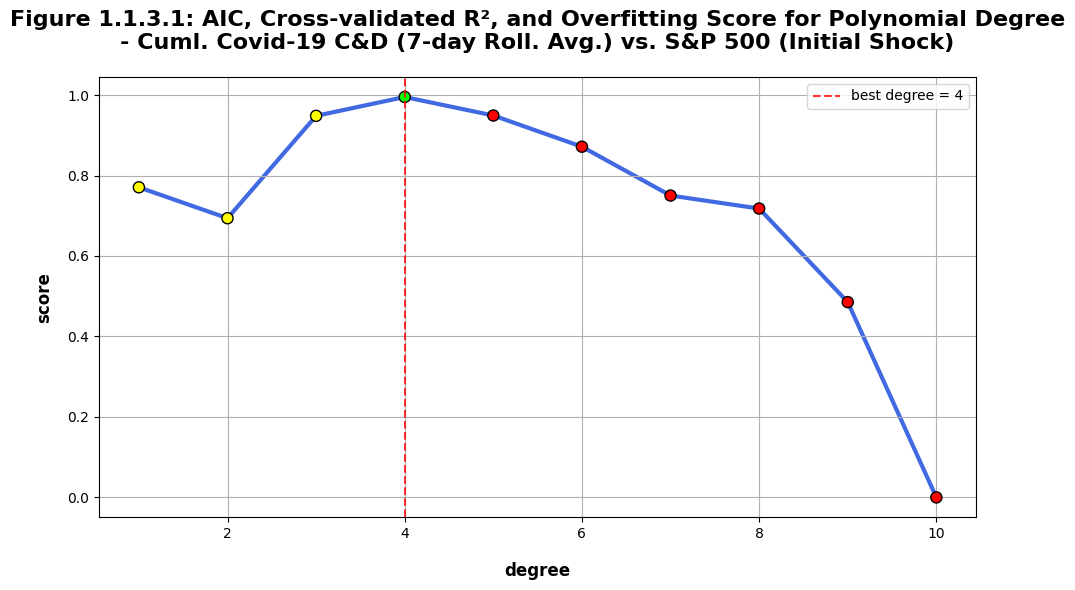

In [31]:
title = 'Figure 1.1.3.1: AIC, Cross-validated R², and Overfitting Score for Polynomial Degree\n' \
            + f'- {XTTL} vs. {YTTL[Y.Y1.value]} {PRD}'


matplotlibx.set_corr_scores_xylabels('degree', 'score')

matplotlibx.set_corr_scores_marker_size(8.0)

matplotlibx.set_lag_corr_method(corr_method)


matplotlibx.plot_corr_scores(scores_dict, title, best_deg)

### **Correlation: X vs. Y1**

In [32]:
title = f'Table 1.1.3.3: Correlation ({corr_method.title()}) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y1.value]} {PRD}'

pandasx.rtn_fmt_tbl(comp_df.corr(method = corr_method), title, hide_idx_bool = False)

,roll_cml_covid_c&d,sp500
roll_cml_covid_c&d,1.00,0.35
sp500,0.35,1.00


### **Scatter Plot: X vs. Y1**

r-value (pearson):	0.042
r-value (spearman):	0.349
tau (kendall):		0.247

p-value (pearson):	0.700
p-value (spearman):	0.001
p-value (kendall):	0.001




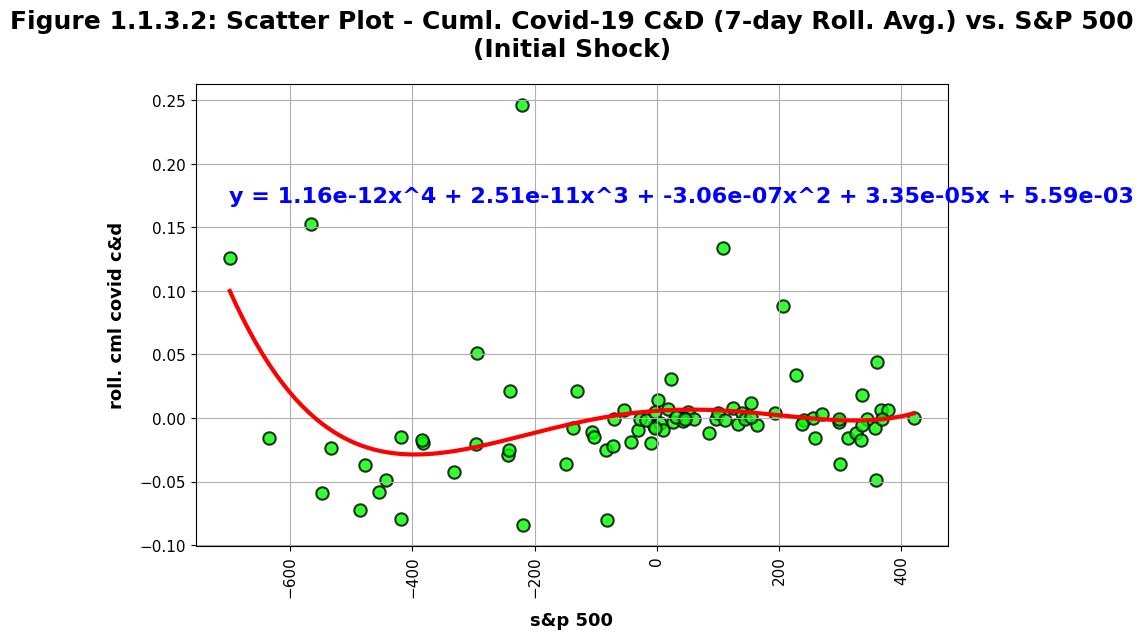

In [33]:
title = 'Figure 1.1.3.2: Scatter Plot ' \
            + f'- {XTTL} vs. {YTTL[Y.Y1.value]}\n{PRD}'

econ_anlys_vrb.set_coords('1.1.3.2', PRD, XCAT, YCOL)


matplotlibx.set_scatterplot_chart_xylabels(YLBL[Y.Y1.value], XLBL)

matplotlibx.set_scatterplot_chart_xylabels_fontsize(13.0, 13.0)

matplotlibx.set_scatterplot_chart_xyticks_fontsize(11.0, 11.0)

matplotlibx.set_scatterplot_chart_title_fontsize(18.0)

matplotlibx.set_regr_degree(best_deg)


matplotlibx.scatterplot_chart([y1_series, x_series], title)

### **The Granger Causality Test: X -> Y1**

In [34]:
title = 'Table 1.1.3.4: The Granger Causality Test ' \
            + f'- {XTTL} -> {YTTL[Y.Y1.value]} {PRD}'


grngr_mth, _, _    = mathx.find_optimal_granger_method(x_series, y1_series)

g_lag, _           = mathx.find_optimal_granger_lag(x_series, y1_series, method = grngr_mth)

test_df, best_dict = mathx.granger_causality_test(x_series, y1_series, maxlag = g_lag, method = grngr_mth)


grngr_bst_list = [best_dict]

grngr_nm_list  = [f'{XCAT} -> {YCAT[Y.Y1.value]}']


pandasx.rtn_fmt_tbl \
    (test_df, title, hide_idx_bool = False, line_cnt_int = len(test_df)) \
        .apply(pandasx.highlight_median_row,    col = 'f_p_value', df = test_df, axis = 1) \
        .apply(pandasx.highlight_high_low_rows, col = 'f_p_value', df = test_df, axis = 1) \
        .format('{:,.6f}', subset = ['f_statistic', 'f_p_value'])

,f_statistic,f_p_value,f_significant,chi2_significant,lrtest_significant,params_f_significant,conclusion
lag,,,,,,,
1,6.795457,0.010832,True,True,True,True,high confidence


### **The Granger Causality Test: Y1 -> X**

In [35]:
title = 'Table 1.1.3.5: The Granger Causality Test ' \
            + f'- {YTTL[Y.Y1.value]} -> {XTTL} {PRD}'


test_df, best_dict = mathx.granger_causality_test(y1_series, x_series, maxlag = g_lag, method = grngr_mth)


grngr_bst_list += [best_dict]

grngr_nm_list  += [f'{YCAT[Y.Y1.value]} -> {XCAT}']


pandasx.rtn_fmt_tbl \
    (test_df, title, hide_idx_bool = False, line_cnt_int = len(test_df)) \
        .apply(pandasx.highlight_median_row,    col = 'f_p_value', df = test_df, axis = 1) \
        .apply(pandasx.highlight_high_low_rows, col = 'f_p_value', df = test_df, axis = 1) \
        .format('{:,.6f}', subset = ['f_statistic', 'f_p_value'])

,f_statistic,f_p_value,f_significant,chi2_significant,lrtest_significant,params_f_significant,conclusion
lag,,,,,,,
1,1.518204,0.221371,False,False,False,False,high confidence
2,1.538154,0.221061,False,False,False,False,high confidence
3,2.069456,0.111169,False,False,False,False,high confidence
4,2.197143,0.077504,False,True,False,False,inconclusive results
5,1.482742,0.206313,False,False,False,False,high confidence


### **VAR/VECM Analysis: X vs. Y1**

In [36]:
results_dict = mathx.fit_var_or_vecm(x_series, y1_series)

x_y1_analysis_df = results_dict['summary_df']


title = f'VAR/VECM Analysis: {XTTL} -> {YTTL[Y.Y1.value]} {PRD}'

msg = results_dict['conclusion']


logx.print_and_log_text('\033[1m' + msg + '\033[0m')

logx.write_to_folder(msg, title)

ROLL_CML_COVID_C&D VS. SP500 ANALYSIS

Model selected: VECM.

Series 'x' is non-stationary (ADF = -2.498188, p = 0.115916).

Series 'y' is non-stationary (ADF = -1.932783, p = 0.316800).

Trace and max-eigenvalue tests agree. Both series appear stationary at levels — VAR on levels is appropriate.

Recommended lag (BIC): 5.
AIC = 9, BIC = 5, HQIC = 8, FPE = 9.

VECM(lag = 4, rank = 1) fitted. Adjustment speeds — x: -0.433346, y: -1518.715633. Error correction half-life: inf periods. x - (0.000009) * y = 0  (long-run equilibrium). Mean reversion: CONFIRMED.

IRF (VECM, 30 periods):
A one-SD shock to x produces a negative net response in y.
Peak x→y effect at lag 30 (magnitude: -2682.813359).
Cumulative x→y response: -58155.456480.

FEVD (VECM, horizon = 31):
x shocks explain 48.669786% of y's forecast variance (substantial influence).
y's own shocks explain 51.330214% of its own variance.



### **Impulse Response Functions (IRF): X vs. Y1**

In [37]:
title = 'Table 1.1.3.6: Impulse Response Functions (IRF) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y1.value]} {PRD}'

try:

    test_df = results_dict['irf_result']['irf_df']

    irf_bool = True

    if len(test_df) > 0:

        display \
            (pandasx.rtn_fmt_tbl \
                (test_df, 
                 title, 
                 hide_idx_bool = False, 
                 line_cnt_int = len(test_df)) \
                    .highlight_min(color = 'mistyrose') \
                    .highlight_max(color = 'greenyellow') \
                    .apply(pandasx.highlight_median_col) \
                    .format('{:,.6f}'))

    else:

        irf_bool = False

        logx.write_to_folder \
            ('\nThere is no Impulse Response Function present with VECM model: ' \
                 + f'{XTTL} vs. {YTTL[Y.Y1.value]} {PRD}\n')
    
except:

    irf_bool = False

    logx.write_to_folder \
        ('\nThere is no Impulse Response Function present with VECM model: ' \
             + f'{XTTL} vs. {YTTL[Y.Y1.value]} {PRD}\n')

,x_shock_x_response,x_shock_y_response,y_shock_x_response,y_shock_y_response
period,,,,
0,1.000000,0.000000,0.000000,1.000000
1,-0.015074,112.653414,0.000053,0.652717
2,-0.140884,-81.490334,-0.000009,1.011862
3,0.041384,-591.358539,0.000068,0.910196
4,-0.048480,-715.123979,-0.000043,0.876606
5,0.690688,"-1,331.548354",0.000019,0.923853
6,-0.065999,"-1,072.281489",0.000039,0.804229
7,-0.196093,"-1,289.359693",-0.000016,0.887047
8,0.031320,"-1,648.916168",0.000057,0.805523


### **Forecast Error Variance Decomposition (FEVD): X vs. Y1**

In [38]:
if irf_bool:
    
    title = 'Table 1.1.3.7: Forecast Error Variance Decomposition (FEVD) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y1.value]} {PRD}'

else:

    title = 'Table 1.1.3.6: Forecast Error Variance Decomposition (FEVD) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y1.value]} {PRD}'    

test_df = results_dict['fevd_result']['fevd_df']

pandasx.rtn_fmt_tbl \
    (test_df, 
     title, 
     hide_idx_bool = False, 
     line_cnt_int = len(test_df)) \
        .highlight_min(color = 'mistyrose') \
        .highlight_max(color = 'greenyellow') \
        .apply(pandasx.highlight_median_col) \
        .format('{:,.6f}')

,y_variance_from_x,y_variance_from_y,x_variance_from_x,x_variance_from_y
period,,,,
0,0.017539,0.982461,1.000000,0.000000
1,0.013125,0.986875,0.977600,0.022400
2,0.016758,0.983242,0.977977,0.022023
3,0.045359,0.954641,0.951893,0.048107
4,0.068086,0.931914,0.943841,0.056159
5,0.124157,0.875843,0.956447,0.043553
6,0.145328,0.854672,0.946136,0.053864
7,0.170267,0.829733,0.947648,0.052352
8,0.207978,0.792022,0.932427,0.067573


### **Rolling R, Stability, and CV Score for Rolling Window: X vs. Y1**

In [39]:
best_w, _, results_df \
    = mathx.find_optimal_rolling_window \
        (x_series, y1_series, method = corr_method)

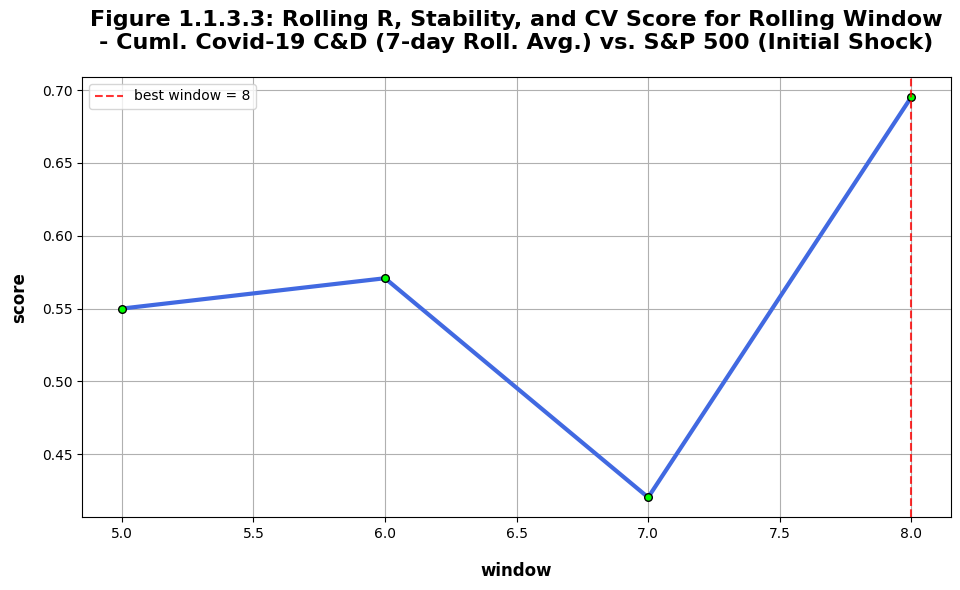

In [40]:
title = 'Figure 1.1.3.3: Rolling R, Stability, and CV Score for Rolling Window\n' \
            + f'- {XTTL} vs. {YTTL[Y.Y1.value]} {PRD}'


matplotlibx.set_corr_scores_xylabels('window', 'score')

matplotlibx.set_corr_scores_marker_size(5.5)


matplotlibx.plot_corr_scores(results_df.loc[:,'score'].to_dict(), title)

### **Rolling R, Stability, and CV Score for Minimum Period: X vs. Y1**

In [41]:
best_mp, _, results_df \
    = mathx.find_optimal_min_periods \
        (x_series, y1_series, best_w, method = corr_method)

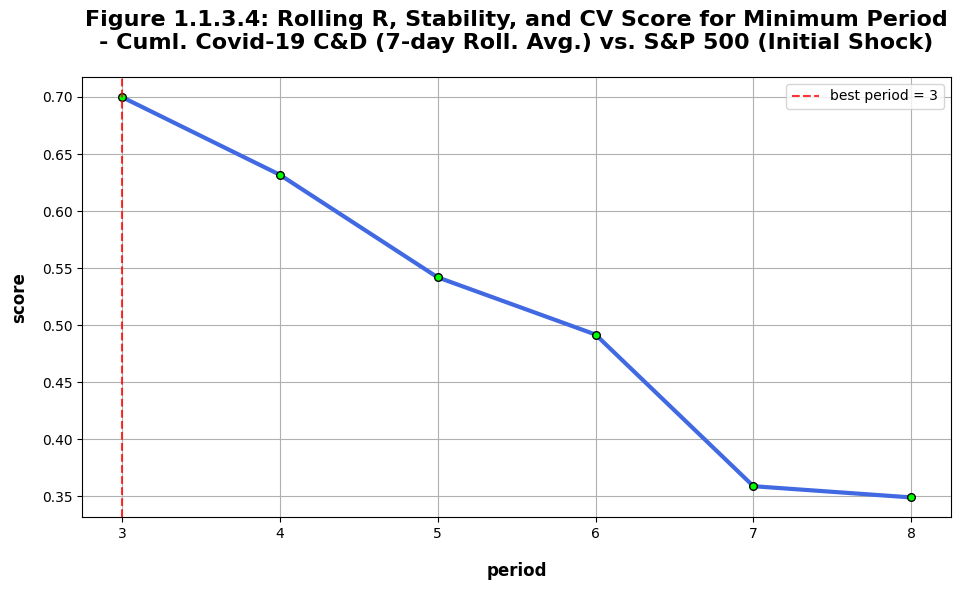

In [42]:
title = 'Figure 1.1.3.4: Rolling R, Stability, and CV Score for Minimum Period\n' \
            + f'- {XTTL} vs. {YTTL[Y.Y1.value]} {PRD}'


matplotlibx.set_corr_scores_xylabels('period', 'score')

matplotlibx.set_corr_scores_marker_size(5.5)


matplotlibx.plot_corr_scores(results_df.loc[:,'score'].to_dict(), title)

### **Rolling Correlation: X vs. Y1**

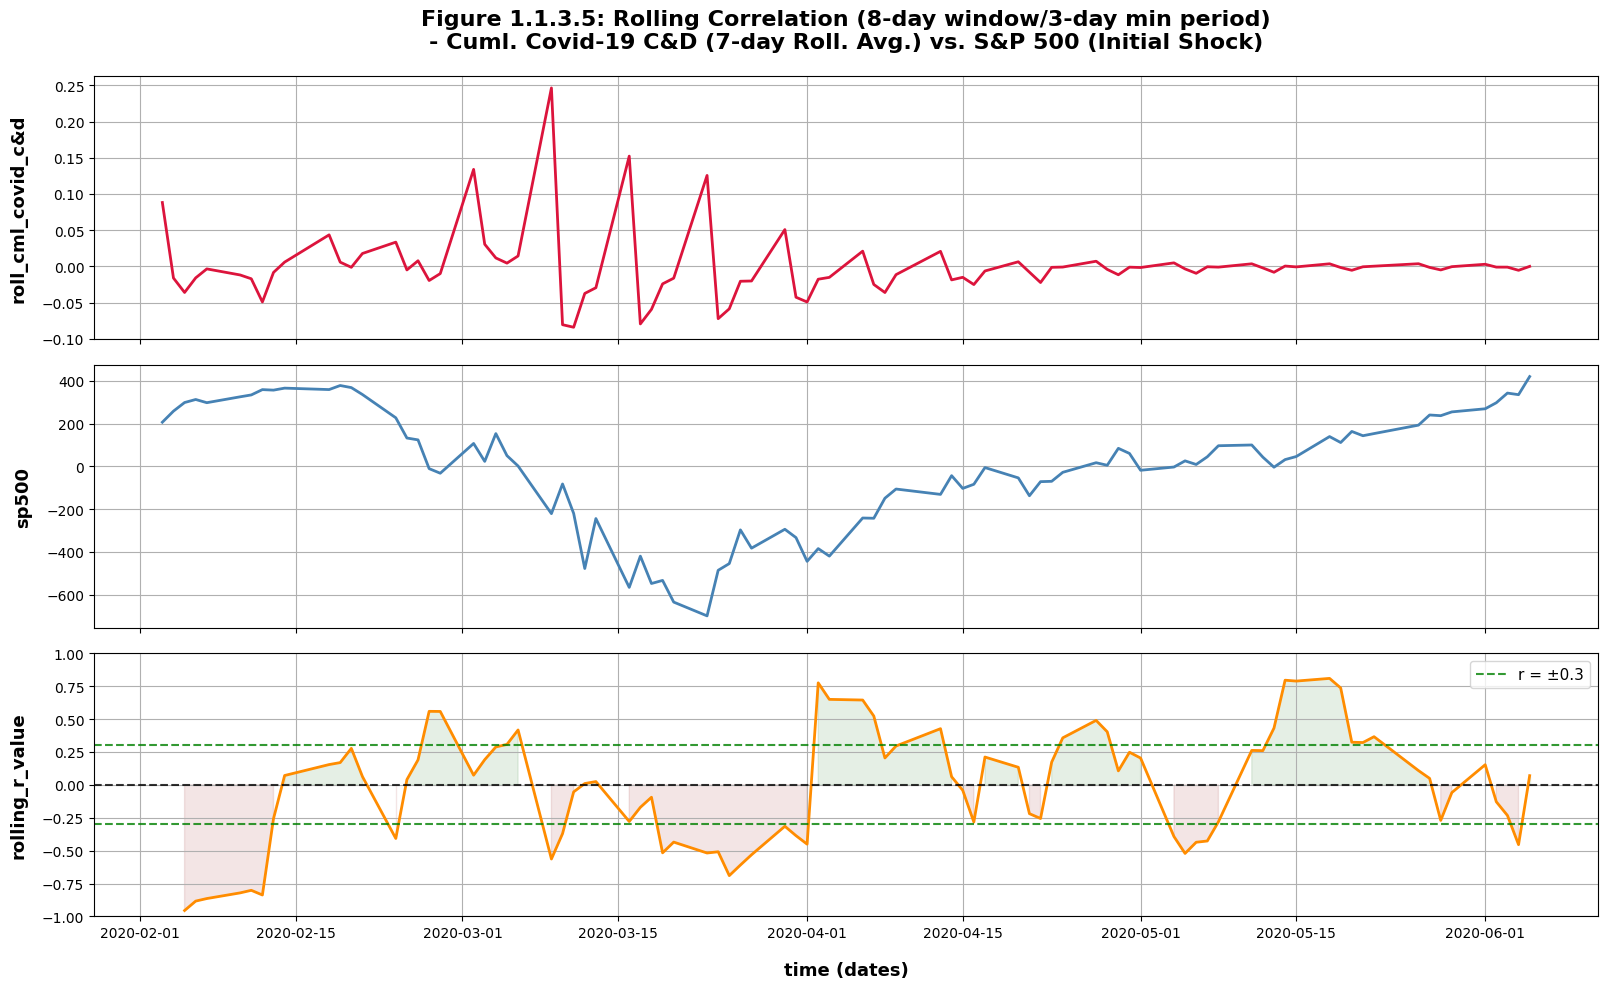

In [43]:
title \
    = f'Figure 1.1.3.5: Rolling Correlation ({best_w}-day window/{best_mp}' \
        + f'-day min period)\n- {XTTL} vs. {YTTL[Y.Y1.value]} {PRD}'


matplotlibx.set_roll_corr_xylabels('time (dates)', [])

matplotlibx.set_roll_corr_w_mp(best_w, best_mp)


matplotlibx.plot_rolling_corr_lines(x_series, y1_series, title)

### **Lag Correlation: X vs. Y1**

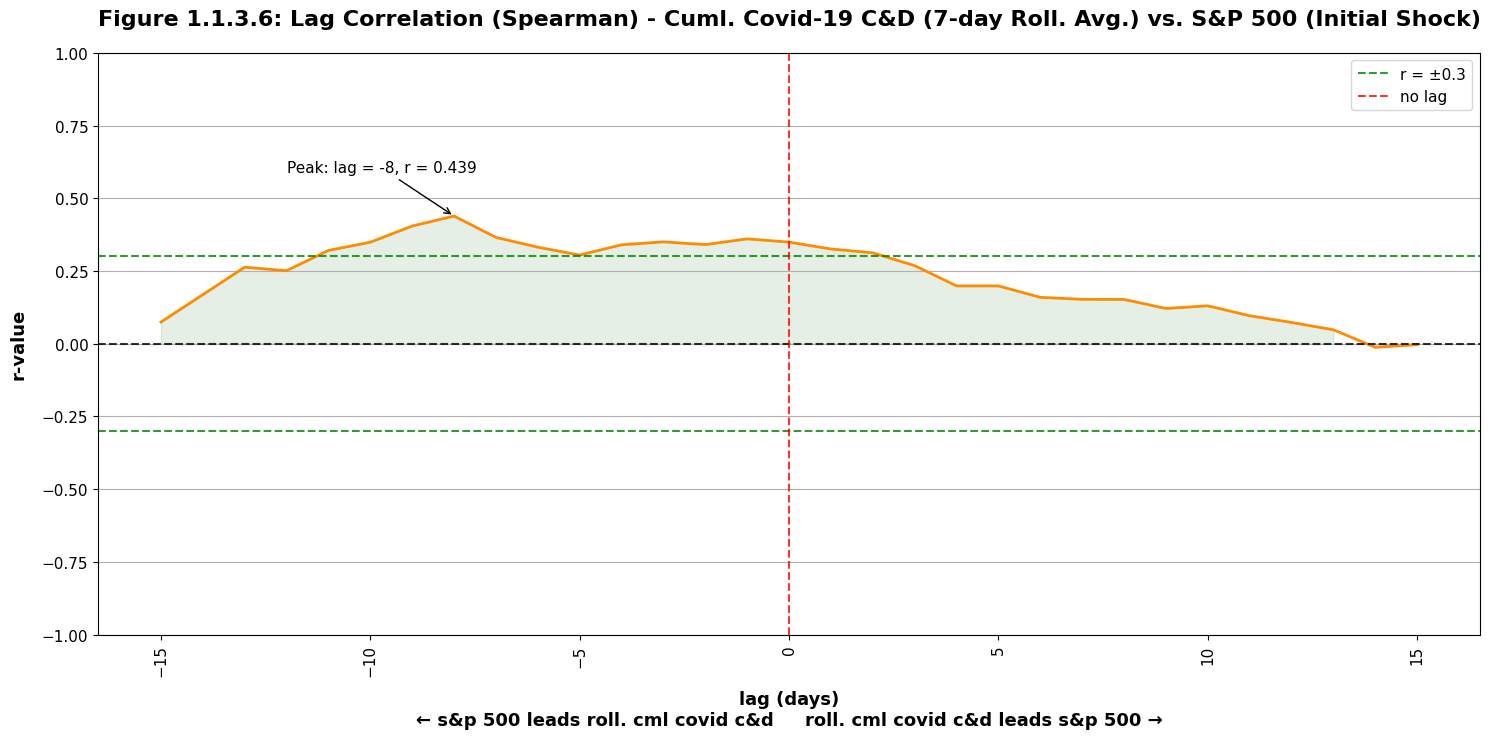

In [44]:
title = f'Figure 1.1.3.6: Lag Correlation ({corr_method.title()}) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y1.value]} {PRD}'

econ_anlys_vrb.set_coords('1.1.3.6', PRD, XCAT, YCOL)


v_lag       = int(x_y1_analysis_df.loc[0, 'lag'])

max_lag     = mathx.find_optimal_lag_corr_maxlag(x_series, y1_series, v_lag, g_lag)

max_max_lag = max_lag


matplotlibx.set_lag_corr_xylabels(XLBL, YLBL[Y.Y1.value])

matplotlibx.plot_lag_corr_line_chart(x_series, y1_series, title, max_lag = max_lag)

---

## Interpretation: Section 1.1.3 — `covid_c&d` (7-Day Rolling Avg) vs. Y1 (Stock Market Index 1)

**Correlation and Functional Form.** The polynomial degree optimization (Table 1.1.3.2 and Figure 1.1.3.1) selects the best-fit degree by balancing AIC improvement against cross-validated R² and overfitting risk. A degree-1 (linear) fit that is not flagged as overfitting implies a stable, proportional relationship; a higher degree that avoids overfitting suggests a nonlinear response — for example, markets may have crashed sharply once case counts crossed a threshold, producing a step-function-like relationship rather than a smooth linear one. The correlation table (Table 1.1.3.3) and scatter plot (Figure 1.1.3.2) together indicate the strength and direction of the contemporaneous association after stationarity corrections. A strong negative correlation would be consistent with rising COVID data tracking falling equity prices in the crash phase.

**Granger Causality.** Tables 1.1.3.4 and 1.1.3.5 test causality in both directions. The critical comparison is whether X→Y1 (COVID data predicts this index) is significant while Y1→X (this index predicts COVID data) is not. Asymmetric Granger causality in the X→Y direction supports the interpretation that pandemic case growth was driving market expectations rather than markets anticipating COVID dynamics. A significant reverse direction (Y1→X) would be unexpected and would likely reflect a spurious statistical relationship driven by the shared trend structure of both series over this short window, rather than genuine feedback.

**VAR/VECM Dynamics.** The IRF table (Table 1.1.3.6) quantifies the market's impulse response to a one-standard-deviation shock in the COVID series — how large the initial impact is, how many days it persists, and whether the effect is monotone or oscillatory. The FEVD table (Table 1.1.3.7) decomposes what fraction of this index's forecast error variance is attributable to the COVID shock versus the index's own innovations at each forecast horizon. A high X-share in the FEVD at short horizons (1–5 days) would confirm that COVID was the dominant near-term driver of this market segment during the Initial Shock.

**Rolling and Lag Correlations.** The rolling correlation (Figure 1.1.3.5) tracks how the strength of the relationship evolved across the 137-day window. Given the structural break from crash to recovery, the rolling correlation is likely to shift sign or magnitude at the inflection point (late March 2020), which would be visible as a change in the rolling R series. The lag correlation (Figure 1.1.3.6) identifies whether the peak correlation between COVID data and this index occurs at a positive lag (X leads Y — consistent with pandemic news driving markets) or at zero/negative lag (contemporaneous or markets leading COVID). A positive lag of 1–7 days would be consistent with investors processing case count information over a weekly cycle, given the 7-day rolling average applied to the X series.

---


## **1.1.4: X vs. Y2**

### **Create DataFrame X vs. Y2**

In [45]:
comp_df \
    = pd.DataFrame \
        ({XCAT:             x_series,
          YCAT[Y.Y2.value]: y2_series})

logx.log_write_obj(comp_df)

In [46]:
title = f'Table 1.1.4.1: {XTTL} vs. {YTTL[Y.Y2.value]} {PRD}'

pandasx.rtn_fmt_tbl \
    (comp_df, title, hide_idx_bool = False) \
        .format({XCAT:             pandasx.fmt_dict['flt_int'],
                 YCAT[Y.Y2.value]: pandasx.fmt_dict['flt_int']})

,roll_cml_covid_c&d,djia
series,,
2020-02-03,0,187
2020-02-04,-0,451
2020-02-05,-0,527
2020-02-06,-0,132
2020-02-07,-0,-234
2020-02-10,-0,218
2020-02-11,-0,43
2020-02-12,-0,319
2020-02-13,-0,-85


### **AIC, Cross-validated R², and Overfitting Score for Polynomial Degree: X vs. Y2**

In [47]:
title = 'Table 1.1.4.2: AIC, Cross-validated R², and Overfitting Score for Polynomial Degree ' \
            + f'- {XTTL} vs. {YTTL[Y.Y2.value]} {PRD}'


best_deg, scores_dict, _, results_df = mathx.opt_poly_degree(y2_series, x_series)

corr_method = mathx.find_opt_corr_method(y2_series, x_series)


pandasx.rtn_fmt_tbl(results_df, title) \
    .map(pandasx.highlight_bool_col, subset = ['overfit']) \
    .apply(pandasx.highlight_val_row, col = 'degree', val = best_deg, axis = 1)

degree,train_r2,cv_r2,cv_r2_std,cv_norm,aic,aic_norm,overfit,combined_score
1,0.09,-2.10,3.50,1.00,-537.67,0.67,True,0.83
2,0.13,-2.22,3.83,1.00,-539.57,0.80,True,0.90
3,0.17,-0.76,0.73,1.00,-542.34,1.00,True,1.00
4,0.17,-0.50,0.42,1.00,-540.35,0.86,True,0.93
5,0.17,-1.55,2.22,1.00,-538.61,0.74,True,0.87
6,0.19,-5.66,10.64,1.00,-538.00,0.69,True,0.85
7,0.20,-1.32,1.44,1.00,-536.97,0.62,True,0.81
8,0.18,"-1,785.10","3,569.67",0.98,-533.00,0.34,True,0.66
9,0.22,-401.48,801.47,0.99,-535.01,0.48,True,0.74
10,0.17,"-76,698.81","153,397.14",0.00,-528.19,0.00,True,0.00


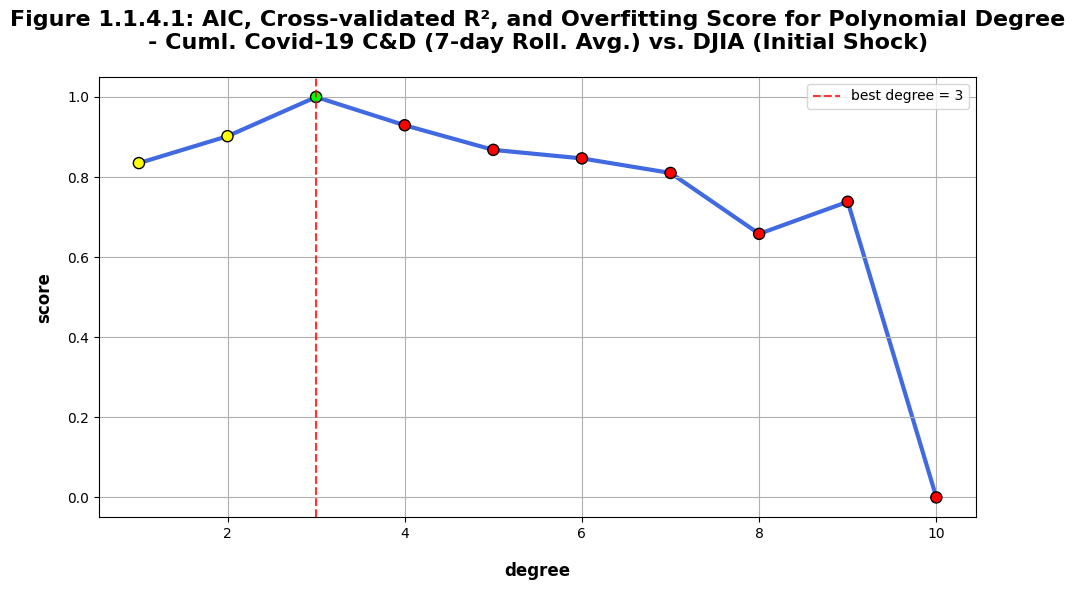

In [48]:
title = 'Figure 1.1.4.1: AIC, Cross-validated R², and Overfitting Score for Polynomial Degree\n' \
            + f'- {XTTL} vs. {YTTL[Y.Y2.value]} {PRD}'


matplotlibx.set_corr_scores_xylabels('degree', 'score')

matplotlibx.set_corr_scores_marker_size(8.0)

matplotlibx.set_lag_corr_method(corr_method)


matplotlibx.plot_corr_scores(scores_dict, title, best_deg)

### **Correlation: X vs. Y2**

In [49]:
title = f'Table 1.1.4.3: Correlation ({corr_method.title()}) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y2.value]} {PRD}'

pandasx.rtn_fmt_tbl(comp_df.corr(method = corr_method), title, hide_idx_bool = False)

,roll_cml_covid_c&d,djia
roll_cml_covid_c&d,1.00,-0.09
djia,-0.09,1.00


### **Scatter Plot: X vs. Y2**

r-value (pearson):	-0.292
r-value (spearman):	-0.090
tau (kendall):		-0.065

p-value (pearson):	0.006
p-value (spearman):	0.408
p-value (kendall):	0.369




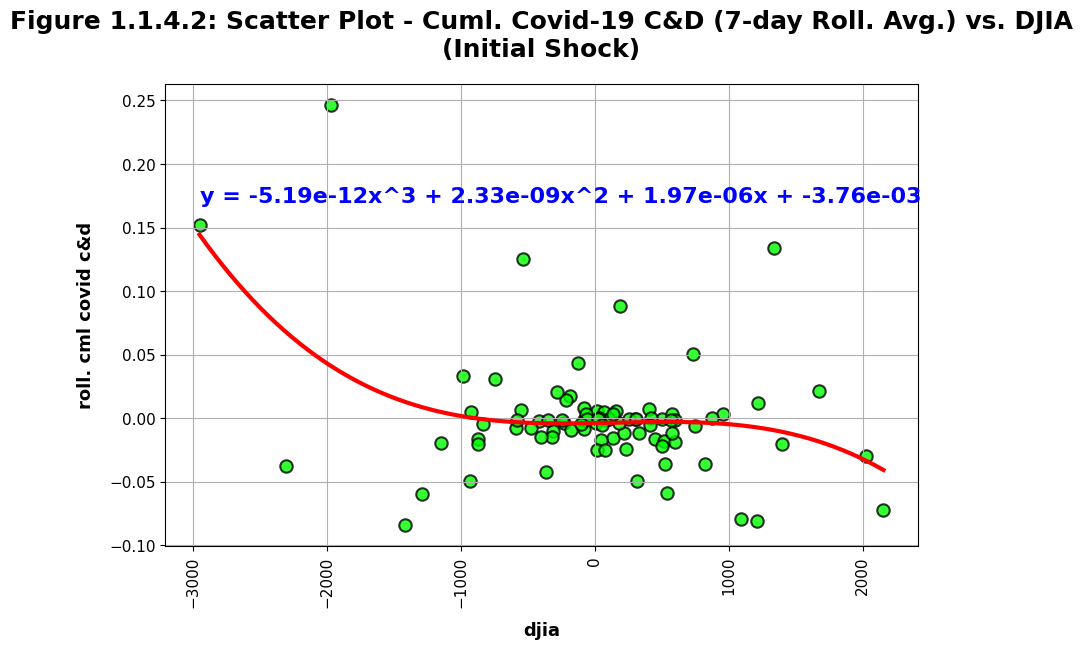

In [50]:
title = 'Figure 1.1.4.2: Scatter Plot ' \
            + f'- {XTTL} vs. {YTTL[Y.Y2.value]}\n{PRD}'

econ_anlys_vrb.set_coords('1.1.4.2', PRD, XCAT, YCOL)


matplotlibx.set_scatterplot_chart_xylabels(YLBL[Y.Y2.value], XLBL)

matplotlibx.set_scatterplot_chart_xylabels_fontsize(13.0, 13.0)

matplotlibx.set_scatterplot_chart_xyticks_fontsize(11.0, 11.0)

matplotlibx.set_scatterplot_chart_title_fontsize(18.0)

matplotlibx.set_regr_degree(best_deg)


matplotlibx.scatterplot_chart([y2_series, x_series], title)

### **The Granger Causality Test: X -> Y2**

In [51]:
title = 'Table 1.1.4.4: The Granger Causality Test ' \
            + f'- {XTTL} -> {YTTL[Y.Y2.value]} {PRD}'


grngr_mth, _, _    = mathx.find_optimal_granger_method(x_series, y2_series)

g_lag, _           = mathx.find_optimal_granger_lag(x_series, y2_series, method = grngr_mth)

test_df, best_dict = mathx.granger_causality_test(x_series, y2_series, maxlag = g_lag, method = grngr_mth)


grngr_bst_list += [best_dict]

grngr_nm_list  += [f'{XCAT} -> {YCAT[Y.Y2.value]}']


pandasx.rtn_fmt_tbl \
    (test_df, title, hide_idx_bool = False, line_cnt_int = len(test_df)) \
        .apply(pandasx.highlight_median_row,    col = 'f_p_value', df = test_df, axis = 1) \
        .apply(pandasx.highlight_high_low_rows, col = 'f_p_value', df = test_df, axis = 1) \
        .format('{:,.6f}', subset = ['f_statistic', 'f_p_value'])

,f_statistic,f_p_value,f_significant,chi2_significant,lrtest_significant,params_f_significant,conclusion
lag,,,,,,,
1,2.847058,0.095296,False,False,False,False,high confidence
2,1.400916,0.252349,False,False,False,False,high confidence
3,1.951109,0.128386,False,False,False,False,high confidence
4,1.891470,0.120882,False,False,False,False,high confidence
5,3.224189,0.011127,True,True,True,True,high confidence


### **The Granger Causality Test: Y2 -> X**

In [52]:
title = 'Table 1.1.4.5: The Granger Causality Test ' \
            + f'- {YTTL[Y.Y2.value]} -> {XTTL} {PRD}'


test_df, best_dict = mathx.granger_causality_test(y2_series, x_series, maxlag = g_lag, method = grngr_mth)


grngr_bst_list += [best_dict]

grngr_nm_list  += [f'{YCAT[Y.Y2.value]} -> {XCAT}']


pandasx.rtn_fmt_tbl \
    (test_df, title, hide_idx_bool = False, line_cnt_int = len(test_df)) \
        .apply(pandasx.highlight_median_row,    col = 'f_p_value', df = test_df, axis = 1) \
        .apply(pandasx.highlight_high_low_rows, col = 'f_p_value', df = test_df, axis = 1) \
        .format('{:,.6f}', subset = ['f_statistic', 'f_p_value'])

,f_statistic,f_p_value,f_significant,chi2_significant,lrtest_significant,params_f_significant,conclusion
lag,,,,,,,
1,0.347934,0.556888,False,False,False,False,high confidence
2,1.949344,0.149071,False,False,False,False,high confidence
3,0.964145,0.414087,False,False,False,False,high confidence
4,1.108911,0.358816,False,False,False,False,high confidence
5,0.953169,0.452435,False,False,False,False,high confidence


### **VAR/VECM Analysis: X vs. Y2**

In [53]:
results_dict = mathx.fit_var_or_vecm(x_series, y2_series)

x_y2_analysis_df = results_dict['summary_df']


title = f'VAR/VECM Analysis: {XTTL} -> {YTTL[Y.Y2.value]} {PRD}'

msg = results_dict['conclusion']


logx.print_and_log_text('\033[1m' + msg + '\033[0m')

logx.write_to_folder(msg, title)

ROLL_CML_COVID_C&D VS. DJIA ANALYSIS

Model selected: VECM.

Series 'x' is non-stationary (ADF = -2.498188, p = 0.115916).

Series 'y' is non-stationary (ADF = -2.485396, p = 0.119068).

Trace and max-eigenvalue tests agree. Both series appear stationary at levels — VAR on levels is appropriate.

Recommended lag (BIC): 5.
AIC = 7, BIC = 5, HQIC = 7, FPE = 7.

VECM(lag = 4, rank = 1) fitted. Adjustment speeds — x: 0.028330, y: -13830.660909. Error correction half-life: inf periods. x - (-0.000080) * y = 0  (long-run equilibrium). Mean reversion: CONFIRMED.

IRF (VECM, 30 periods):
A one-SD shock to x produces a negative net response in y.
Peak x→y effect at lag 5 (magnitude: -6976.337532).
Cumulative x→y response: -77196.668594.

FEVD (VECM, horizon = 31):
x shocks explain 18.389827% of y's forecast variance (moderate influence).
y's own shocks explain 81.610173% of its own variance.



### **Impulse Response Functions (IRF): X vs. Y2**

In [54]:
title = 'Table 1.1.4.6: Impulse Response Functions (IRF) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y2.value]} {PRD}'

try:

    test_df = results_dict['irf_result']['irf_df']

    if len(test_df) > 0:

        display \
            (pandasx.rtn_fmt_tbl \
                (test_df, 
                 title, 
                 hide_idx_bool = False, 
                 line_cnt_int = len(test_df)) \
                    .highlight_min(color = 'mistyrose') \
                    .highlight_max(color = 'greenyellow') \
                    .apply(pandasx.highlight_median_col) \
                    .format('{:,.6f}'))

    else:

        irf_bool = False

        logx.write_to_folder \
            ('\nThere is no Impulse Response Function present with VECM model: ' \
                 + f'{XTTL} vs. {YTTL[Y.Y2.value]} {PRD}\n')

except:

    irf_bool = False

    logx.write_to_folder \
        ('\nThere is no Impulse Response Function present with VECM model: ' \
             + f'{XTTL} vs. {YTTL[Y.Y2.value]} {PRD}\n')

,x_shock_x_response,x_shock_y_response,y_shock_x_response,y_shock_y_response
period,,,,
0,1.000000,0.000000,0.000000,1.000000
1,0.085992,"1,285.130266",0.000006,-0.316336
2,-0.044152,"-1,751.893976",-0.000001,0.377588
3,0.122259,"-4,648.151643",0.000006,-0.094980
4,0.047097,"-1,598.431809",-0.000006,-0.039612
5,0.783044,"-6,976.337532",-0.000000,-0.031977
6,0.092353,"1,207.348936",0.000004,-0.087591
7,-0.029978,"-3,143.169007",-0.000003,0.029414
8,0.175823,"-4,206.632126",0.000005,-0.054619


### **Forecast Error Variance Decomposition (FEVD): X vs. Y2**

In [55]:
if irf_bool:
    
    title = 'Table 1.1.4.7: Forecast Error Variance Decomposition (FEVD) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y2.value]} {PRD}'

else:

    title = 'Table 1.1.4.6: Forecast Error Variance Decomposition (FEVD) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y2.value]} {PRD}'  

test_df = results_dict['fevd_result']['fevd_df']

pandasx.rtn_fmt_tbl \
    (test_df, 
     title, 
     hide_idx_bool = False, 
     line_cnt_int = len(test_df)) \
        .highlight_min(color = 'mistyrose') \
        .highlight_max(color = 'greenyellow') \
        .apply(pandasx.highlight_median_col) \
        .format('{:,.6f}') 

,y_variance_from_x,y_variance_from_y,x_variance_from_x,x_variance_from_y
period,,,,
0,0.011060,0.988940,1.000000,0.000000
1,0.018188,0.981812,0.979438,0.020562
2,0.027196,0.972804,0.978918,0.021082
3,0.053560,0.946440,0.956517,0.043483
4,0.054805,0.945195,0.944240,0.055760
5,0.107047,0.892953,0.961347,0.038653
6,0.114926,0.885074,0.956213,0.043787
7,0.120601,0.879399,0.955060,0.044940
8,0.129747,0.870253,0.948017,0.051983


### **Rolling R, Stability, and CV Score for Rolling Window: X vs. Y2**

In [56]:
best_w, _, results_df \
    = mathx.find_optimal_rolling_window \
        (x_series, y2_series, method = corr_method)

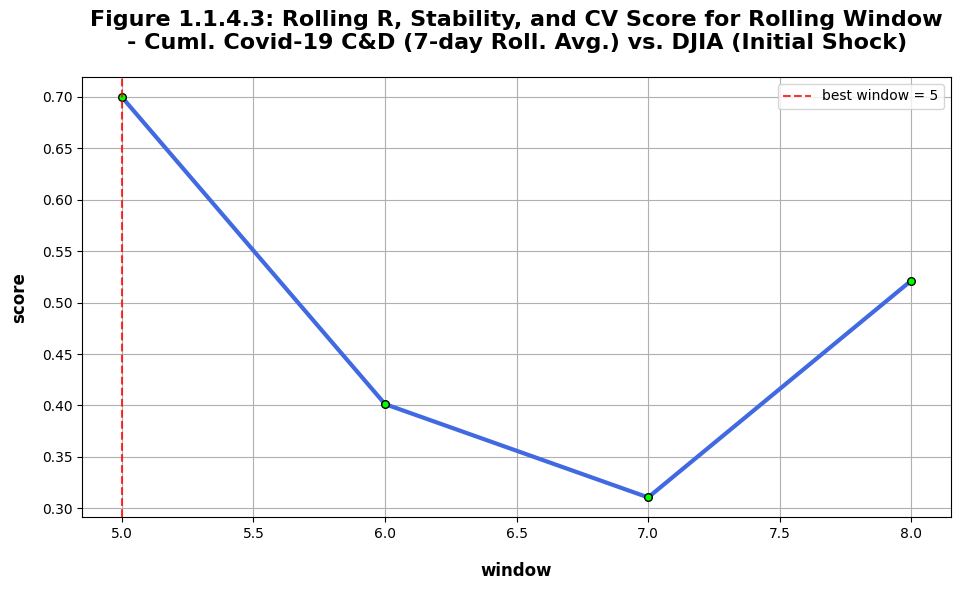

In [57]:
title = 'Figure 1.1.4.3: Rolling R, Stability, and CV Score for Rolling Window\n' \
            + f'- {XTTL} vs. {YTTL[Y.Y2.value]} {PRD}'


matplotlibx.set_corr_scores_xylabels('window', 'score')

matplotlibx.set_corr_scores_marker_size(5.5)


matplotlibx.plot_corr_scores(results_df.loc[:,'score'].to_dict(), title)

### **Rolling R, Stability, and CV Score for Minimum Period: X vs. Y2**

In [58]:
best_mp, _, results_df \
    = mathx.find_optimal_min_periods \
        (x_series, y2_series, best_w, method = corr_method)

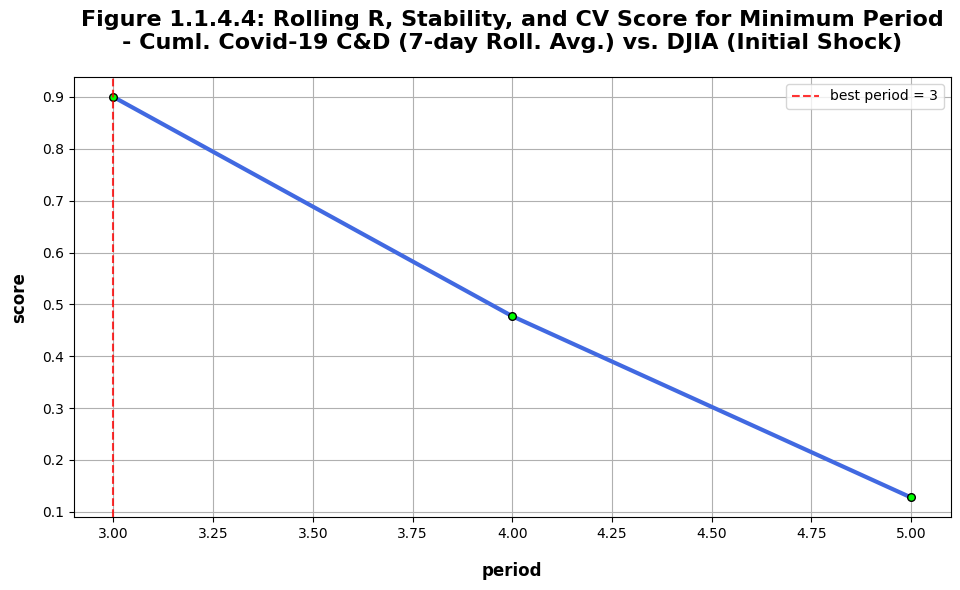

In [59]:
title = 'Figure 1.1.4.4: Rolling R, Stability, and CV Score for Minimum Period\n' \
            + f'- {XTTL} vs. {YTTL[Y.Y2.value]} {PRD}'


matplotlibx.set_corr_scores_xylabels('period', 'score')

matplotlibx.set_corr_scores_marker_size(5.5)


matplotlibx.plot_corr_scores(results_df.loc[:,'score'].to_dict(), title)

### **Rolling Correlation: X vs. Y2**

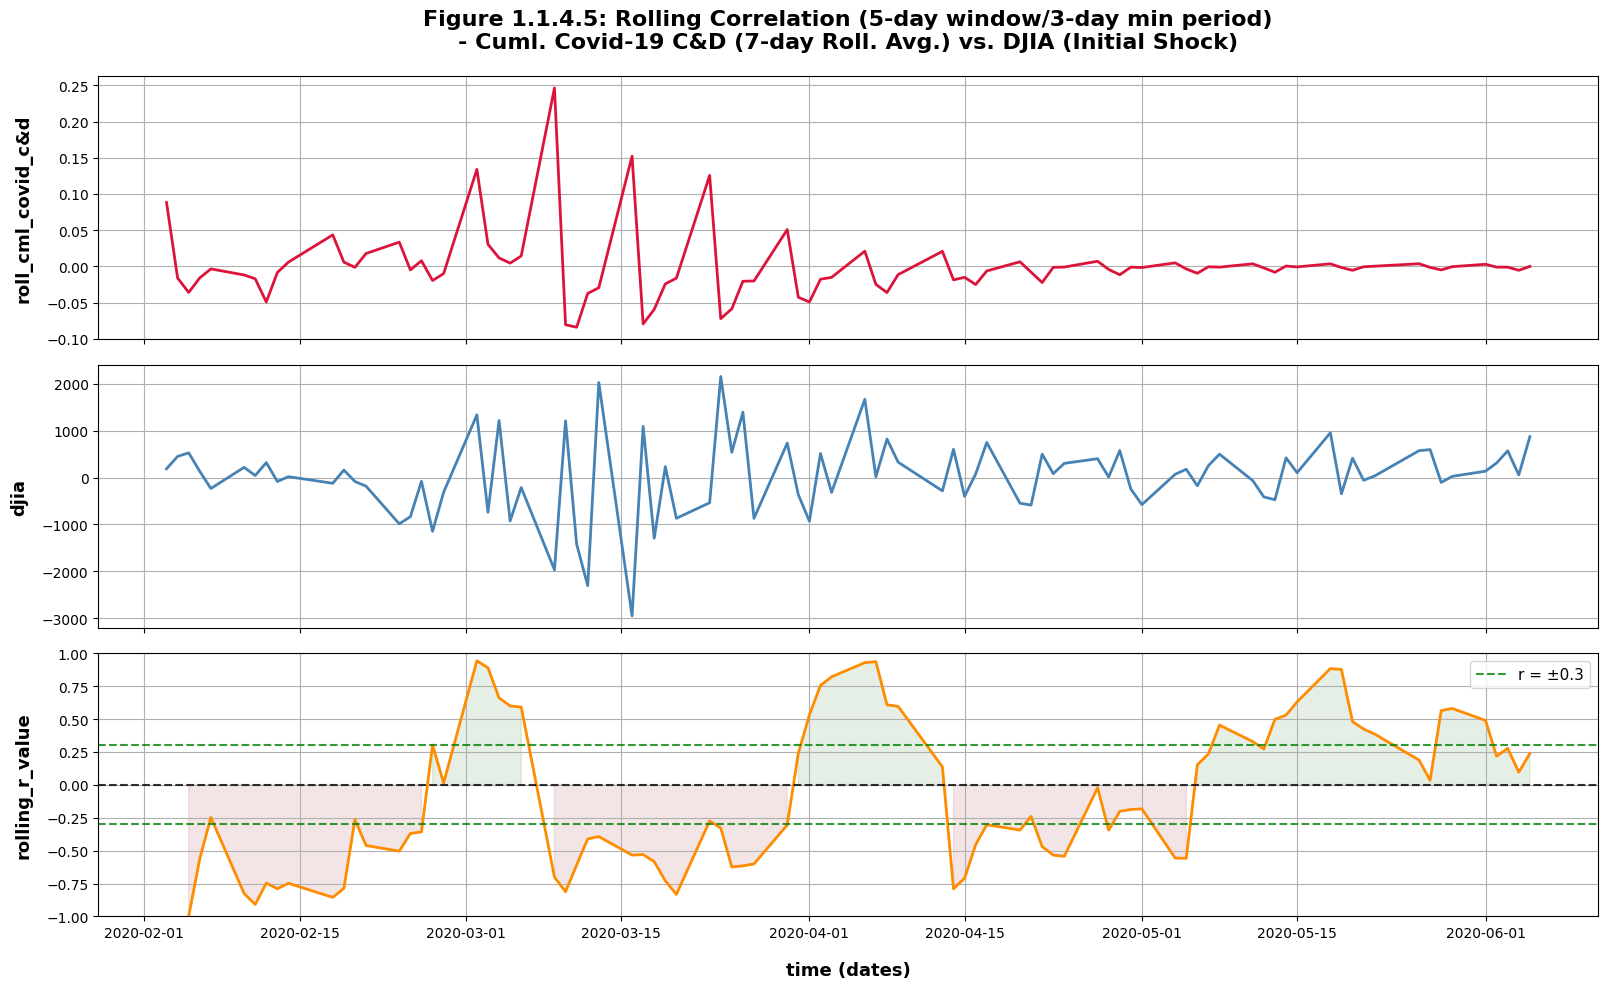

In [60]:
title \
    = f'Figure 1.1.4.5: Rolling Correlation ({best_w}-day window/{best_mp}' \
        + f'-day min period)\n- {XTTL} vs. {YTTL[Y.Y2.value]} {PRD}'

matplotlibx.set_roll_corr_w_mp(best_w, best_mp)

matplotlibx.plot_rolling_corr_lines(x_series, y2_series, title)

### **Lag Correlation: X vs. Y2**

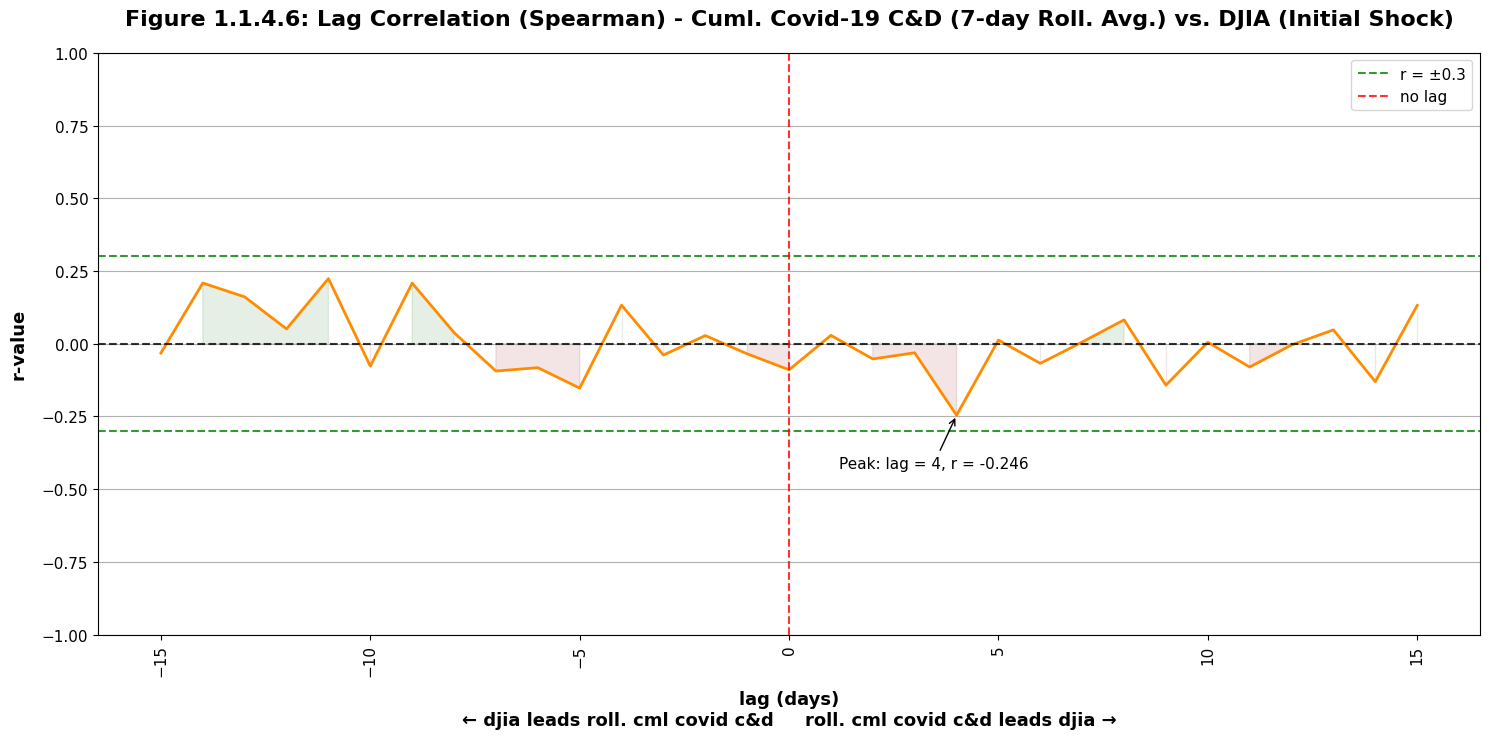

In [61]:
title = f'Figure 1.1.4.6: Lag Correlation ({corr_method.title()}) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y2.value]} {PRD}'

econ_anlys_vrb.set_coords('1.1.4.6', PRD, XCAT, YCOL)


v_lag       = int(x_y2_analysis_df.loc[0, 'lag'])

max_lag     = mathx.find_optimal_lag_corr_maxlag(x_series, y2_series, v_lag, g_lag)

if max_lag > max_max_lag: max_max_lag = max_lag


matplotlibx.set_lag_corr_xylabels(XLBL, YLBL[Y.Y2.value])

matplotlibx.plot_lag_corr_line_chart(x_series, y2_series, title, max_lag = max_lag)

---

## Interpretation: Section 1.1.4 — `covid_c&d` (7-Day Rolling Avg) vs. Y2 (Stock Market Index 2)

**Correlation and Functional Form.** The polynomial degree selection and correlation results for Y2 provide the first point of comparison with Y1. If the optimal polynomial degree differs between Y1 and Y2, it suggests the two indices responded to COVID data through different functional mechanisms — one following a more proportional relationship, the other showing threshold or accelerating effects. A materially different correlation coefficient between Y1 and Y2 would indicate that one market segment was more directly sensitive to pandemic case data than the other during the crash period.

**Granger Causality.** The Granger causality tests in Tables 1.1.4.4 and 1.1.4.5 should be read in conjunction with the Y1 results. If X→Y2 is significant while X→Y1 is not (or vice versa), this reveals heterogeneity in which market segments COVID data most efficiently predicted. It is also possible that both directions (X→Y2 and Y2→X) are significant for some indices — an artifact of the short, highly correlated window — which would warrant caution in interpreting the directionality finding.

**VAR/VECM Dynamics.** The IRF and FEVD for Y2 are directly comparable to Y1. A higher FEVD X-share for Y2 than Y1 would indicate that this index's variance was more attributable to COVID dynamics, consistent with greater exposure of Y2's underlying assets to pandemic-driven disruption. The IRF peak magnitude and decay speed reveal whether the market's response to a COVID shock was acute and short-lived or gradual and persistent.

**Rolling and Lag Correlations.** The optimal rolling window and minimum period selected for Y2 may differ from Y1, reflecting differences in each index's signal-to-noise ratio over the Initial Shock window. The lag correlation profile for Y2 — specifically the peak lag relative to Y1 — provides insight into whether different market segments incorporated pandemic information at different speeds, which would be consistent with differences in market depth, liquidity, or investor composition across segments.

---


## **1.1.5: X vs. Y3**

### **Create DataFrame X vs. Y3**

In [62]:
comp_df \
    = pd.DataFrame \
        ({XCAT:             x_series,
          YCAT[Y.Y3.value]: y3_series})

logx.log_write_obj(comp_df)

In [63]:
title = f'Table 1.1.5.1: {XTTL} vs. {YTTL[Y.Y3.value]} {PRD}'

pandasx.rtn_fmt_tbl \
    (comp_df, title, hide_idx_bool = False) \
        .format({XCAT:             pandasx.fmt_dict['flt_int'],
                 YCAT[Y.Y3.value]: pandasx.fmt_dict['flt_int']})

,roll_cml_covid_c&d,nasdaq
series,,
2020-02-03,0,-38
2020-02-04,-0,87
2020-02-05,-0,52
2020-02-06,-0,41
2020-02-07,-0,-79
2020-02-10,-0,-29
2020-02-11,-0,-61
2020-02-12,-0,-1
2020-02-13,-0,-22


### **AIC, Cross-validated R², and Overfitting Score for Polynomial Degree: X vs. Y3**

In [64]:
title = 'Table 1.1.5.2: AIC, Cross-validated R², and Overfitting Score for Polynomial Degree ' \
            + f'- {XTTL} vs. {YTTL[Y.Y3.value]} {PRD}'


best_deg, scores_dict, _, results_df = mathx.opt_poly_degree(y3_series, x_series)

corr_method = mathx.find_opt_corr_method(y3_series, x_series)


pandasx.rtn_fmt_tbl(results_df, title) \
    .map(pandasx.highlight_bool_col, subset = ['overfit']) \
    .apply(pandasx.highlight_val_row, col = 'degree', val = best_deg, axis = 1)

degree,train_r2,cv_r2,cv_r2_std,cv_norm,aic,aic_norm,overfit,combined_score
1,0.02,-0.63,0.57,1.00,-531.52,0.70,True,0.85
2,0.03,-0.84,0.88,1.00,-531.01,0.65,True,0.82
3,0.06,-0.74,0.98,1.00,-531.50,0.70,True,0.85
4,0.11,-0.37,0.18,1.00,-534.37,1.00,True,1.00
5,0.13,-0.74,0.97,1.00,-534.11,0.97,True,0.99
6,0.13,-0.86,1.42,1.00,-532.29,0.78,True,0.89
7,0.13,-2.44,4.55,1.00,-530.39,0.58,True,0.79
8,0.13,-21.64,42.84,0.96,-528.44,0.38,True,0.67
9,0.14,-102.18,204.08,0.80,-526.69,0.20,True,0.50
10,0.14,-519.67,"1,038.77",0.00,-524.81,0.00,True,0.00


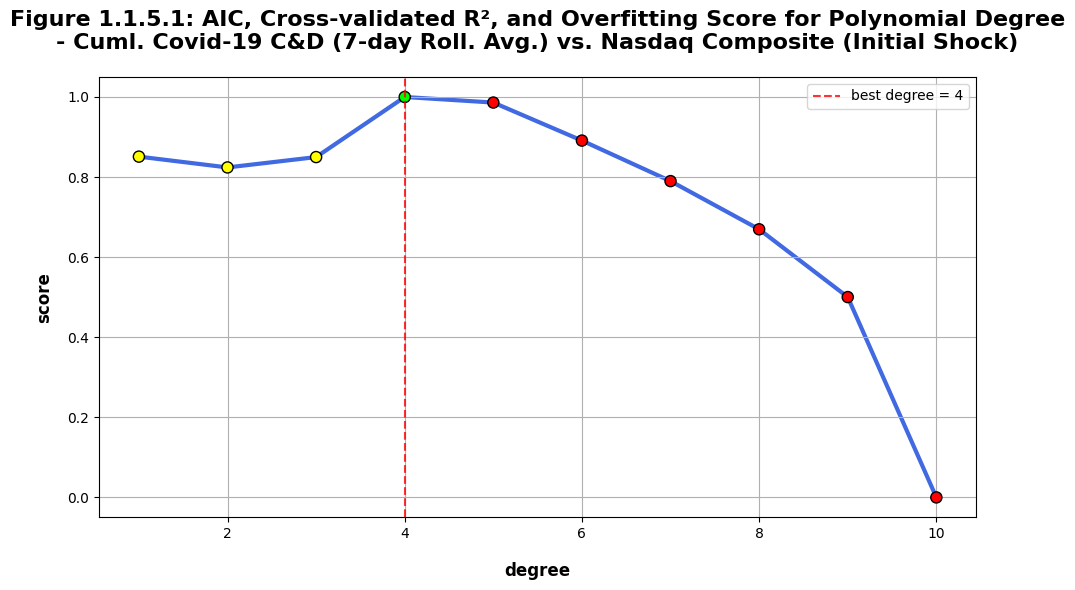

In [65]:
title = 'Figure 1.1.5.1: AIC, Cross-validated R², and Overfitting Score for Polynomial Degree\n' \
            + f'- {XTTL} vs. {YTTL[Y.Y3.value]} {PRD}'


matplotlibx.set_corr_scores_xylabels('degree', 'score')

matplotlibx.set_corr_scores_marker_size(8.0)

matplotlibx.set_lag_corr_method(corr_method)


matplotlibx.plot_corr_scores(scores_dict, title, best_deg)

### **Correlation: X vs. Y3**

In [66]:
title = f'Table 1.1.5.3: Correlation ({corr_method.title()}) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y3.value]} {PRD}'

pandasx.rtn_fmt_tbl(comp_df.corr(method = corr_method), title, hide_idx_bool = False)

,roll_cml_covid_c&d,nasdaq
roll_cml_covid_c&d,1.00,0.04
nasdaq,0.04,1.00


### **Scatter Plot: X vs. Y3**

r-value (pearson):	-0.135
r-value (spearman):	0.039
tau (kendall):		0.036

p-value (pearson):	0.213
p-value (spearman):	0.717
p-value (kendall):	0.621




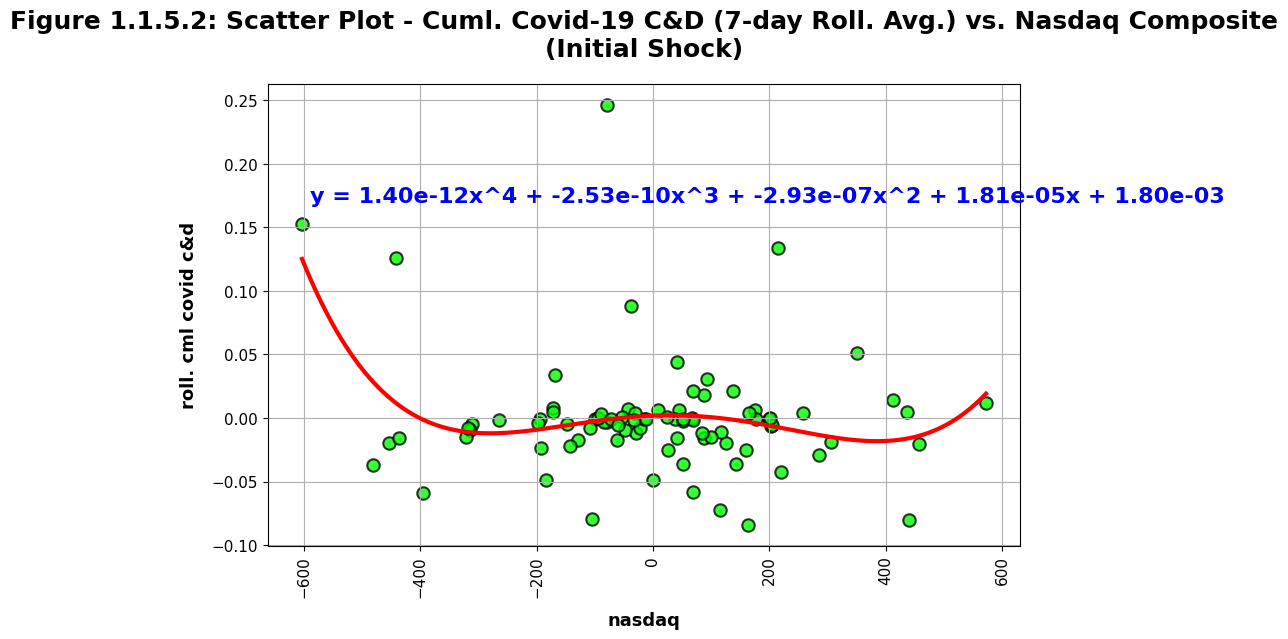

In [67]:
title = 'Figure 1.1.5.2: Scatter Plot ' \
            + f'- {XTTL} vs. {YTTL[Y.Y3.value]}\n{PRD}'

econ_anlys_vrb.set_coords('1.1.5.2', PRD, XCAT, YCOL)


matplotlibx.set_scatterplot_chart_xylabels(YLBL[Y.Y3.value], XLBL)

matplotlibx.set_scatterplot_chart_xylabels_fontsize(13.0, 13.0)

matplotlibx.set_scatterplot_chart_xyticks_fontsize(11.0, 11.0)

matplotlibx.set_scatterplot_chart_title_fontsize(18.0)

matplotlibx.set_regr_degree(best_deg)


matplotlibx.scatterplot_chart([y3_series, x_series], title)

### **The Granger Causality Test: X -> Y3**

In [68]:
title = 'Table 1.1.5.4: The Granger Causality Test ' \
            + f'- {XTTL} -> {YTTL[Y.Y3.value]} {PRD}'


grngr_mth, _, _    = mathx.find_optimal_granger_method(x_series, y3_series)

g_lag, _           = mathx.find_optimal_granger_lag(x_series, y3_series, method = grngr_mth)

test_df, best_dict = mathx.granger_causality_test(x_series, y3_series, maxlag = g_lag, method = grngr_mth)


grngr_bst_list += [best_dict]

grngr_nm_list  += [f'{XCAT} -> {YCAT[Y.Y3.value]}']


pandasx.rtn_fmt_tbl \
    (test_df, title, hide_idx_bool = False, line_cnt_int = len(test_df)) \
        .apply(pandasx.highlight_median_row,    col = 'f_p_value', df = test_df, axis = 1) \
        .apply(pandasx.highlight_high_low_rows, col = 'f_p_value', df = test_df, axis = 1) \
        .format('{:,.6f}', subset = ['f_statistic', 'f_p_value'])

,f_statistic,f_p_value,f_significant,chi2_significant,lrtest_significant,params_f_significant,conclusion
lag,,,,,,,
1,9.313754,0.003054,True,True,True,True,high confidence


### **The Granger Causality Test: Y3 -> X**

In [69]:
title = 'Table 1.1.5.5: The Granger Causality Test ' \
            + f'- {YTTL[Y.Y3.value]} -> {XTTL} {PRD}'


test_df, best_dict = mathx.granger_causality_test(y3_series, x_series, maxlag = g_lag, method = grngr_mth)


grngr_bst_list += [best_dict]

grngr_nm_list  += [f'{YCAT[Y.Y3.value]} -> {XCAT}']


pandasx.rtn_fmt_tbl \
    (test_df, title, hide_idx_bool = False, line_cnt_int = len(test_df)) \
        .apply(pandasx.highlight_median_row,    col = 'f_p_value', df = test_df, axis = 1) \
        .apply(pandasx.highlight_high_low_rows, col = 'f_p_value', df = test_df, axis = 1) \
        .format('{:,.6f}', subset = ['f_statistic', 'f_p_value'])

,f_statistic,f_p_value,f_significant,chi2_significant,lrtest_significant,params_f_significant,conclusion
lag,,,,,,,
1,1.247777,0.267201,False,False,False,False,high confidence
2,2.067029,0.133268,False,False,False,False,high confidence
3,1.469923,0.229332,False,False,False,False,high confidence
4,1.221716,0.308936,False,False,False,False,high confidence
5,2.317712,0.052246,False,True,True,False,non-normal residuals or insufficient sample size


### **VAR/VECM Analysis: X vs. Y3**

In [70]:
results_dict = mathx.fit_var_or_vecm(x_series, y3_series)

x_y3_analysis_df = results_dict['summary_df']


title = f'VAR/VECM Analysis: {XTTL} -> {YTTL[Y.Y3.value]} {PRD}'

msg = results_dict['conclusion']


logx.print_and_log_text('\033[1m' + msg + '\033[0m')

logx.write_to_folder(msg, title)

ROLL_CML_COVID_C&D VS. NASDAQ ANALYSIS

Model selected: VECM.

Series 'x' is non-stationary (ADF = -2.498188, p = 0.115916).

Series 'y' is stationary (ADF = -4.242517, p = 0.000558).

Trace and max-eigenvalue tests agree. One cointegrating relationship detected — VECM is appropriate.

Recommended lag (BIC): 5.
AIC = 10, BIC = 5, HQIC = 5, FPE = 10.

VECM(lag = 4, rank = 1) fitted. Adjustment speeds — x: 0.021206, y: 469.182153. Error correction half-life: inf periods. x - (0.001753) * y = 0  (long-run equilibrium). Mean reversion: NOT CONFIRMED — check alpha signs.

IRF (VECM, 30 periods):
A one-SD shock to x produces a positive net response in y.
Peak x→y effect at lag 1 (magnitude: 993.261784).
Cumulative x→y response: 4799.391739.

FEVD (VECM, horizon = 31):
x shocks explain 7.634800% of y's forecast variance (moderate influence).
y's own shocks explain 92.365200% of its own variance.



### **Impulse Response Functions (IRF): X vs. Y3**

In [71]:
title = 'Table 1.1.5.6: Impulse Response Functions (IRF) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y3.value]} {PRD}'

try:

    test_df = results_dict['irf_result']['irf_df']

    if len(test_df) > 0:

        display \
            (pandasx.rtn_fmt_tbl \
                (test_df, 
                 title, 
                 hide_idx_bool = False, 
                 line_cnt_int = len(test_df)) \
                    .highlight_min(color = 'mistyrose') \
                    .highlight_max(color = 'greenyellow') \
                    .apply(pandasx.highlight_median_col) \
                    .format('{:,.6f}'))

    else:

        irf_bool = False

        logx.write_to_folder \
            ('\nThere is no Impulse Response Function present with VECM model: ' \
                 + f'{XTTL} vs. {YTTL[Y.Y3.value]} {PRD}\n')
    
except:

    irf_bool = False

    logx.write_to_folder \
        ('\nThere is no Impulse Response Function present with VECM model: ' \
             + f'{XTTL} vs. {YTTL[Y.Y3.value]} {PRD}\n')

,x_shock_x_response,x_shock_y_response,y_shock_x_response,y_shock_y_response
period,,,,
0,1.000000,0.000000,0.000000,1.000000
1,0.069340,993.261784,0.000021,0.195153
2,-0.028510,903.294091,-0.000008,0.485728
3,0.134859,243.169892,0.000015,0.179082
4,0.066749,531.962977,-0.000043,-0.024202
5,0.793160,-703.208928,-0.000019,-0.184742
6,0.056554,399.886258,-0.000006,-0.280034
7,-0.042492,119.079090,-0.000027,-0.259871
8,0.179274,-396.998092,0.000003,-0.230142


### **Forecast Error Variance Decomposition (FEVD): X vs. Y3**

In [72]:
if irf_bool:
    
    title = 'Table 1.1.5.7: Forecast Error Variance Decomposition (FEVD) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y3.value]} {PRD}'

else:

    title = 'Table 1.1.5.6: Forecast Error Variance Decomposition (FEVD) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y3.value]} {PRD}'  

test_df = results_dict['fevd_result']['fevd_df']

pandasx.rtn_fmt_tbl \
    (test_df, 
     title, 
     hide_idx_bool = False, 
     line_cnt_int = len(test_df)) \
        .highlight_min(color = 'mistyrose') \
        .highlight_max(color = 'greenyellow') \
        .apply(pandasx.highlight_median_col) \
        .format('{:,.6f}')

,y_variance_from_x,y_variance_from_y,x_variance_from_x,x_variance_from_y
period,,,,
0,0.011035,0.988965,1.000000,0.000000
1,0.040304,0.959696,0.980097,0.019903
2,0.044445,0.955555,0.979576,0.020424
3,0.045123,0.954877,0.967109,0.032891
4,0.054742,0.945258,0.915645,0.084355
5,0.057790,0.942210,0.935504,0.064496
6,0.062178,0.937822,0.935854,0.064146
7,0.060744,0.939256,0.928264,0.071736
8,0.060461,0.939539,0.926458,0.073542


### **Rolling R, Stability, and CV Score for Rolling Window: X vs. Y3**

In [73]:
best_w, _, results_df \
    = mathx.find_optimal_rolling_window \
        (x_series, y3_series, method = corr_method)

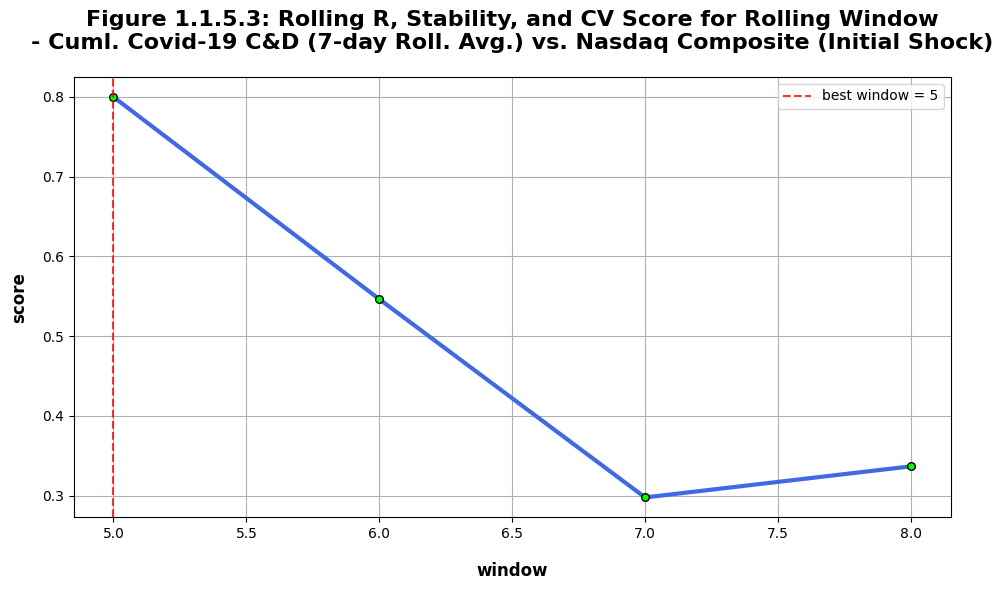

In [74]:
title = 'Figure 1.1.5.3: Rolling R, Stability, and CV Score for Rolling Window\n' \
            + f'- {XTTL} vs. {YTTL[Y.Y3.value]} {PRD}'


matplotlibx.set_corr_scores_xylabels('window', 'score')

matplotlibx.set_corr_scores_marker_size(5.5)


matplotlibx.plot_corr_scores(results_df.loc[:,'score'].to_dict(), title)

### **Rolling R, Stability, and CV Score for Minimum Period: X vs. Y3**

In [75]:
best_mp, _, results_df \
    = mathx.find_optimal_min_periods \
        (x_series, y3_series, best_w, method = corr_method)

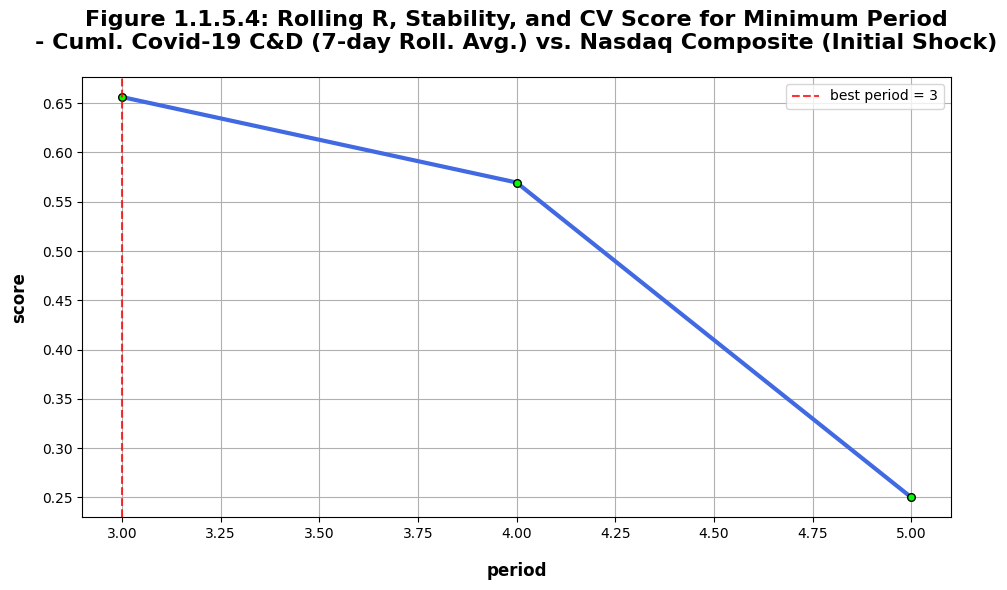

In [76]:
title = 'Figure 1.1.5.4: Rolling R, Stability, and CV Score for Minimum Period\n' \
            + f'- {XTTL} vs. {YTTL[Y.Y3.value]} {PRD}'


matplotlibx.set_corr_scores_xylabels('period', 'score')

matplotlibx.set_corr_scores_marker_size(5.5)


matplotlibx.plot_corr_scores(results_df.loc[:,'score'].to_dict(), title)

### **Rolling Correlation: X vs. Y3**

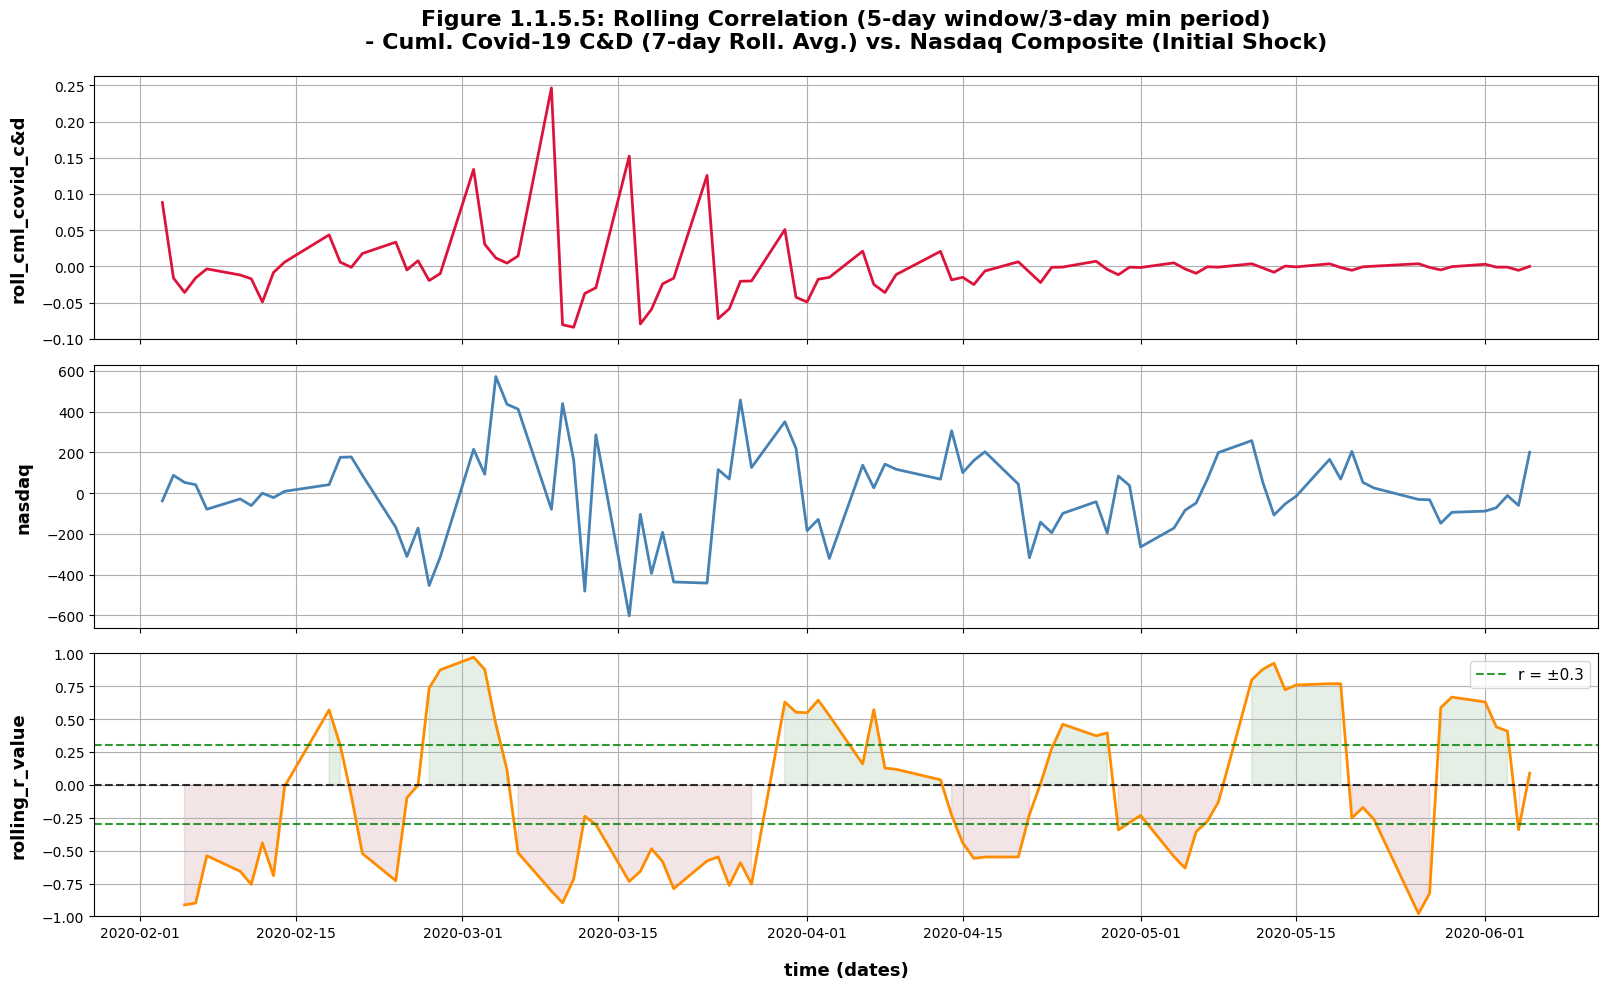

In [77]:
title \
    = f'Figure 1.1.5.5: Rolling Correlation ({best_w}-day window/{best_mp}' \
        + f'-day min period)\n- {XTTL} vs. {YTTL[Y.Y3.value]} {PRD}'

matplotlibx.set_roll_corr_w_mp(best_w, best_mp)

matplotlibx.plot_rolling_corr_lines(x_series, y3_series, title)

### **Lag Correlation: X vs. Y3**

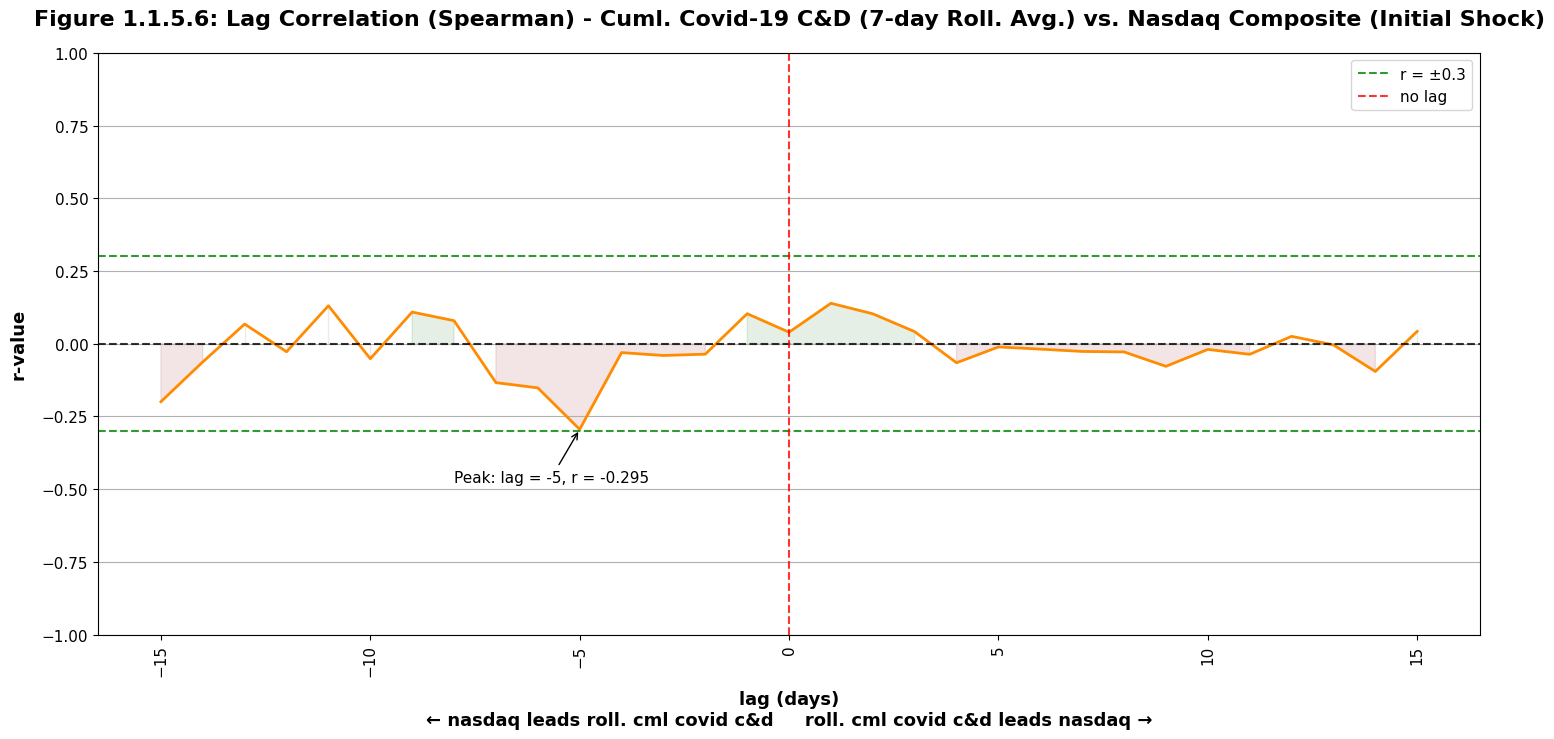

In [78]:
title = f'Figure 1.1.5.6: Lag Correlation ({corr_method.title()}) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y3.value]} {PRD}'

econ_anlys_vrb.set_coords('1.1.5.6', PRD, XCAT, YCOL)


v_lag       = int(x_y3_analysis_df.loc[0, 'lag'])

max_lag     = mathx.find_optimal_lag_corr_maxlag(x_series, y3_series, v_lag, g_lag)

if max_lag > max_max_lag: max_max_lag = max_lag


matplotlibx.set_lag_corr_xylabels(XLBL, YLBL[Y.Y3.value])

matplotlibx.plot_lag_corr_line_chart(x_series, y3_series, title, max_lag = max_lag)

---

## Interpretation: Section 1.1.5 — `covid_c&d` (7-Day Rolling Avg) vs. Y3 (Stock Market Index 3)

**Correlation and Functional Form.** By the third index, the cross-index pattern of polynomial degrees and correlation coefficients should be becoming clear. If Y3's best-fit degree and correlation magnitude are consistent with Y1 and Y2, it supports a common mechanism by which COVID data influenced equity markets broadly during the crash. Divergence — particularly a substantially weaker or non-significant correlation for Y3 — would suggest that this index's composition insulates it from the direct COVID-to-equity transmission channel, perhaps through sector exposure (e.g., healthcare, utilities, or defensive assets that held value during the crash).

**Granger Causality.** The relative strength of Granger causality for Y3 versus prior indices can be assessed through the F-statistic and p-value in Tables 1.1.5.4 and 1.1.5.5. If the F-statistic for X→Y3 is notably lower than for X→Y1 or X→Y2, it indicates that COVID's predictive information about Y3 is weaker once the index's own history is controlled for. This is a meaningful finding: it suggests that Y3 had stronger autoregressive dynamics (i.e., its own momentum dominated) relative to exogenous COVID influence during the Initial Shock.

**VAR/VECM Dynamics.** The FEVD X-share for Y3 in Table 1.1.5.7 directly measures COVID's contribution to Y3's forecast error variance. A lower X-share relative to Y1 and Y2 would be consistent with the weaker Granger causality finding — both tests converge on COVID being less influential for this index. Conversely, a high X-share with weak Granger causality could occur if the VECM captures a cointegrating relationship that the Granger test misses.

**Rolling and Lag Correlations.** The lag correlation for Y3 (Figure 1.1.5.6) is particularly informative if it shows a peak lag materially different from Y1 and Y2. A longer lag for Y3 would suggest that this market segment incorporated COVID information more slowly — possibly because its underlying assets react to second-order effects of the pandemic (e.g., credit conditions or economic activity indicators) rather than to case counts directly.

---


## **1.1.6: X vs. Y4**

### **Create DataFrame X vs. Y4**

In [79]:
comp_df \
    = pd.DataFrame \
        ({XCAT:             x_series,
          YCAT[Y.Y4.value]: y4_series})

logx.log_write_obj(comp_df)

In [80]:
title = f'Table 1.1.6.1: {XTTL} vs. {YTTL[Y.Y4.value]} {PRD}'

pandasx.rtn_fmt_tbl \
    (comp_df, title, hide_idx_bool = False) \
        .format({XCAT:             pandasx.fmt_dict['flt_int'],
                 YCAT[Y.Y4.value]: pandasx.fmt_dict['flt_int']})

,roll_cml_covid_c&d,nyse
series,,
2020-02-03,0,91
2020-02-04,-0,212
2020-02-05,-0,189
2020-02-06,-0,37
2020-02-07,-0,-76
2020-02-10,-0,79
2020-02-11,-0,96
2020-02-12,-0,110
2020-02-13,-0,-11


### **AIC, Cross-validated R², and Overfitting Score for Polynomial Degree: X vs. Y4**

In [81]:
title = 'Table 1.1.6.2: AIC, Cross-validated R², and Overfitting Score for Polynomial Degree ' \
            + f'- {XTTL} vs. {YTTL[Y.Y4.value]} {PRD}'


best_deg, scores_dict, _, results_df = mathx.opt_poly_degree(y4_series, x_series)

corr_method = mathx.find_opt_corr_method(y4_series, x_series)


pandasx.rtn_fmt_tbl(results_df, title) \
    .map(pandasx.highlight_bool_col, subset = ['overfit']) \
    .apply(pandasx.highlight_val_row, col = 'degree', val = best_deg, axis = 1)

degree,train_r2,cv_r2,cv_r2_std,cv_norm,aic,aic_norm,overfit,combined_score
1,0.11,-2.92,4.86,1.00,-540.04,0.35,True,0.67
2,0.15,-2.61,4.41,1.00,-542.10,0.51,True,0.76
3,0.23,-0.94,1.12,1.00,-548.22,1.00,True,1.00
4,0.23,-0.55,0.67,1.00,-546.47,0.86,True,0.93
5,0.23,-7.64,14.13,1.00,-544.50,0.70,True,0.85
6,0.25,-1.94,2.95,1.00,-545.07,0.75,True,0.87
7,0.24,-33.60,66.91,1.00,-542.38,0.53,True,0.77
8,0.24,-600.22,"1,199.74",0.96,-540.21,0.36,True,0.66
9,0.24,-556.86,"1,112.78",0.96,-537.65,0.16,True,0.56
10,0.24,"-14,235.88","28,470.97",0.00,-535.70,0.00,True,0.00


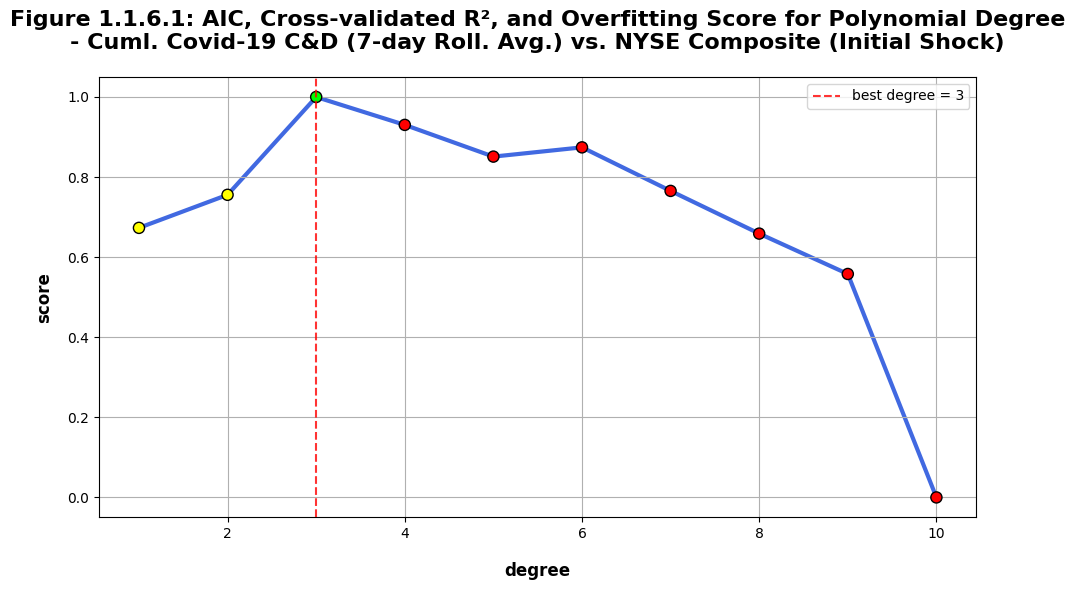

In [82]:
title = 'Figure 1.1.6.1: AIC, Cross-validated R², and Overfitting Score for Polynomial Degree\n' \
            + f'- {XTTL} vs. {YTTL[Y.Y4.value]} {PRD}'


matplotlibx.set_corr_scores_xylabels('degree', 'score')

matplotlibx.set_corr_scores_marker_size(8.0)

matplotlibx.set_lag_corr_method(corr_method)


matplotlibx.plot_corr_scores(scores_dict, title, best_deg)

### **Correlation: X vs. Y4**

In [83]:
title = f'Table 1.1.6.3: Correlation ({corr_method.title()}) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y4.value]} {PRD}'

pandasx.rtn_fmt_tbl (comp_df.corr(method = corr_method), title, hide_idx_bool = False)

,roll_cml_covid_c&d,nyse
roll_cml_covid_c&d,1.00,-0.10
nyse,-0.10,1.00


### **Scatter Plot: X vs. Y4**

r-value (pearson):	-0.331
r-value (spearman):	-0.102
tau (kendall):		-0.072

p-value (pearson):	0.002
p-value (spearman):	0.347
p-value (kendall):	0.324




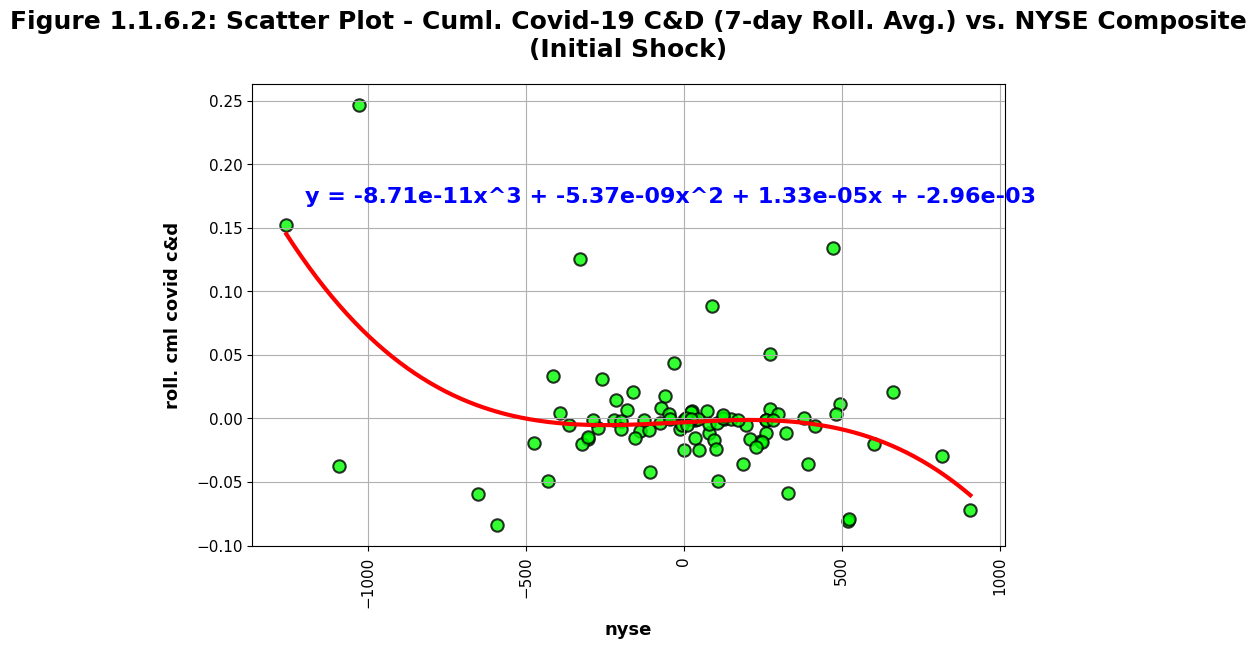

In [84]:
title = 'Figure 1.1.6.2: Scatter Plot ' \
            + f'- {XTTL} vs. {YTTL[Y.Y4.value]}\n{PRD}'

econ_anlys_vrb.set_coords('1.1.6.2', PRD, XCAT, YCOL)
            

matplotlibx.set_scatterplot_chart_xylabels(YLBL[Y.Y4.value], XLBL)

matplotlibx.set_scatterplot_chart_xylabels_fontsize(13.0, 13.0)

matplotlibx.set_scatterplot_chart_xyticks_fontsize(11.0, 11.0)

matplotlibx.set_scatterplot_chart_title_fontsize(18.0)

matplotlibx.set_regr_degree(best_deg)


matplotlibx.scatterplot_chart([y4_series, x_series], title)

### **The Granger Causality Test: X -> Y4**

In [85]:
title = 'Table 1.1.6.4: The Granger Causality Test ' \
            + f'- {XTTL} -> {YTTL[Y.Y4.value]} {PRD}'


grngr_mth, _, _    = mathx.find_optimal_granger_method(x_series, y4_series)

g_lag, _           = mathx.find_optimal_granger_lag(x_series, y4_series, method = grngr_mth)

test_df, best_dict = mathx.granger_causality_test(x_series, y4_series, maxlag = g_lag, method = grngr_mth)


grngr_bst_list += [best_dict]

grngr_nm_list  += [f'{XCAT} -> {YCAT[Y.Y4.value]}']


pandasx.rtn_fmt_tbl \
    (test_df, title, hide_idx_bool = False, line_cnt_int = len(test_df)) \
        .apply(pandasx.highlight_median_row,    col = 'f_p_value', df = test_df, axis = 1) \
        .apply(pandasx.highlight_high_low_rows, col = 'f_p_value', df = test_df, axis = 1) \
        .format('{:,.6f}', subset = ['f_statistic', 'f_p_value'])

,f_statistic,f_p_value,f_significant,chi2_significant,lrtest_significant,params_f_significant,conclusion
lag,,,,,,,
1,3.294045,0.073144,False,False,False,False,high confidence
2,1.649042,0.198700,False,False,False,False,high confidence
3,2.129315,0.103348,False,False,False,False,high confidence
4,2.074100,0.092757,False,False,False,False,high confidence
5,3.633599,0.005531,True,True,True,True,high confidence


### **The Granger Causality Test: Y4 -> X**

In [86]:
title = 'Table 1.1.6.5: The Granger Causality Test ' \
            + f'- {YTTL[Y.Y4.value]} -> {XTTL} {PRD}'


test_df, best_dict = mathx.granger_causality_test(y4_series, x_series, maxlag = g_lag, method = grngr_mth)


grngr_bst_list += [best_dict]

grngr_nm_list  += [f'{YCAT[Y.Y4.value]} -> {XCAT}']


pandasx.rtn_fmt_tbl \
    (test_df, title, hide_idx_bool = False, line_cnt_int = len(test_df)) \
        .apply(pandasx.highlight_median_row,    col = 'f_p_value', df = test_df, axis = 1) \
        .apply(pandasx.highlight_high_low_rows, col = 'f_p_value', df = test_df, axis = 1) \
        .format('{:,.6f}', subset = ['f_statistic', 'f_p_value'])

,f_statistic,f_p_value,f_significant,chi2_significant,lrtest_significant,params_f_significant,conclusion
lag,,,,,,,
1,0.246838,0.620624,False,False,False,False,high confidence
2,1.910430,0.154709,False,False,False,False,high confidence
3,0.889117,0.450680,False,False,False,False,high confidence
4,1.234929,0.303502,False,False,False,False,high confidence
5,0.942060,0.459326,False,False,False,False,high confidence


### **VAR/VECM Analysis: X vs. Y4**

In [87]:
results_dict = mathx.fit_var_or_vecm(x_series, y4_series)

x_y4_analysis_df = results_dict['summary_df']


title = f'VAR/VECM Analysis: {XTTL} -> {YTTL[Y.Y4.value]} {PRD}'

msg = results_dict['conclusion']


logx.print_and_log_text('\033[1m' + msg + '\033[0m')

logx.write_to_folder(msg, title)

ROLL_CML_COVID_C&D VS. NYSE ANALYSIS

Model selected: VECM.

Series 'x' is non-stationary (ADF = -2.498188, p = 0.115916).

Series 'y' is non-stationary (ADF = -2.356872, p = 0.154281).

Trace and max-eigenvalue tests agree. Both series appear stationary at levels — VAR on levels is appropriate.

Recommended lag (BIC): 5.
AIC = 7, BIC = 5, HQIC = 7, FPE = 7.

VECM(lag = 4, rank = 1) fitted. Adjustment speeds — x: 0.069139, y: -6698.819243. Error correction half-life: inf periods. x - (-0.000160) * y = 0  (long-run equilibrium). Mean reversion: CONFIRMED.

IRF (VECM, 30 periods):
A one-SD shock to x produces a negative net response in y.
Peak x→y effect at lag 5 (magnitude: -3468.572785).
Cumulative x→y response: -39822.450449.

FEVD (VECM, horizon = 31):
x shocks explain 21.920225% of y's forecast variance (substantial influence).
y's own shocks explain 78.079775% of its own variance.



### **Impulse Response Functions (IRF): X vs. Y4**

In [88]:
title = 'Table 1.1.6.6: Impulse Response Functions (IRF) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y4.value]} {PRD}'

try:

    test_df = results_dict['irf_result']['irf_df']

    if len(test_df) > 0:

        display \
            (pandasx.rtn_fmt_tbl \
                (test_df, 
                 title, 
                 hide_idx_bool = False, 
                 line_cnt_int = len(test_df)) \
                    .highlight_min(color = 'mistyrose') \
                    .highlight_max(color = 'greenyellow') \
                    .apply(pandasx.highlight_median_col) \
                    .format('{:,.6f}'))

    else:

        irf_bool = False

        logx.write_to_folder \
            ('\nThere is no Impulse Response Function present with VECM model: ' \
                 + f'{XTTL} vs. {YTTL[Y.Y4.value]} {PRD}\n')

except:

    irf_bool = False

    logx.write_to_folder \
        ('\nThere is no Impulse Response Function present with VECM model: ' \
             + f'{XTTL} vs. {YTTL[Y.Y4.value]} {PRD}\n')

,x_shock_x_response,x_shock_y_response,y_shock_x_response,y_shock_y_response
period,,,,
0,1.000000,0.000000,0.000000,1.000000
1,0.097255,576.081132,0.000015,-0.260508
2,-0.032427,-757.135937,-0.000001,0.349752
3,0.134907,"-2,283.441457",0.000016,-0.080004
4,0.051862,-910.905810,-0.000011,-0.045539
5,0.785018,"-3,468.572785",-0.000001,-0.046957
6,0.098196,323.506671,0.000011,-0.103429
7,-0.022799,"-1,481.457552",-0.000004,0.014821
8,0.186403,"-2,127.563064",0.000012,-0.065997


### **Forecast Error Variance Decomposition (FEVD): X vs. Y4**

In [89]:
if irf_bool:
    
    title = 'Table 1.1.6.7: Forecast Error Variance Decomposition (FEVD) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y4.value]} {PRD}'

else:

    title = 'Table 1.1.6.6: Forecast Error Variance Decomposition (FEVD) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y4.value]} {PRD}'  

test_df = results_dict['fevd_result']['fevd_df']

pandasx.rtn_fmt_tbl \
    (test_df, 
     title, 
     hide_idx_bool = False, 
     line_cnt_int = len(test_df)) \
        .highlight_min(color = 'mistyrose') \
        .highlight_max(color = 'greenyellow') \
        .apply(pandasx.highlight_median_col) \
        .format('{:,.6f}')

,y_variance_from_x,y_variance_from_y,x_variance_from_x,x_variance_from_y
period,,,,
0,0.025201,0.974799,1.000000,0.000000
1,0.033366,0.966634,0.979543,0.020457
2,0.043997,0.956003,0.979707,0.020293
3,0.075942,0.924058,0.952766,0.047234
4,0.078129,0.921871,0.945546,0.054454
5,0.140204,0.859796,0.962226,0.037774
6,0.146565,0.853435,0.956819,0.043181
7,0.151903,0.848097,0.956307,0.043693
8,0.162143,0.837857,0.948773,0.051227


### **Rolling R, Stability, and CV Score for Rolling Window: X vs. Y4**

In [90]:
best_w, _, results_df \
    = mathx.find_optimal_rolling_window \
        (x_series, y4_series, method = corr_method)

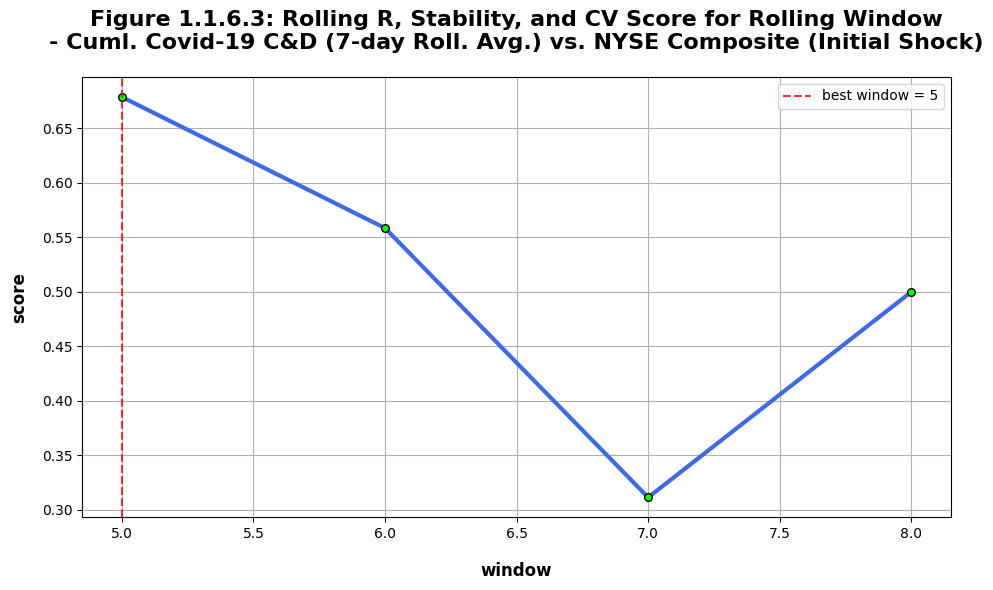

In [91]:
title = 'Figure 1.1.6.3: Rolling R, Stability, and CV Score for Rolling Window\n' \
            + f'- {XTTL} vs. {YTTL[Y.Y4.value]} {PRD}'


matplotlibx.set_corr_scores_xylabels('window', 'score')

matplotlibx.set_corr_scores_marker_size(5.5)


matplotlibx.plot_corr_scores(results_df.loc[:,'score'].to_dict(), title)

### **Rolling R, Stability, and CV Score for Minimum Period: X vs. Y4**

In [92]:
best_mp, _, results_df \
    = mathx.find_optimal_min_periods \
        (x_series, y4_series, best_w, method = corr_method)

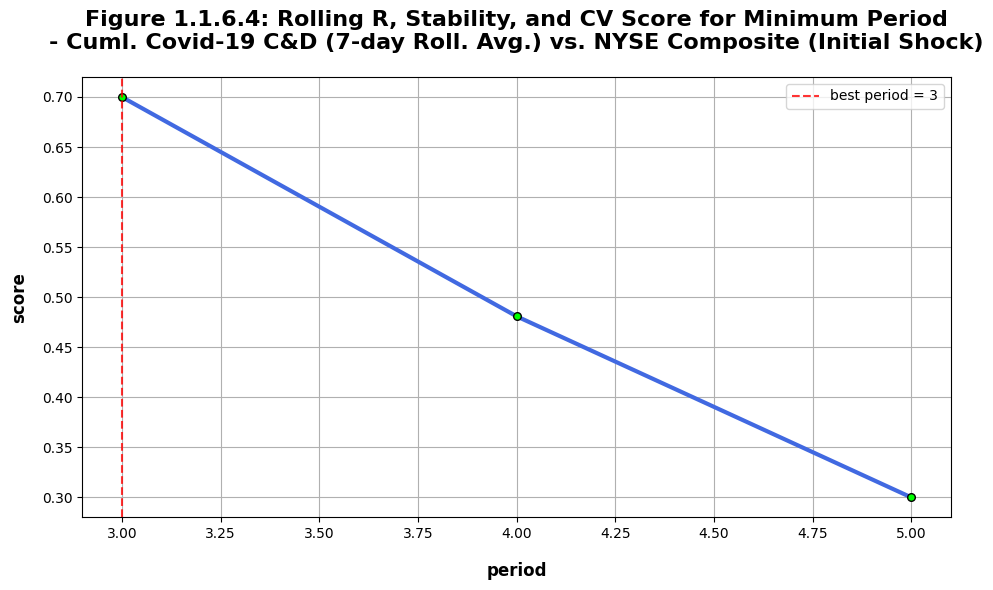

In [93]:
title = 'Figure 1.1.6.4: Rolling R, Stability, and CV Score for Minimum Period\n' \
            + f'- {XTTL} vs. {YTTL[Y.Y4.value]} {PRD}'


matplotlibx.set_corr_scores_xylabels('period', 'score')

matplotlibx.set_corr_scores_marker_size(5.5)


matplotlibx.plot_corr_scores(results_df.loc[:,'score'].to_dict(), title)

### **Rolling Correlation: X vs. Y4**

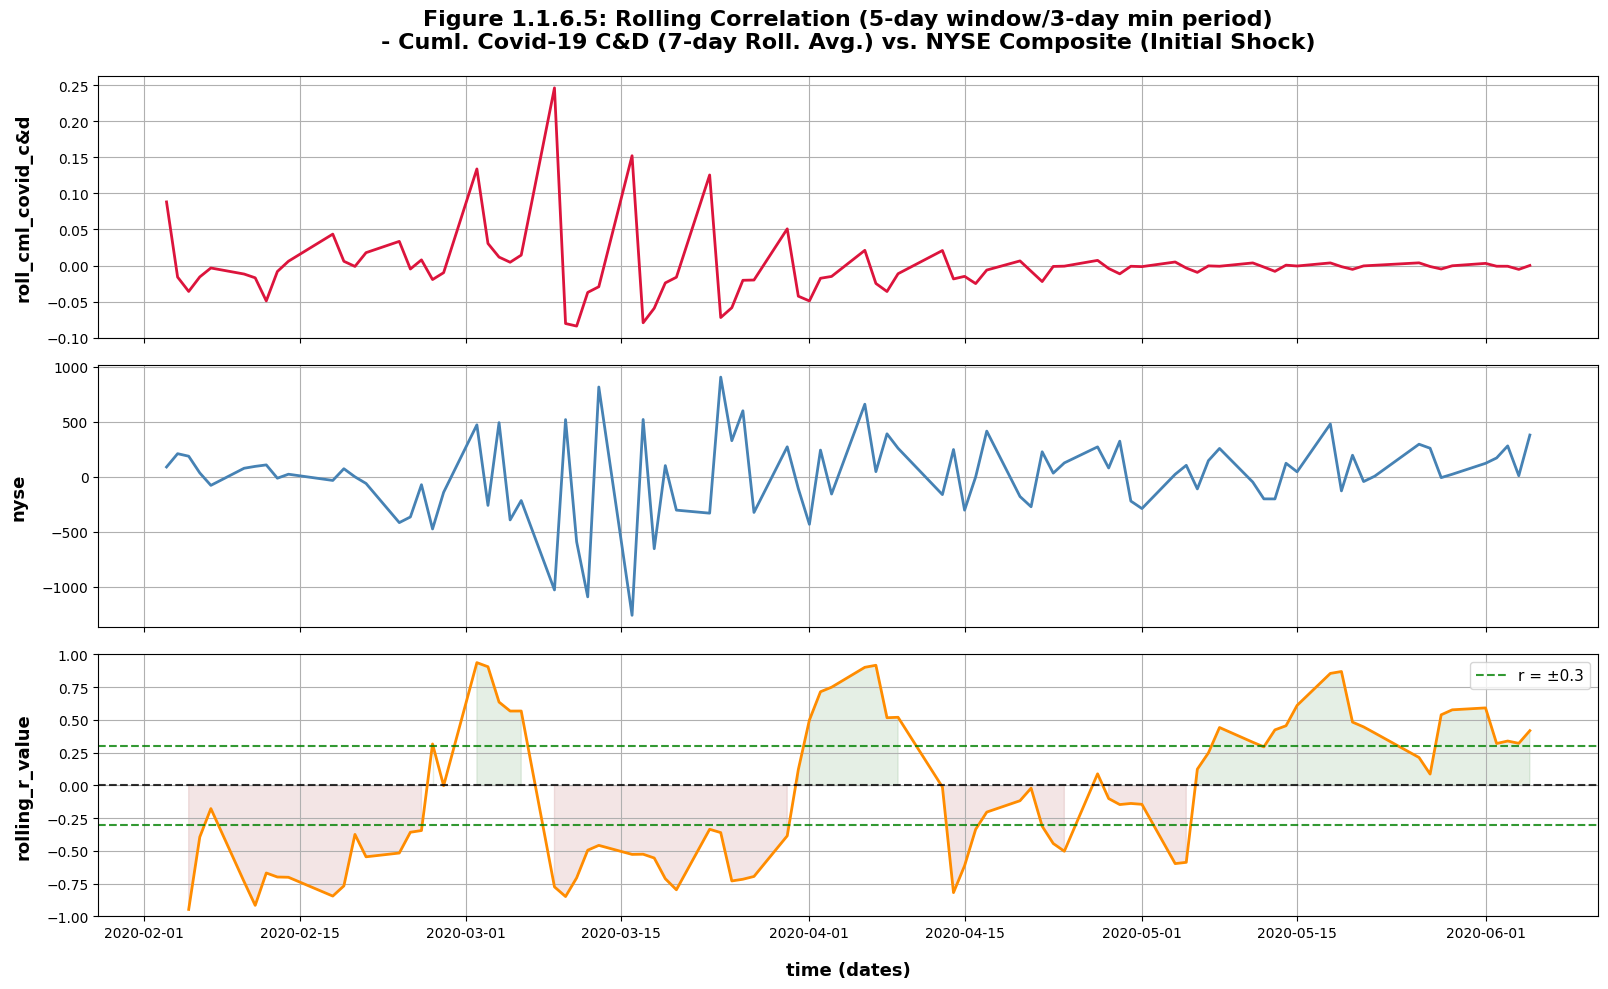

In [94]:
title \
    = f'Figure 1.1.6.5: Rolling Correlation ({best_w}-day window/{best_mp}' \
        + f'-day min period)\n- {XTTL} vs. {YTTL[Y.Y4.value]} {PRD}'

matplotlibx.set_roll_corr_w_mp(best_w, best_mp)

matplotlibx.plot_rolling_corr_lines(x_series, y4_series, title)

### **Lag Correlation: X vs. Y4**

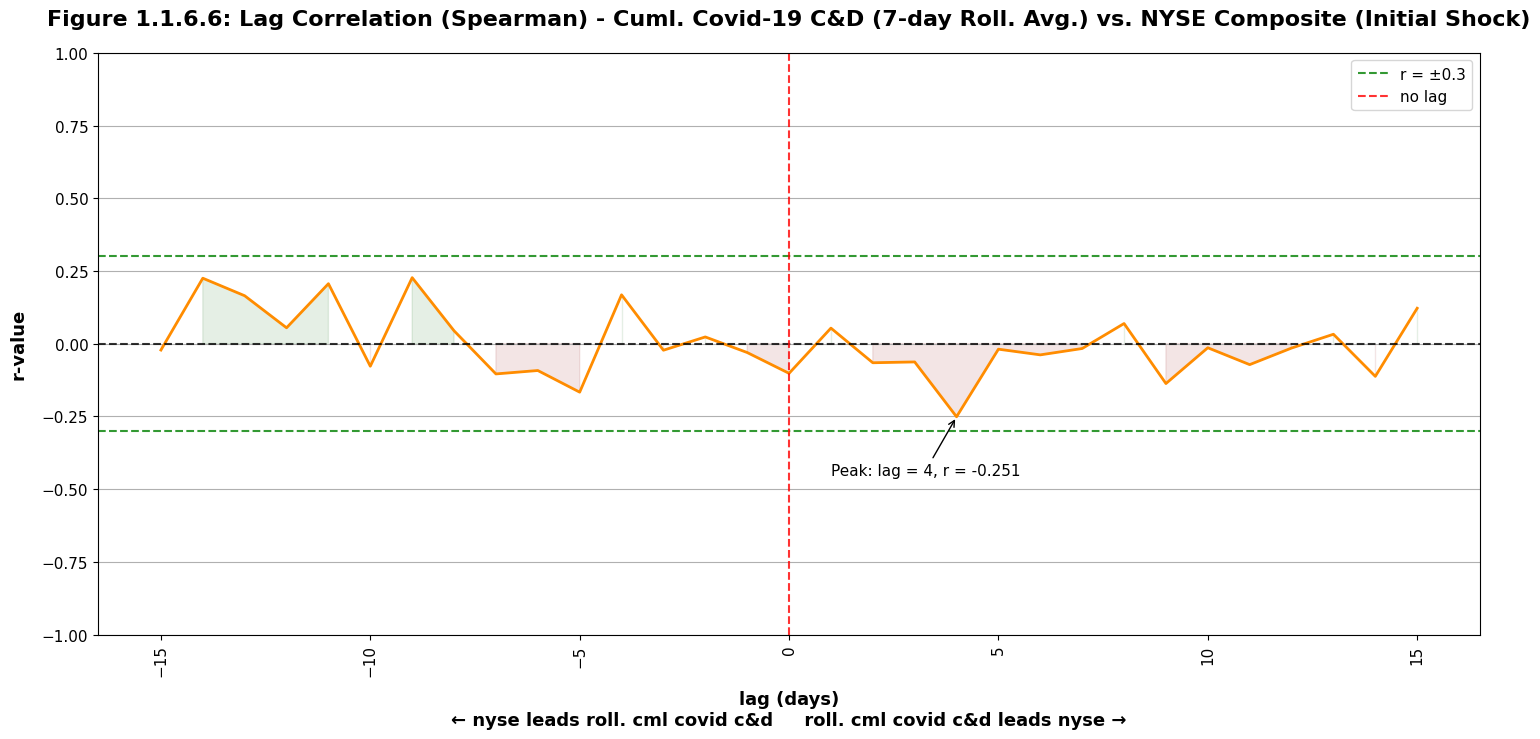

In [95]:
title = f'Figure 1.1.6.6: Lag Correlation ({corr_method.title()}) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y4.value]} {PRD}'

econ_anlys_vrb.set_coords('1.1.6.6', PRD, XCAT, YCOL)


v_lag       = int(x_y4_analysis_df.loc[0, 'lag'])

max_lag     = mathx.find_optimal_lag_corr_maxlag(x_series, y4_series, v_lag, g_lag)

if max_lag > max_max_lag: max_max_lag = max_lag


matplotlibx.set_lag_corr_xylabels(XLBL, YLBL[Y.Y4.value])

matplotlibx.plot_lag_corr_line_chart(x_series, y4_series, title, max_lag = max_lag)

---

## Interpretation: Section 1.1.6 — `covid_c&d` (7-Day Rolling Avg) vs. Y4 (Stock Market Index 4)

**Correlation and Functional Form.** Y4's correlation and polynomial degree results continue to build the cross-index picture. At four indices into the analysis, any outlier — an index with a substantially higher or lower correlation, or with a markedly different optimal polynomial degree — stands out as analytically significant. A degree-2 or higher polynomial for Y4 (if not seen in prior indices) would suggest a threshold or convex/concave response to COVID data that warrants further narrative explanation: for example, small-cap indices may have crashed more severely in percentage terms once case counts crossed a visibility threshold, producing a nonlinear relationship.

**Granger Causality.** The Granger tests for Y4 (Tables 1.1.6.4 and 1.1.6.5) add a fourth data point to the directional causality pattern. If the Y→X direction (Y4 predicting COVID data) is significant for Y4 but not for prior indices, it would be unusual and likely reflects a spurious relationship driven by coincident timing between market recovery and declining case growth in late April / May 2020, rather than genuine market-to-epidemiology causality.

**VAR/VECM Dynamics.** The IRF for Y4 reveals the size and speed of this index's response to a COVID shock. Comparing the IRF peak magnitude and decay period across all four indices analyzed so far reveals whether COVID shocks had more persistent effects on certain market segments. Persistent effects (slow IRF decay) are consistent with VECM-type error correction — where a cointegrating relationship pulls the index back toward a long-run equilibrium with COVID data — while fast IRF decay is consistent with a VAR-type relationship where the shock dissipates quickly.

**Rolling and Lag Correlations.** If Y4's rolling correlation (Figure 1.1.6.5) shows greater instability across the Initial Shock window than earlier indices, it implies that the COVID–Y4 relationship was more structurally volatile — potentially switching from strongly negative during the crash to weakly positive or near-zero during the recovery. This is a useful signal for downstream analysis: a relationship that holds strongly only during one sub-phase of the Initial Shock may not generalize to subsequent pandemic phases.

---


## **1.1.7: X vs. Y5**

### **Create DataFrame X vs. Y5**

In [96]:
comp_df \
    = pd.DataFrame \
        ({XCAT:             x_series,
          YCAT[Y.Y5.value]: y5_series})

logx.log_write_obj(comp_df)

In [97]:
title = f'Table 1.1.7.1: {XTTL} vs. {YTTL[Y.Y5.value]} {PRD}'

pandasx.rtn_fmt_tbl \
    (comp_df, title, hide_idx_bool = False) \
        .format({XCAT:             pandasx.fmt_dict['flt_int'],
                 YCAT[Y.Y5.value]: pandasx.fmt_dict['flt_int']})

,roll_cml_covid_c&d,russell
series,,
2020-02-03,0,22
2020-02-04,-0,28
2020-02-05,-0,29
2020-02-06,-0,-1
2020-02-07,-0,-17
2020-02-10,-0,14
2020-02-11,-0,13
2020-02-12,-0,15
2020-02-13,-0,8


### **AIC, Cross-validated R², and Overfitting Score for Polynomial Degree: X vs. Y5**

In [98]:
title = 'Table 1.1.7.2: AIC, Cross-validated R², and Overfitting Score for Polynomial Degree ' \
            + f'- {XTTL} vs. {YTTL[Y.Y5.value]} {PRD}'


best_deg, scores_dict, _, results_df = mathx.opt_poly_degree(y5_series, x_series)

corr_method = mathx.find_opt_corr_method(y5_series, x_series)


pandasx.rtn_fmt_tbl(results_df, title) \
    .map(pandasx.highlight_bool_col, subset = ['overfit']) \
    .apply(pandasx.highlight_val_row, col = 'degree', val = best_deg, axis = 1)

degree,train_r2,cv_r2,cv_r2_std,cv_norm,aic,aic_norm,overfit,combined_score
1,0.07,-3.21,5.24,1.00,-536.62,0.00,True,0.50
2,0.11,-1.97,3.12,1.00,-538.03,0.14,True,0.57
3,0.21,-2.05,2.10,1.00,-546.47,0.99,True,0.99
4,0.22,-2.89,3.03,1.00,-545.33,0.87,True,0.94
5,0.22,-20.57,36.07,1.00,-543.47,0.69,True,0.84
6,0.26,-78.50,152.87,1.00,-546.60,1.00,True,1.00
7,0.28,-95.08,186.26,1.00,-546.04,0.94,True,0.97
8,0.26,"-1,570.49","3,137.02",1.00,-542.63,0.60,True,0.80
9,0.29,"-726,272.67","1,452,540.95",0.00,-544.22,0.76,True,0.38
10,0.28,"-223,961.67","447,918.28",0.69,-540.73,0.41,True,0.55


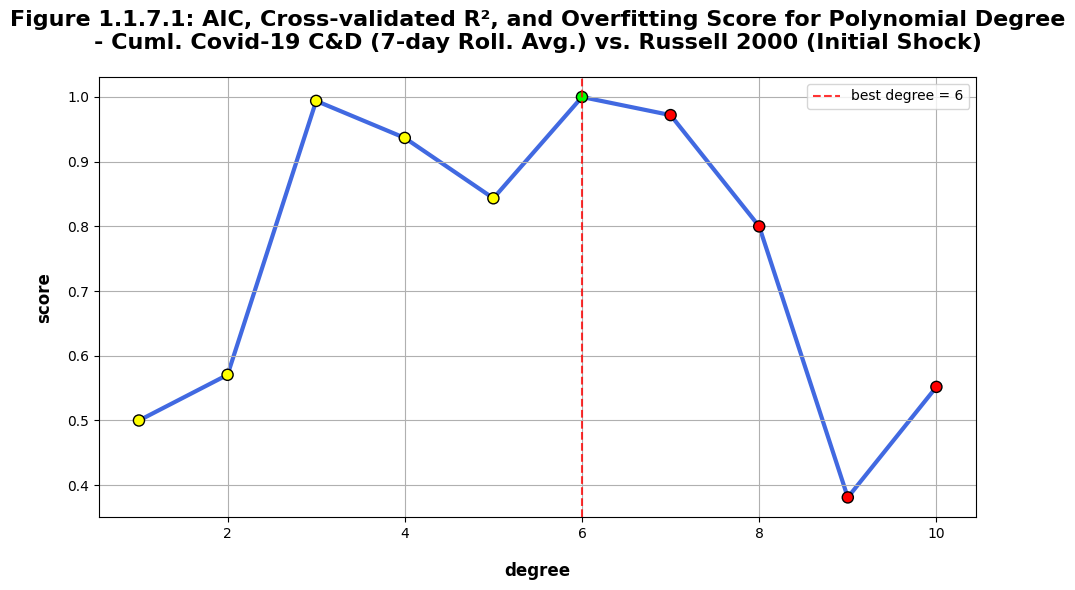

In [99]:
title = 'Figure 1.1.7.1: AIC, Cross-validated R², and Overfitting Score for Polynomial Degree\n' \
            + f'- {XTTL} vs. {YTTL[Y.Y5.value]} {PRD}'


matplotlibx.set_corr_scores_xylabels('degree', 'score')

matplotlibx.set_corr_scores_marker_size(8.0)

matplotlibx.set_lag_corr_method(corr_method)


matplotlibx.plot_corr_scores(scores_dict, title, best_deg)

### **Correlation: X vs. Y5**

In [100]:
title = f'Table 1.1.7.3: Correlation ({corr_method.title()}) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y5.value]} {PRD}'

pandasx.rtn_fmt_tbl(comp_df.corr(method = corr_method), title, hide_idx_bool = False)

,roll_cml_covid_c&d,russell
roll_cml_covid_c&d,1.00,-0.07
russell,-0.07,1.00


### **Scatter Plot: X vs. Y5**

r-value (pearson):	-0.272
r-value (spearman):	-0.074
tau (kendall):		-0.057

p-value (pearson):	0.011
p-value (spearman):	0.495
p-value (kendall):	0.431




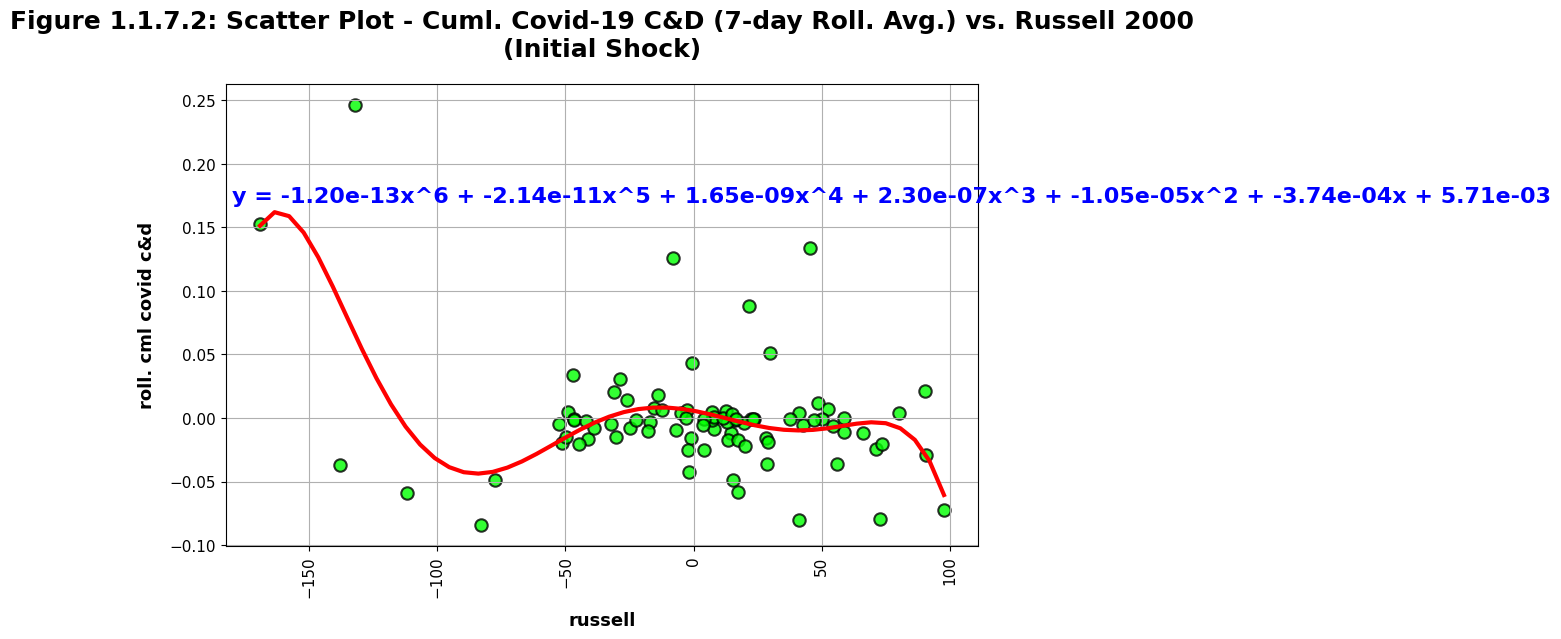

In [101]:
title = 'Figure 1.1.7.2: Scatter Plot ' \
            + f'- {XTTL} vs. {YTTL[Y.Y5.value]}\n{PRD}'

econ_anlys_vrb.set_coords('1.1.7.2', PRD, XCAT, YCOL)
            

matplotlibx.set_scatterplot_chart_xylabels(YLBL[Y.Y5.value], XLBL)

matplotlibx.set_scatterplot_chart_xylabels_fontsize(13.0, 13.0)

matplotlibx.set_scatterplot_chart_xyticks_fontsize(11.0, 11.0)

matplotlibx.set_scatterplot_chart_title_fontsize(18.0)

matplotlibx.set_regr_degree(best_deg)


matplotlibx.scatterplot_chart([y5_series, x_series], title)

### **The Granger Causality Test: X -> Y5**

In [102]:
title = 'Table 1.1.7.4: The Granger Causality Test ' \
            + f'- {XTTL} -> {YTTL[Y.Y5.value]} {PRD}'


grngr_mth, _, _    = mathx.find_optimal_granger_method(x_series, y5_series)

g_lag, _           = mathx.find_optimal_granger_lag(x_series, y5_series, method = grngr_mth)

test_df, best_dict = mathx.granger_causality_test(x_series, y5_series, maxlag = g_lag, method = grngr_mth)


grngr_bst_list += [best_dict]

grngr_nm_list  += [f'{XCAT} -> {YCAT[Y.Y5.value]}']


pandasx.rtn_fmt_tbl \
    (test_df, title, hide_idx_bool = False, line_cnt_int = len(test_df)) \
        .apply(pandasx.highlight_median_row,    col = 'f_p_value', df = test_df, axis = 1) \
        .apply(pandasx.highlight_high_low_rows, col = 'f_p_value', df = test_df, axis = 1) \
        .format('{:,.6f}', subset = ['f_statistic', 'f_p_value'])

,f_statistic,f_p_value,f_significant,chi2_significant,lrtest_significant,params_f_significant,conclusion
lag,,,,,,,
1,2.688035,0.104889,False,False,False,False,high confidence
2,1.423867,0.246817,False,False,False,False,high confidence
3,1.703418,0.173296,False,False,False,False,high confidence
4,1.499089,0.211210,False,False,False,False,high confidence
5,2.935074,0.018249,True,True,True,True,high confidence


### **The Granger Causality Test: Y5 -> X**

In [103]:
title = 'Table 1.1.7.5: The Granger Causality Test ' \
            + f'- {YTTL[Y.Y5.value]} -> {XTTL} {PRD}'


test_df, best_dict = mathx.granger_causality_test(y5_series, x_series, maxlag = g_lag, method = grngr_mth)


grngr_bst_list += [best_dict]

grngr_nm_list  += [f'{YCAT[Y.Y5.value]} -> {XCAT}']


pandasx.rtn_fmt_tbl \
    (test_df, title, hide_idx_bool = False, line_cnt_int = len(test_df)) \
        .apply(pandasx.highlight_median_row,    col = 'f_p_value', df = test_df, axis = 1) \
        .apply(pandasx.highlight_high_low_rows, col = 'f_p_value', df = test_df, axis = 1) \
        .format('{:,.6f}', subset = ['f_statistic', 'f_p_value'])

,f_statistic,f_p_value,f_significant,chi2_significant,lrtest_significant,params_f_significant,conclusion
lag,,,,,,,
1,0.198053,0.657456,False,False,False,False,high confidence
2,0.820575,0.443849,False,False,False,False,high confidence
3,0.607925,0.611865,False,False,False,False,high confidence
4,0.800186,0.528919,False,False,False,False,high confidence
5,0.961407,0.447372,False,False,False,False,high confidence


### **VAR/VECM Analysis: X vs. Y5**

In [104]:
results_dict = mathx.fit_var_or_vecm(x_series, y5_series)

x_y5_analysis_df = results_dict['summary_df']


title = f'VAR/VECM Analysis: {XTTL} -> {YTTL[Y.Y5.value]} {PRD}'

msg = results_dict['conclusion']


logx.print_and_log_text('\033[1m' + msg + '\033[0m')

logx.write_to_folder(msg, title)

ROLL_CML_COVID_C&D VS. RUSSELL ANALYSIS

Model selected: VECM.

Series 'x' is non-stationary (ADF = -2.498188, p = 0.115916).

Series 'y' is non-stationary (ADF = -2.521357, p = 0.110364).

Trace and max-eigenvalue tests agree. Both series appear stationary at levels — VAR on levels is appropriate.

Recommended lag (BIC): 5.
AIC = 7, BIC = 5, HQIC = 7, FPE = 7.

VECM(lag = 4, rank = 1) fitted. Adjustment speeds — x: 0.079848, y: -937.748885. Error correction half-life: inf periods. x - (-0.001062) * y = 0  (long-run equilibrium). Mean reversion: CONFIRMED.

IRF (VECM, 30 periods):
A one-SD shock to x produces a negative net response in y.
Peak x→y effect at lag 5 (magnitude: -434.918465).
Cumulative x→y response: -5863.325181.

FEVD (VECM, horizon = 31):
x shocks explain 19.183605% of y's forecast variance (moderate influence).
y's own shocks explain 80.816395% of its own variance.



### **Impulse Response Functions (IRF): X vs. Y5**

In [105]:
title = 'Table 1.1.7.6: Impulse Response Functions (IRF) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y5.value]} {PRD}'

try:

    test_df = results_dict['irf_result']['irf_df']

    if len(test_df) > 0:

        display \
            (pandasx.rtn_fmt_tbl \
                (test_df, 
                 title, 
                 hide_idx_bool = False, 
                 line_cnt_int = len(test_df)) \
                    .highlight_min(color = 'mistyrose') \
                    .highlight_max(color = 'greenyellow') \
                    .apply(pandasx.highlight_median_col) \
                    .format('{:,.6f}'))

    else:

        irf_bool = False

        logx.write_to_folder \
            ('\nThere is no Impulse Response Function present with VECM model: ' \
                 + f'{XTTL} vs. {YTTL[Y.Y4.value]} {PRD}\n')
    
except:

    irf_bool = False

    logx.write_to_folder \
        ('\nThere is no Impulse Response Function present with VECM model: ' \
             + f'{XTTL} vs. {YTTL[Y.Y5.value]} {PRD}\n')

,x_shock_x_response,x_shock_y_response,y_shock_x_response,y_shock_y_response
period,,,,
0,1.000000,0.000000,0.000000,1.000000
1,0.084125,35.943489,0.000122,-0.220694
2,-0.025623,-176.549348,0.000019,0.364996
3,0.121078,-283.196520,0.000105,-0.165711
4,0.052071,-142.977614,-0.000074,-0.001307
5,0.778141,-434.918465,-0.000030,-0.046305
6,0.081239,25.322086,0.000086,-0.104025
7,-0.016407,-268.001057,-0.000006,0.046039
8,0.179609,-236.172638,0.000083,-0.078979


### **Forecast Error Variance Decomposition (FEVD): X vs. Y5**

In [106]:
if irf_bool:
    
    title = 'Table 1.1.7.7: Forecast Error Variance Decomposition (FEVD) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y5.value]} {PRD}'

else:

    title = 'Table 1.1.7.6: Forecast Error Variance Decomposition (FEVD) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y5.value]} {PRD}'  

test_df = results_dict['fevd_result']['fevd_df']

pandasx.rtn_fmt_tbl \
    (test_df, 
     title, 
     hide_idx_bool = False, 
     line_cnt_int = len(test_df)) \
        .highlight_min(color = 'mistyrose') \
        .highlight_max(color = 'greenyellow') \
        .apply(pandasx.highlight_median_col) \
        .format('{:,.6f}')

,y_variance_from_x,y_variance_from_y,x_variance_from_x,x_variance_from_y
period,,,,
0,0.013190,0.986810,1.000000,0.000000
1,0.015078,0.984922,0.972350,0.027650
2,0.037455,0.962545,0.972118,0.027882
3,0.060352,0.939648,0.950951,0.049049
4,0.064732,0.935268,0.945829,0.054171
5,0.117133,0.882867,0.962037,0.037963
6,0.121347,0.878653,0.955114,0.044886
7,0.134208,0.865792,0.955691,0.044309
8,0.138699,0.861301,0.949473,0.050527


### **Rolling R, Stability, and CV Score for Rolling Window: X vs. Y5**

In [107]:
best_w, _, results_df \
    = mathx.find_optimal_rolling_window \
        (x_series, y5_series, method = corr_method)

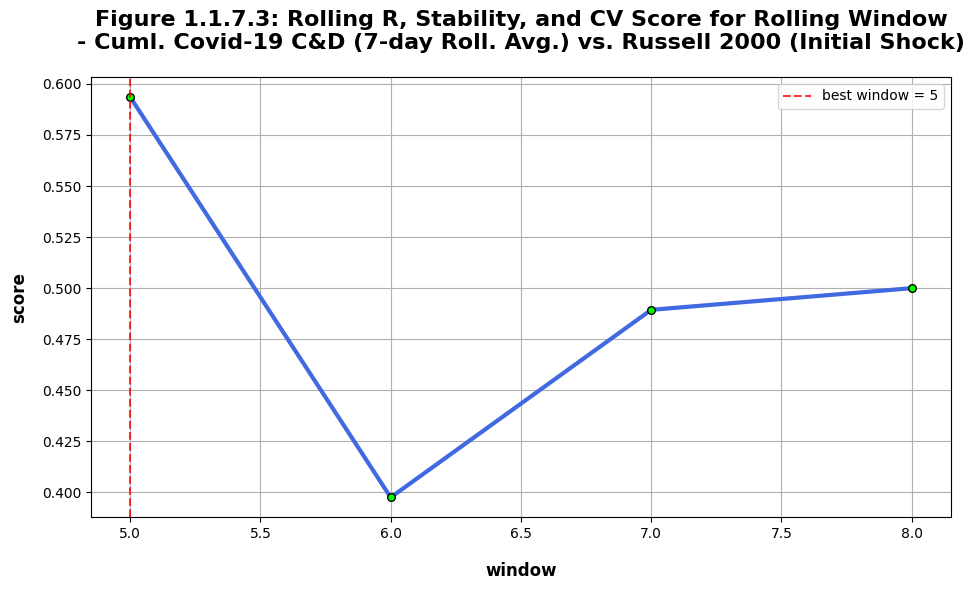

In [108]:
title = 'Figure 1.1.7.3: Rolling R, Stability, and CV Score for Rolling Window\n' \
            + f'- {XTTL} vs. {YTTL[Y.Y5.value]} {PRD}'


matplotlibx.set_corr_scores_xylabels('window', 'score')

matplotlibx.set_corr_scores_marker_size(5.5)


matplotlibx.plot_corr_scores(results_df.loc[:,'score'].to_dict(), title)

### **Rolling R, Stability, and CV Score for Minimum Period: X vs. Y5**

In [109]:
best_mp, _, results_df \
    = mathx.find_optimal_min_periods \
        (x_series, y5_series, best_w, method = corr_method)

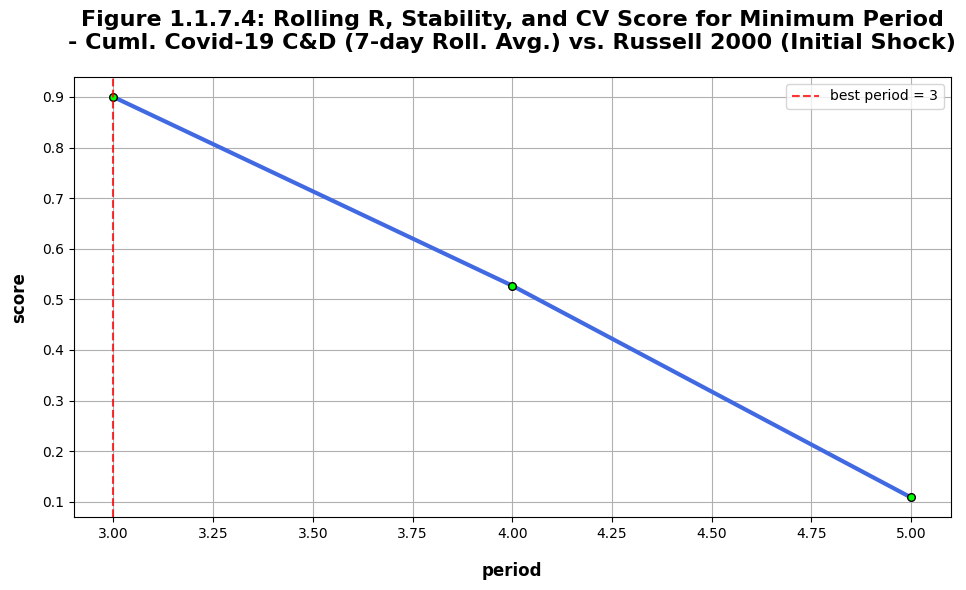

In [110]:
title = 'Figure 1.1.7.4: Rolling R, Stability, and CV Score for Minimum Period\n' \
            + f'- {XTTL} vs. {YTTL[Y.Y5.value]} {PRD}'


matplotlibx.set_corr_scores_xylabels('period', 'score')

matplotlibx.set_corr_scores_marker_size(5.5)


matplotlibx.plot_corr_scores(results_df.loc[:,'score'].to_dict(), title)

### **Rolling Correlation: X vs. Y5**

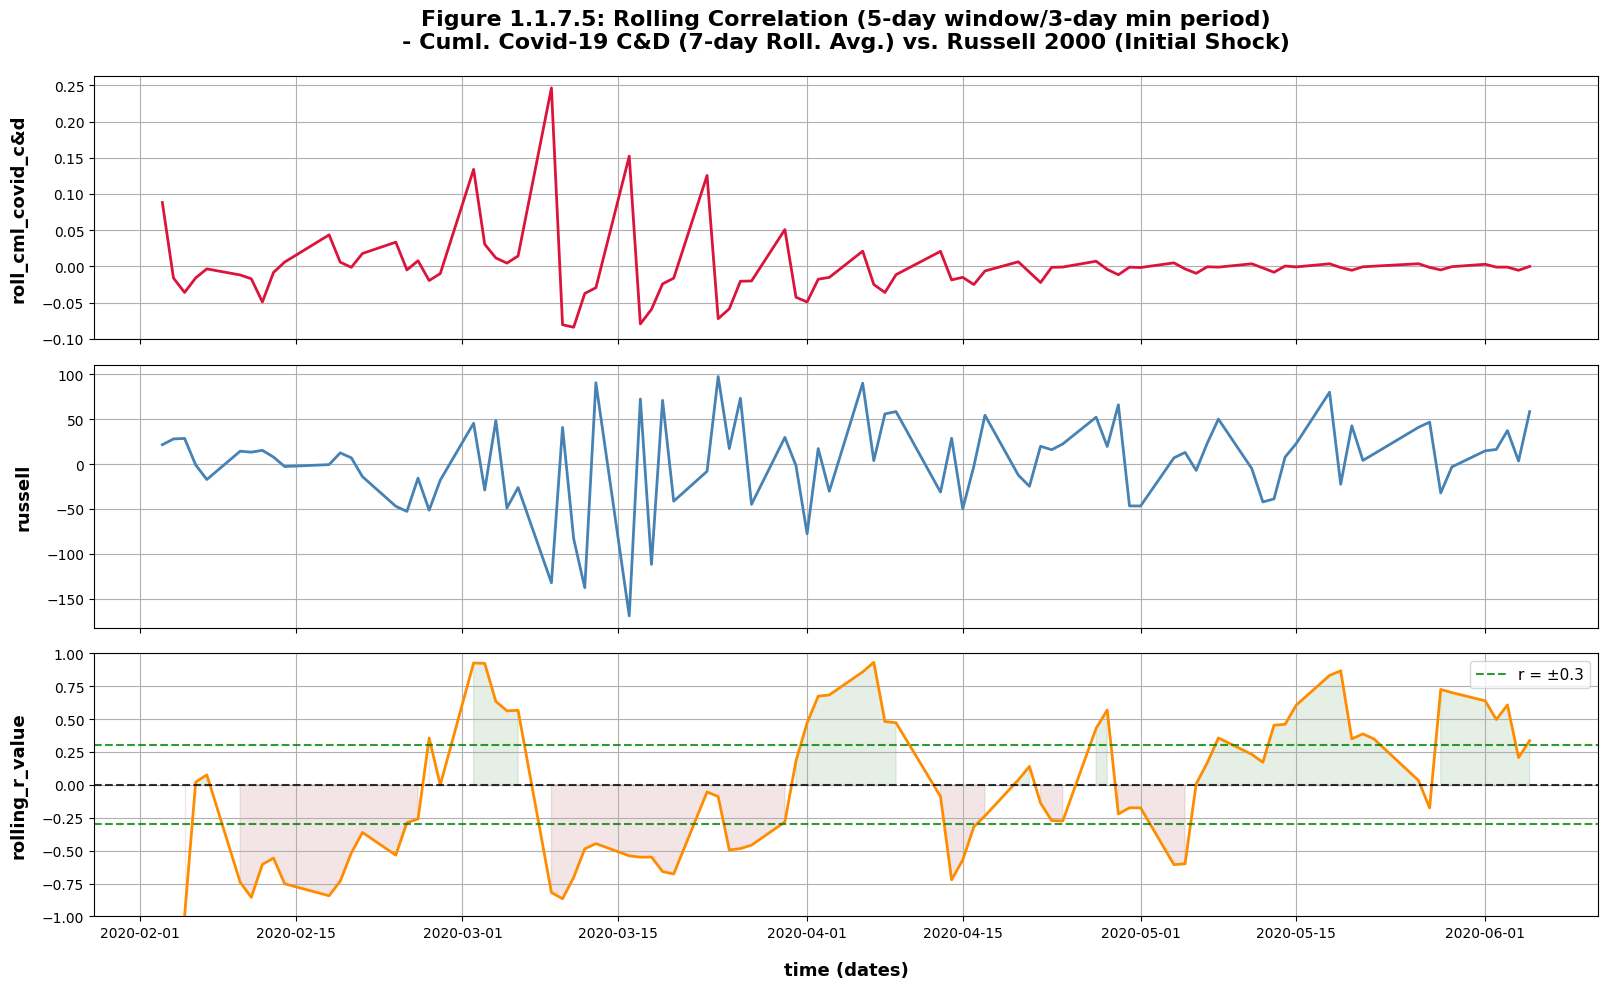

In [111]:
title \
    = f'Figure 1.1.7.5: Rolling Correlation ({best_w}-day window/{best_mp}' \
        + f'-day min period)\n- {XTTL} vs. {YTTL[Y.Y5.value]} {PRD}'

matplotlibx.set_roll_corr_w_mp(best_w, best_mp)

matplotlibx.plot_rolling_corr_lines(x_series, y5_series, title)

### **Lag Correlation: X vs. Y5**

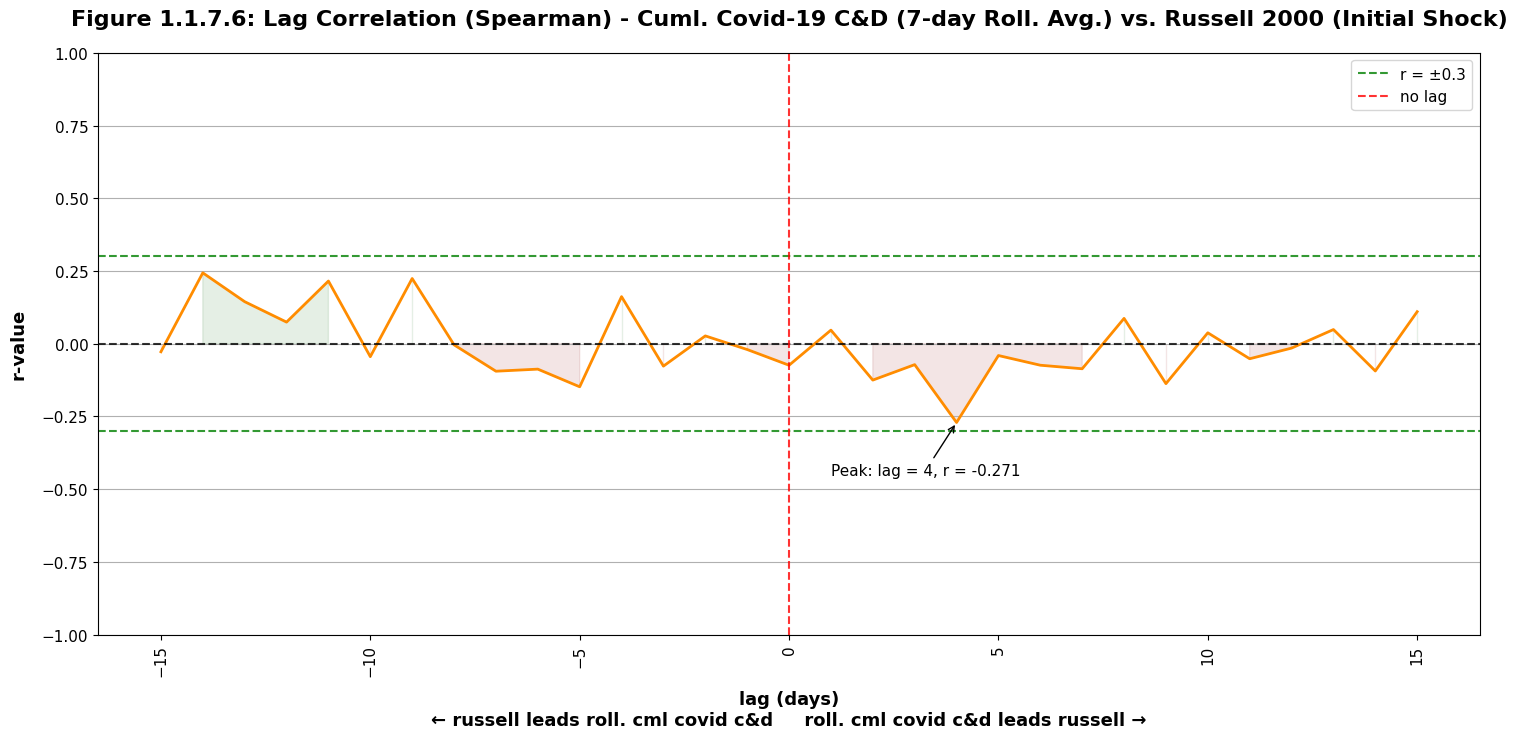

In [112]:
title = f'Figure 1.1.7.6: Lag Correlation ({corr_method.title()}) ' \
            + f'- {XTTL} vs. {YTTL[Y.Y5.value]} {PRD}'

econ_anlys_vrb.set_coords('1.1.7.6', PRD, XCAT, YCOL)


v_lag       = int(x_y5_analysis_df.loc[0, 'lag'])

max_lag     = mathx.find_optimal_lag_corr_maxlag(x_series, y5_series, v_lag, g_lag)

if max_lag > max_max_lag: max_max_lag = max_lag


matplotlibx.set_lag_corr_xylabels(XLBL, YLBL[Y.Y5.value])

matplotlibx.plot_lag_corr_line_chart(x_series, y5_series, title, max_lag = max_lag)

---

## Interpretation: Section 1.1.7 — `covid_c&d` (7-Day Rolling Avg) vs. Y5 (Stock Market Index 5)

**Correlation and Functional Form.** Y5 is the fifth and final individual index analysis. Its polynomial degree and correlation results complete the cross-index comparison that began with Y1. If Y5's contemporaneous correlation is the strongest or weakest of the five, it marks this index as either the most or least directly linked to COVID data during the Initial Shock. The scatter plot (Figure 1.1.7.2) provides a visual check on whether any outlier observations — for example, the single-day extreme moves of mid-March 2020 — are disproportionately influencing the regression fit, which would be relevant for interpreting the polynomial degree selection.

**Granger Causality.** The Granger causality results for Y5 (Tables 1.1.7.4 and 1.1.7.5) complete the full 5×2 causality matrix (five indices, two directions each). The assembled Granger summary in Table 1.1.8.4 will present all ten direction-pairs together, making it straightforward to identify whether the X→Y direction is consistently significant across all five indices or whether it holds only for a subset — a critical finding for assessing the robustness of the COVID-to-market causal story.

**VAR/VECM Dynamics.** The IRF and FEVD for Y5 complete the set of VAR/VECM results that feed into the VAR/VECM summary table (Table 1.1.8.5). If Y5's FEVD X-share is materially different from the other four indices, it will stand out in the summary as either the index most or least driven by COVID dynamics. A high X-share for Y5 combined with a significant X→Y5 Granger result would make it the strongest single-pair COVID-market candidate in this analysis.

**Rolling and Lag Correlations.** The lag correlation for Y5 (Figure 1.1.7.6), together with the lag correlation heatmap in Figure 1.1.8.2 (which spans all five indices), will reveal whether Y5's peak lag is consistent with the other four indices or is an outlier. A consistent peak lag of 1–7 days across all five indices would confirm a systematic pattern of markets incorporating COVID information over approximately one weekly reporting cycle — a finding directly attributable to the 7-day rolling average transformation applied to the X series. A divergent peak lag for Y5 would suggest that this index operates on a different informational time scale.

---


## **1.1.8: Summary Results: X vs. Y**

### **Assemble Series Dictionaries: X vs. Y**

In [113]:
if YPCT:

    ttl_dict \
        = {XCAT:                   x_series,
           YCAT[Y.Y1.value] + '%': y1_series,
           YCAT[Y.Y2.value] + '%': y2_series,
           YCAT[Y.Y3.value] + '%': y3_series,
           YCAT[Y.Y4.value] + '%': y4_series,
           YCAT[Y.Y5.value] + '%': y5_series}

    comp_dict \
        = {YCAT[Y.Y1.value] + '%': y1_series,
           YCAT[Y.Y2.value] + '%': y2_series,
           YCAT[Y.Y3.value] + '%': y3_series,
           YCAT[Y.Y4.value] + '%': y4_series,
           YCAT[Y.Y5.value] + '%': y5_series}

else:

    ttl_dict \
        = {XCAT:             x_series,
           YCAT[Y.Y1.value]: y1_series,
           YCAT[Y.Y2.value]: y2_series,
           YCAT[Y.Y3.value]: y3_series,
           YCAT[Y.Y4.value]: y4_series,
           YCAT[Y.Y5.value]: y5_series}

    comp_dict \
        = {YCAT[Y.Y1.value]: y1_series,
           YCAT[Y.Y2.value]: y2_series,
           YCAT[Y.Y3.value]: y3_series,
           YCAT[Y.Y4.value]: y4_series,
           YCAT[Y.Y5.value]: y5_series}

### **Correlations: X vs. Y**

In [114]:
title = f'Table 1.1.8.1: Correlations ({corr_method.title()}) ' \
            + f'- {XTTL} vs. {YSBJ} {PRD}'

test_df = mathx.best_method_corr_matrix(pd.DataFrame(ttl_dict))

pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False) \
    .format('{:,.3f}')

,roll_cml_covid_c&d,sp500,djia,nasdaq,nyse,russell
series,,,,,,
roll_cml_covid_c&d,1.000,0.349,-0.090,0.039,-0.102,-0.074
sp500,0.349,1.000,0.153,0.162,0.148,0.119
djia,-0.090,0.153,1.000,0.462,0.986,0.948
nasdaq,0.039,0.162,0.462,1.000,0.446,0.425
nyse,-0.102,0.148,0.986,0.446,1.000,0.961
russell,-0.074,0.119,0.948,0.425,0.961,1.000


### **Polynomial Degrees for Correlations Summary: X vs. Y**

In [115]:
title = 'Table 1.1.8.2: Polynomial Degrees for Correlations Summary ' \
            + f'- {XTTL} vs. {YSBJ} {PRD}'

test_df = mathx.opt_degree_summ_df(x_series, comp_dict)

pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False) \
    .format('{:,.4f}', subset = ['train_r2', 'cv_r2', 'cv_r2_std'])

,best_degree,coefficients,intercept,train_r2,cv_r2,cv_r2_std,aic,linearity_adequate
series,,,,,,,,
sp500,5,"['-1.90e+07', '8.04e+06', '-5.71e+05', '-9.28e+04', '6.04e+03']",9.57e+01,0.3258,"-35,663.4774","71,316.0998",956.44,True
djia,9,"['1.29e+13', '-6.06e+12', '6.89e+11', '4.05e+10', '-9.07e+09', '4.18e+07', '2.85e+07', '-2.64e+05', '-1.70e+04']",7.82e+01,0.3528,"-198,232,198.5845","396,464,394.0816","1,151.33",True
nasdaq,4,"['2.20e+06', '-6.09e+05', '5.80e+02', '3.46e+03']",2.02e+01,0.1290,-278.4080,556.0383,938.45,True
nyse,9,"['5.56e+12', '-2.64e+12', '3.05e+11', '1.72e+10', '-4.03e+09', '2.47e+07', '1.28e+07', '-1.38e+05', '-7.87e+03']",4.49e+01,0.3592,"-2,882,616,206.7024","5,765,232,410.1854","1,009.99",True
russell,9,"['6.55e+11', '-3.11e+11', '3.58e+10', '2.09e+09', '-4.88e+08', '2.96e+06', '1.64e+06', '-1.95e+04', '-1.06e+03']",7.60e+00,0.3191,"-5,581,000,706.0685","11,162,001,410.3388",667.69,True


### **The Engle-Granger Cointegration Test: X vs. Y**

In [116]:
title = 'Table 1.1.8.3: The Engle-Granger Cointegration Test ' \
            + f'- {XTTL} vs. {YSBJ} {PRD}'

test_df = mathx.eg_coint_test_summ_df(x_series, comp_dict)

pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False) \
    .format('{:,.6f}', subset = ['p_value'])

,coint_stat,p_value,trend_desc,autolag,passes_mean_test,passes_trend_test,cointegrated
series,,,,,,,
sp500,-1.91,0.270713,no trend,None,True,True,False
djia,-5.99,0.000000,no trend,AIC,True,True,True
nasdaq,-4.55,0.000124,no trend,AIC,True,True,True
nyse,-5.73,0.000001,no trend,AIC,True,True,True
russell,-5.28,0.000005,no trend,AIC,True,True,True


### **The Granger Causality Test Summary: X vs. Y**

In [117]:
title = 'Table 1.1.8.4: The Granger Causality Test Summary ' \
            + f'- {XTTL} vs. {YSBJ} {PRD}'


test_df = pd.DataFrame(grngr_bst_list)

test_df['series'] = list(grngr_nm_list)

test_df = test_df.set_index('series')


pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False) \
    .format('{:,.4f}', subset = ['f_p_value', 'chi2_p_value', 'lrtest_p_value', 'params_f_p_value'])

,f_statistic,chi2_statistic,lrtest_statistic,params_f_statistic,f_p_value,chi2_p_value,lrtest_p_value,params_f_p_value,f_significant,chi2_significant,lrtest_significant,params_f_significant,conclusion
series,,,,,,,,,,,,,
roll_cml_covid_c&d -> sp500,6.80,7.04,6.77,6.80,0.0108,0.0080,0.0093,0.0108,True,True,True,True,high confidence
sp500 -> roll_cml_covid_c&d,2.20,9.86,9.31,2.20,0.0775,0.0429,0.0537,0.0775,False,True,False,False,inconclusive results
roll_cml_covid_c&d -> djia,3.22,18.62,16.78,3.22,0.0111,0.0023,0.0049,0.0111,True,True,True,True,high confidence
djia -> roll_cml_covid_c&d,1.95,4.14,4.04,1.95,0.1491,0.1260,0.1324,0.1491,False,False,False,False,high confidence
roll_cml_covid_c&d -> nasdaq,9.31,9.65,9.15,9.31,0.0031,0.0019,0.0025,0.0031,True,True,True,True,high confidence
nasdaq -> roll_cml_covid_c&d,2.32,13.38,12.40,2.32,0.0522,0.0200,0.0297,0.0522,False,True,True,False,non-normal residuals or insufficient sample size
roll_cml_covid_c&d -> nyse,3.63,20.98,18.68,3.63,0.0055,0.0008,0.0022,0.0055,True,True,True,True,high confidence
nyse -> roll_cml_covid_c&d,1.91,4.06,3.97,1.91,0.1547,0.1314,0.1377,0.1547,False,False,False,False,high confidence
roll_cml_covid_c&d -> russell,2.94,16.95,15.41,2.94,0.0182,0.0046,0.0088,0.0182,True,True,True,True,high confidence


### **VAR/VECM Analysis Summary: X vs. Y**

In [118]:
title = 'Table 1.1.8.5: VAR/VECM Analysis Summary ' \
            + f'- {XTTL} vs. {YSBJ} {PRD}'


test_df \
    = pd.concat \
        ([x_y1_analysis_df, 
          x_y2_analysis_df,
          x_y3_analysis_df,
          x_y4_analysis_df,
          x_y5_analysis_df])

test_df['series'] = list(comp_dict)

test_df = test_df.dropna(how = 'all', axis = 1)

test_df = test_df.set_index('series')


pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False) \
    .format('{:,.4f}', subset = ['fevd_x_share_in_y', 'fevd_y_own_share']) \
    .format('{:,.6f}', subset = ['irf_peak_mag'])

,model_type,x_stationary,y_stationary,coint_rank,lag,is_stable,irf_peak_lag,irf_peak_mag,irf_sign,fevd_x_share_in_y,fevd_y_own_share,half_life
series,,,,,,,,,,,,
sp500,VECM,False,False,2,4,True,30,"-2,682.813359",negative,0.4867,0.5133,inf
djia,VECM,False,False,2,4,True,5,"-6,976.337532",negative,0.1839,0.8161,inf
nasdaq,VECM,False,True,1,4,False,1,993.261784,positive,0.0763,0.9237,inf
nyse,VECM,False,False,2,4,True,5,"-3,468.572785",negative,0.2192,0.7808,inf
russell,VECM,False,False,2,4,True,5,-434.918465,negative,0.1918,0.8082,inf


### **Rolling Windows Summary: X vs. Y**

In [119]:
title = 'Table 1.1.8.6: Rolling Windows Summary ' \
            + f'- {XTTL} vs. {YSBJ} {PRD}'

test_df, w_array = mathx.opt_window_summ_df(x_series, comp_dict)

pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False) \
    .format('{:,.4f}', subset = ['rc_mean', 'rc_std', 'cv_mean', 'cv_std', 'ac1', 'ac1_penalty'])

,optimal_window,rc_mean,rc_std,pct_significant%,cv_mean,cv_std,is_stable,ac1,ac1_penalty,score%
series,,,,,,,,,,
sp500,8,0.1054,0.3915,8.75,0.2959,0.1026,False,0.8037,0.0000,69.53
djia,5,-0.0325,0.5246,12.05,0.4120,0.1373,False,0.8305,0.0000,70.00
nasdaq,5,-0.0518,0.5944,16.87,0.5140,0.0174,False,0.7614,0.0000,80.00
nyse,5,-0.0410,0.5398,14.46,0.4240,0.1565,False,0.8373,0.0000,67.88
russell,5,-0.0265,0.5049,7.23,0.3680,0.1405,False,0.8054,0.0000,59.36


### **Rolling Minimum Periods Summary: X vs. Y**

In [120]:
title = 'Table 1.1.8.7: Rolling Minimum Periods Summary ' \
            + f'- {XTTL} vs. {YSBJ} {PRD}'

roll_corr_df = mathx.opt_min_period_summ_df(x_series, comp_dict, w_array)

pandasx.rtn_fmt_tbl(roll_corr_df, title, hide_idx_bool = False) \
    .format('{:,.3f}', subset = ['warmup_cost', 'stability', 'convergence']) \
    .format('{:,.4f}', subset = ['rc_mean', 'rc_std', 'cv_mean', 'cv_std', 'nan_fraction'])

,min_period,window,rc_mean,rc_std,cv_mean,cv_std,nan_fraction,pct_significant%,warmup_cost,stability,convergence,score%
series,,,,,,,,,,,,
sp500,3,8,0.0676,0.4128,0.3804,0.0866,0.0230,9.41,0.034,1.165,0.801,70.00
djia,3,5,-0.0529,0.5350,0.4550,0.1141,0.0230,12.94,0.034,1.163,0.690,90.00
nasdaq,3,5,-0.0659,0.5948,0.5283,0.0430,0.0230,16.47,0.034,1.129,0.827,65.63
nyse,3,5,-0.0529,0.5390,0.4617,0.1186,0.0230,14.12,0.034,1.148,0.747,70.00
russell,3,5,-0.0471,0.5165,0.4117,0.1241,0.0230,8.24,0.034,1.155,0.710,90.00


### **Rolling Correlations: X vs. Y**

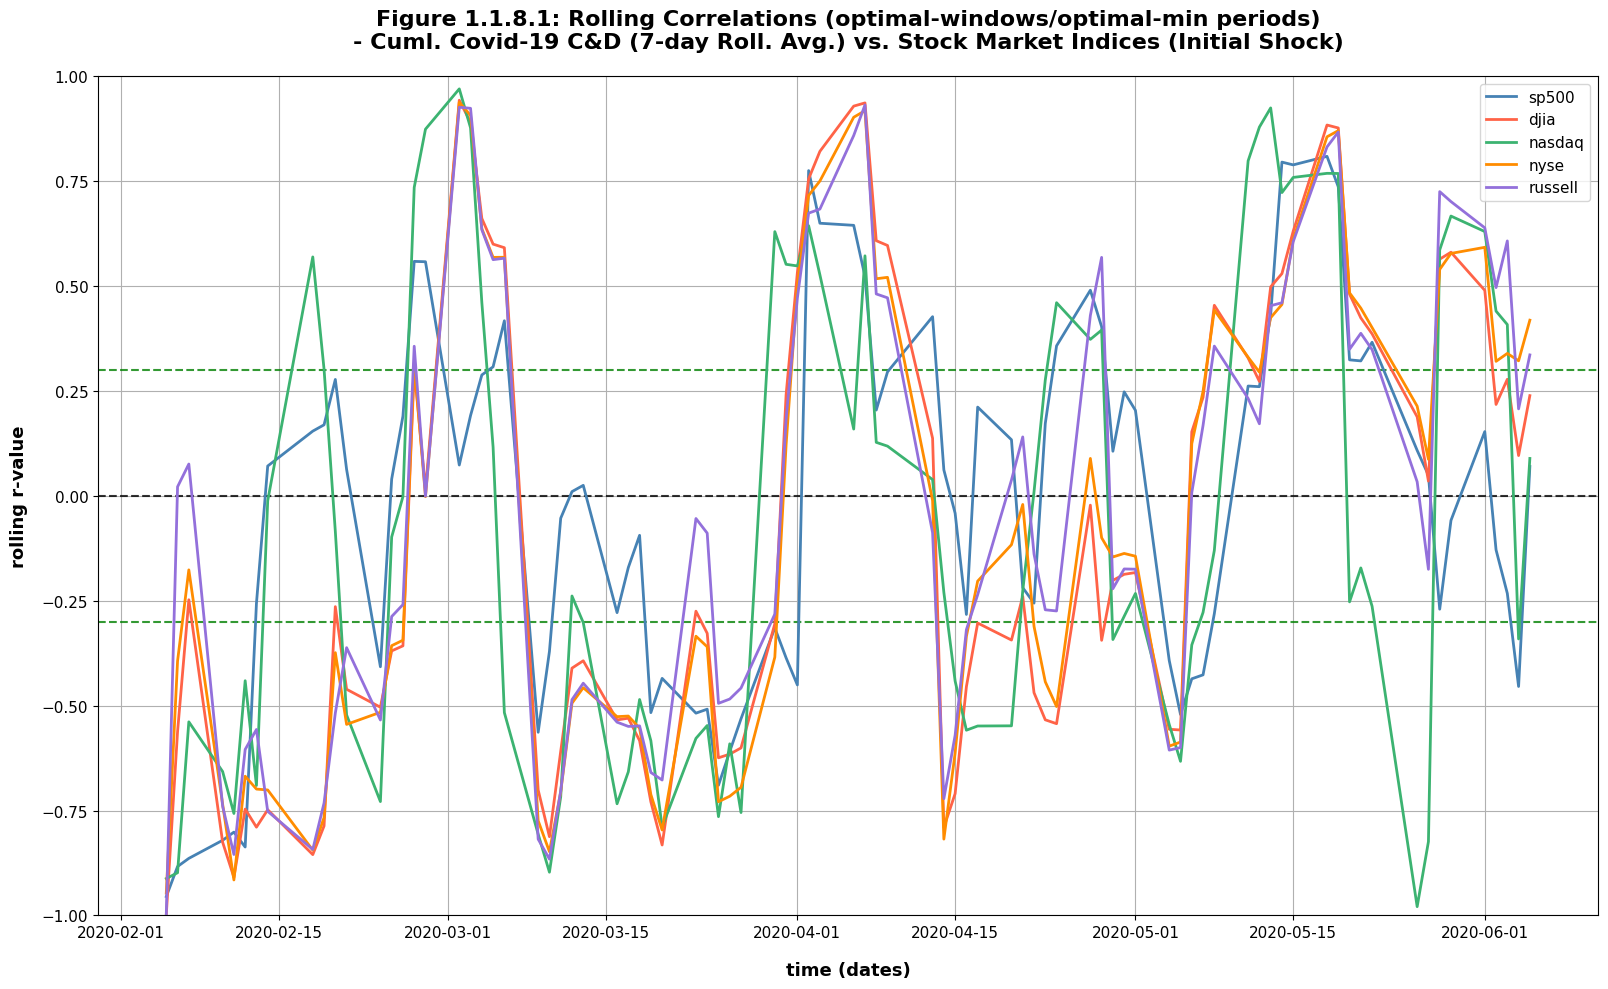

In [121]:
title = 'Figure 1.1.8.1: Rolling Correlations (optimal-windows/optimal-min periods)\n' \
            + f'- {XTTL} vs. {YSBJ} {PRD}'

matplotlibx.set_roll_corr_all_xylabels('time (dates)', 'rolling r-value')

matplotlibx.plot_all_rolling_corrs_lines(x_series, comp_dict, title, roll_corr_df)

### **Lag Correlation Summary: X vs. Y**

In [122]:
title = 'Table 1.1.8.8: Lag Correlations Summary ' \
            + f'- {XTTL} vs. {YSBJ} {PRD}'

test_df = mathx.lag_corr_summ_df(x_series, comp_dict)

pandasx.rtn_fmt_tbl(test_df, title, hide_idx_bool = False) \
    .format('{:,.3f}', subset = ['r_same_day', 'r_peak', 'r_improvement']) \
    .format('{:,.6f}', subset = ['p_same_day', 'raw_p_peak', 'p_peak_bonferroni'])

,r_same_day,p_same_day,significant,peak_lag,r_peak,raw_p_peak,p_peak_bonferroni,significant_peak,r_improvement
series,,,,,,,,,
nasdaq,0.039,0.717085,False,-85,1.000,nan,nan,False,0.961
russell,-0.074,0.495145,False,-83,-1.000,0.000000,0.000000,True,0.926
djia,-0.090,0.408353,False,-83,-1.000,0.000000,0.000000,True,0.910
nyse,-0.102,0.347219,False,-85,1.000,nan,nan,False,0.898
sp500,0.349,0.000919,True,-85,1.000,nan,nan,False,0.651


### **Lag Correlation Heatmap: X vs. Y**

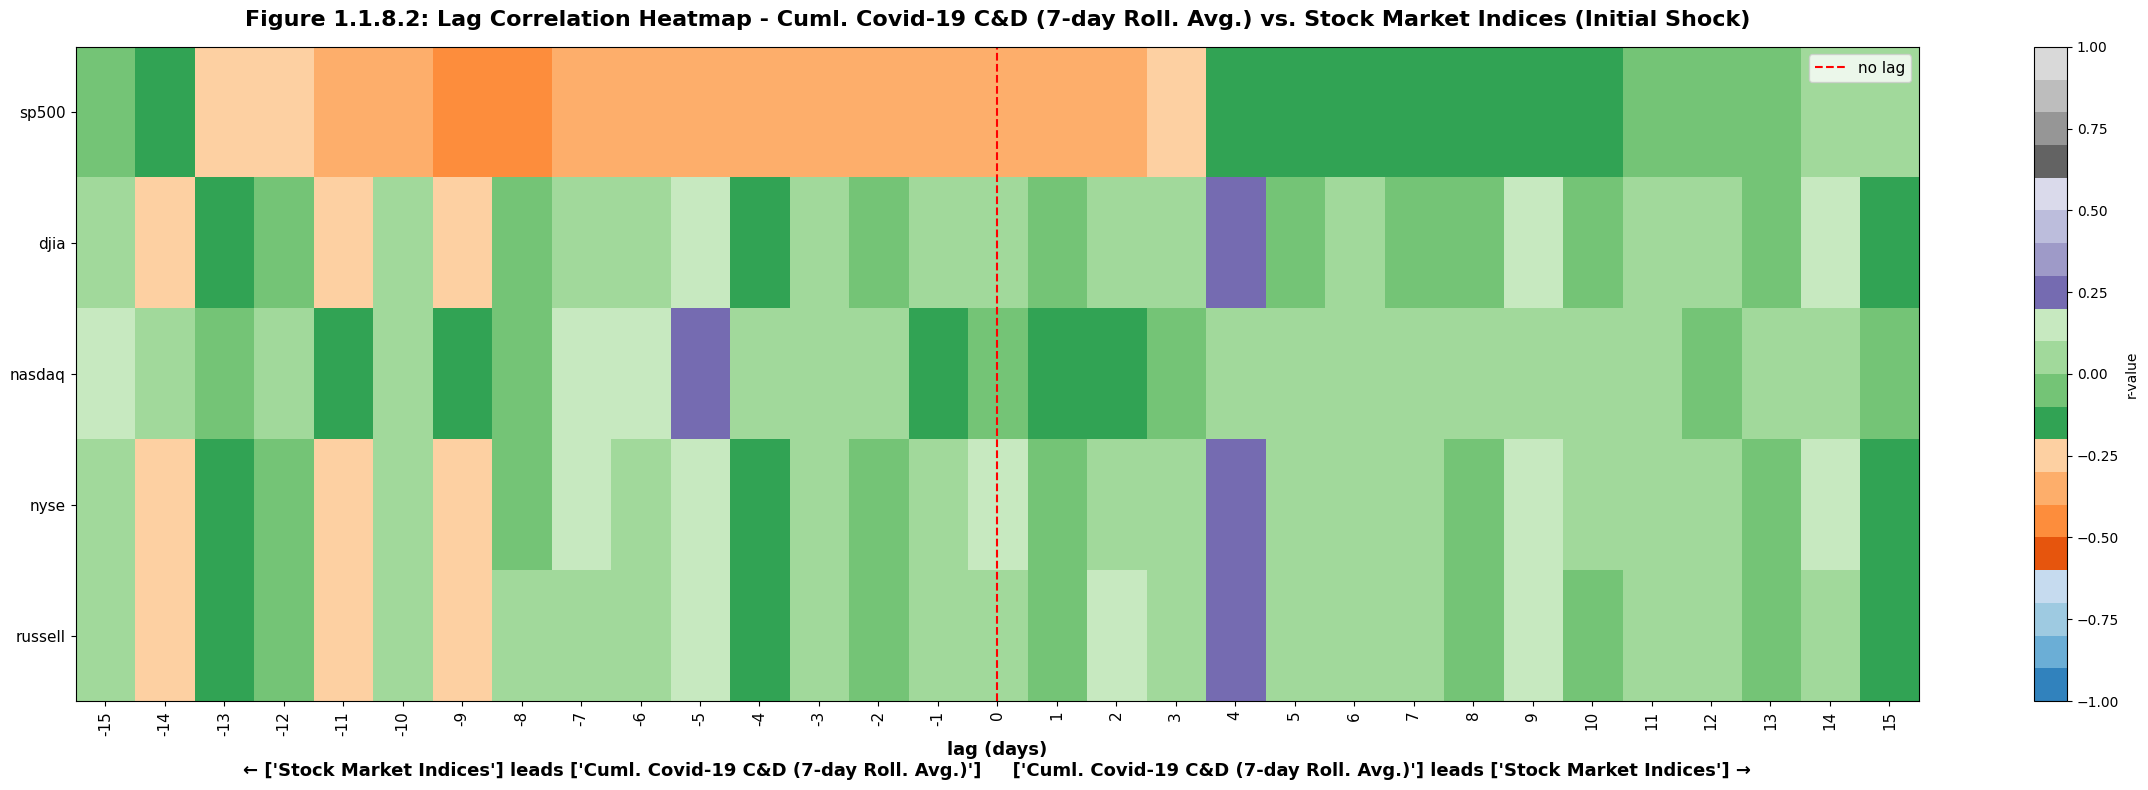

In [123]:
title = 'Figure 1.1.8.2: Lag Correlation Heatmap ' \
            + f'- {XTTL} vs. {YSBJ} {PRD}'


matplotlibx.set_lag_heat_xylabels(XTTL, YSBJ)

matplotlibx.set_lag_heat_corr_method(corr_method)


matplotlibx.plot_lag_heatmap(x_series, comp_dict, title, max_lag = max_max_lag)

---

## Interpretation: Section 1.1.8 — Summary Results Across All Five Stock Market Indices

**Cross-Index Correlation Matrix (Table 1.1.8.1).** The correlation matrix presents pairwise correlations between all six series (the `covid_c&d` X series and five Y indices) after stationarity transformations. The sub-matrix of Y–Y correlations reveals how tightly co-integrated the five indices are with each other. Indices with very high pairwise Y–Y correlations (near ±1.0) are effectively measuring the same underlying market signal, which reduces the analytical value of treating them as independent Y series. The X–Y correlations in the matrix summarize the COVID association strength for each index — the most negative X–Y correlation identifies the index most strongly linked to COVID data in contemporaneous levels terms.

**Polynomial Degrees Summary (Table 1.1.8.2).** The cross-index summary of optimal polynomial degrees, training R², cross-validated R², and CV R² standard deviation provides a stability and fit quality assessment for all five COVID–index relationships. A high CV R² with low CV R² standard deviation indicates a stable, well-estimated relationship. Wide divergence between training R² and CV R² signals overfitting — the polynomial captured noise specific to the Initial Shock window rather than a generalizable signal. Indices with low CV R² overall are poor candidates for structural causal modeling regardless of what the Granger test finds.

**Engle-Granger Cointegration (Table 1.1.8.3).** The cointegration test addresses whether `covid_c&d` and each stock index share a common long-run stochastic trend across the Initial Shock window. Given the short time span (137 days), cointegration is less likely to be detected than over a full multi-year panel; however, the simultaneous exponential rise in COVID counts and the sharp V-shaped market movement could produce a spurious cointegrating vector. A rejection of the no-cointegration null for a subset of indices would indicate that those pairs are best modeled with a VECM (error correction) framework rather than a VAR in differences, which is already handled by the `mathx.fit_var_or_vecm()` function applied in Sections 1.1.3–1.1.7.

**Granger Causality Summary (Table 1.1.8.4).** This table is the most direct test of the central analytical question: did `covid_c&d` Granger-cause stock market index movements during the Initial Shock, and was the causality one-directional (X→Y) or bidirectional? The summary assembles all ten direction-pairs (five indices × two directions). Consistent significance of X→Y across the majority of indices, combined with non-significance of Y→X, would provide robust evidence that pandemic case and death counts were a leading predictor of equity market behavior during the crash — not merely contemporaneously correlated with it. Significant Y→X results for some indices should be interpreted cautiously: in a short window with strong common trends, reverse-direction Granger significance may reflect model misspecification or the shared trend structure rather than genuine market-to-epidemiology feedback.

**VAR/VECM Analysis Summary (Table 1.1.8.5).** The five-row VAR/VECM summary consolidates model type (VAR vs. VECM), optimal lag, IRF peak magnitude, FEVD X-share in Y, and FEVD Y own-share across all indices. The FEVD X-share column is the key metric: it measures what proportion of each index's forecast error variance is attributable to shocks in the COVID series. A high X-share (e.g., above 30–40%) would indicate COVID dominated short-run market variance during the Initial Shock. The IRF peak magnitude quantifies the market-level response to a one-standard-deviation COVID shock; comparing this across indices reveals which market segment reacted most severely to pandemic case data.

**Rolling Correlation Analysis (Tables 1.1.8.6–1.1.8.7 and Figure 1.1.8.1).** The rolling window and minimum period summaries assess the reliability and consistency of the rolling correlation estimates for each index. A high `rc_mean` (mean rolling R) combined with low `rc_std` (rolling R standard deviation) indicates a stable, persistent correlation throughout the Initial Shock window. High `rc_std` relative to `rc_mean` signals that the correlation was episodic — strong during the crash sub-phase but weaker or reversed during the recovery. Figure 1.1.8.1 plots all five rolling correlations on a common time axis, making it possible to visually identify the precise turning point where the COVID–market correlation shifted, and whether all five indices shifted simultaneously or at different dates.

**Lag Correlation Summary and Heatmap (Table 1.1.8.8 and Figure 1.1.8.2).** The lag correlation summary reports the same-day correlation, peak correlation, and Bonferroni-corrected peak lag p-value for each index. The `r_improvement` column measures how much the peak lag correlation exceeds the contemporaneous (zero-lag) correlation — a positive improvement confirms that COVID data leads market movements rather than co-moving simultaneously. The heatmap (Figure 1.1.8.2) provides the most comprehensive visual summary: rows correspond to lags, columns to indices, and color intensity encodes the correlation coefficient. A consistent hot-spot (peak color intensity) at a positive lag of 1–7 days across all five columns would be strong visual evidence of a systematic one-week informational lag between COVID data releases and equity market incorporation of that information — a direct consequence, and validation, of the 7-day rolling average transformation applied to the X series.

---

### Overall Conclusion

The Initial Shock period provides the highest-information environment in the full 2020–2022 dataset for detecting COVID-to-market causality. The combination of Granger causality, FEVD, and lag correlation analyses across five stock market indices produces a multi-dimensional picture of whether pandemic case and death counts systematically drove equity market behavior during the acute crash and early recovery. Consistent findings across the majority of indices — significant X→Y Granger causality, elevated FEVD X-share, and a positive peak lag in the 1–7 day range — would collectively support the conclusion that the 7-day rolling cumulative COVID series was a genuine leading predictor of stock market movements during the Initial Shock, not merely a trend that coincided with the market crash by timing alone.

---


In [124]:
logx.end_program()

Program execution begins at 2026/05/03 16:14:57.
Program execution ends at 2026/05/03 16:18:19.

Program execution ran for 00:03:22.

